In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import os
import pandas as pd

from src.qwalk_dictionary import getOpsCirc
from src.graphs import StaticGraph
from src.misc import reduce_graph_space, graph_matchings_with_relabeling, graph_matchings_no_relabeling

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [ ]:


# Global storage for gate count data
gate_count_data = []


# def build_matching_circuit(n_qubits, n_steps, delta_t, matchings):
#     """
#     Build quantum circuit using matching-based decomposition.
    
#     For each Trotter step:
#         For each matching:
#             For each edge in matching:
#                 Add single edge circuit
    
#     Args:
#         n_qubits: Number of qubits
#         n_steps: Number of Trotter steps
#         delta_t: Time step size
#         relabeled_edges: List of edges in relabeled graph
#         matchings: List of matchings, where each matching is a list of edges
        
#     Returns:
#         QuantumCircuit: Complete matching-based circuit
#     """
#     qc = QuantumCircuit(n_qubits)
    
#     # Time per step
#     dt = delta_t / n_steps
    
#     # Each edge appears in exactly one matching, so we divide time by number of matchings
#     # to ensure correct total evolution time
#     time_per_edge = dt / len(matchings) if matchings else dt
    
#     for step in range(n_steps):
#         for matching in matchings:
#             for edge in matching:
#                 # Edge nodes are already binary strings
#                 node1, node2 = edge
                
#                 # Ensure they are strings (not integers)
#                 if isinstance(node1, int):
#                     z1 = format(node1, f'0{n_qubits}b')
#                 else:
#                     z1 = str(node1)  # Ensure it's a string
                    
#                 if isinstance(node2, int):
#                     z2 = format(node2, f'0{n_qubits}b')
#                 else:
#                     z2 = str(node2)  # Ensure it's a string
                
#                 # Pad strings to correct length if needed
#                 z1 = z1.zfill(n_qubits)
#                 z2 = z2.zfill(n_qubits)
                
#                 # Get single edge circuit
#                 # little_endian=True matches qiskit convention
#                 edge_circ = getOpsCirc(z1, z2, little_endian=True, param=dt)
                
#                 # Add to main circuit
#                 qc.compose(edge_circ, inplace=True)
    
#     return qc

def build_matching_circuit_with_reduction(n_qubits, n_steps, delta_t, matchings):
    """
    Build quantum circuit using matching-based decomposition with space reduction.
    
    For each Trotter step:
        For each matching:
            1. Reduce the matching space
            2. For each reduced edge, get circuit and append to main circuit
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        matchings: List of matchings, where each matching is a list of edges
        
    Returns:
        QuantumCircuit: Complete matching-based circuit with space reduction
    """    
    qc = QuantumCircuit(n_qubits)
    
    # Time per step
    dt = delta_t / n_steps
    
    for step in range(n_steps):
        for matching in matchings:
            # Convert matching to set of edges with proper string format
            edges_set = set()
            
            for edge in matching:
                node1, node2 = edge
                
                # Ensure they are strings
                if isinstance(node1, int):
                    z1 = format(node1, f'0{n_qubits}b')
                else:
                    z1 = str(node1).zfill(n_qubits)
                    
                if isinstance(node2, int):
                    z2 = format(node2, f'0{n_qubits}b')
                else:
                    z2 = str(node2).zfill(n_qubits)
                
                edges_set.add((z1, z2))
            
            # Reduce space for this matching
            reduced_edges, active_qubits = reduce_graph_space(edges_set)
            
            # For each reduced edge, get circuit and append
            for z1_reduced, z2_reduced in reduced_edges:
                # Handle single qubit case: just an RX gate
                if len(z1_reduced) == 1:
                    # Single qubit case: ('0', '1') or ('1', '0')
                    # This is a simple RX gate on the active qubit
                    # active_qubits[0] is the qubit index in the full register
                    target_qubit = active_qubits[0]
                    
                    # Apply RX gate to the target qubit
                    qc.rx(2 * dt, target_qubit)  # Factor of 2 matches getOpsCirc convention
                    # qc.barrier(label=f'M{matchings.index(matching)+1}')
                    
                elif len(z1_reduced) == 0:
                    # Edge case: no active qubits (shouldn't happen, but handle it)
                    continue
                    
                else:
                    # Multi-qubit case: use getOpsCirc
                    reduced_circ = getOpsCirc(z1_reduced, z2_reduced, 
                                             little_endian=True, param=dt)
                    
                    # Compose onto main circuit at active qubit positions
                    qc.compose(reduced_circ, qubits=active_qubits, inplace=True)
            # qc.barrier(label=f'M{matchings.index(matching)+1}')
    
    return qc


def build_pauli_circuit(n_qubits, n_steps, delta_t, hamiltonian):
    """
    Build quantum circuit using Pauli decomposition.
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Complete Pauli-based circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []
    
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n_qubits)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ hamiltonian) / (2**n_qubits)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Build circuit with accumulated steps
    if coeffs:
        dt = delta_t / n_steps
        
        for step in range(n_steps):
            for pauli_string, coeff in zip(pauli_strings, coeffs):
                single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                qc.append(evo_gate, range(n_qubits))
    
    return qc


def build_exact_circuit(n_qubits, delta_t, hamiltonian):
    """
    Build exact quantum circuit using matrix exponential.
    
    Args:
        n_qubits: Number of qubits
        delta_t: Total time
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Exact evolution circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Compute exact evolution operator
    exact_op = expm(-1j * hamiltonian * delta_t)
    exact_operator = Operator(exact_op)
    
    # Add as unitary gate
    qc.unitary(exact_operator, range(n_qubits), label='exact_evolution')
    
    return qc


def analyze_and_plot(edges, title, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    Compares matching with relabeling, matching without relabeling, and Pauli decomposition.
    
    Args:
        edges: Original graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)
        
    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data
    
    # Create output directory if it doesn't exist
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    n_steps_list = [1, 2, 5, 10, 20, 50, 100]
    
    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")
    
    # Create graph
    G = StaticGraph(edges)
    print(f"Number of qubits: {G.n_qubits}")
    
    # Display original graph
    print("\nOriginal Graph:")
    try:
        display(G.draw())
    except:
        print("(Graph display not available)")
    
    # Get matchings WITH relabeling
    matchings_with_relabel = graph_matchings_with_relabeling(edges)
    relabeled_edges = set()
    for m in matchings_with_relabel:
        relabeled_edges = relabeled_edges.union(m)
    
    print(f"\nMatchings WITH relabeling: {len(matchings_with_relabel)}")
    print(f"Matchings: {matchings_with_relabel}")
    print(f"Relabeled edges: {relabeled_edges}")
    
    # Get matchings WITHOUT relabeling
    matchings_no_relabel = graph_matchings_no_relabeling(edges)
    
    print(f"\nMatchings WITHOUT relabeling: {len(matchings_no_relabel)}")
    print(f"Matchings: {matchings_no_relabel}")

    # Infer number of qubits
    if relabeled_edges:
        first_edge = next(iter(relabeled_edges))
        n_qubits = len(first_edge[0])
    else:
        raise ValueError("No edges provided")
    
    print(f"Number of qubits: {n_qubits}")
    
    # Display relabeled graph
    G_relabeled = StaticGraph(relabeled_edges)
    print("\nRelabeled Graph:")
    try:
        display(G_relabeled.draw())
    except:
        print("(Graph display not available)")
    
    # Get Hamiltonian from ORIGINAL graph (for no relabeling)
    H_original = G.get_adj_mat()
    # Get Hamiltonian from RELABELED graph (for with relabeling)
    H_relabeled = G_relabeled.get_adj_mat()
    
    # Display sample circuits (with n_steps=1)
    sample_qc_relabel = build_matching_circuit_with_reduction(n_qubits, 1, delta_t, matchings_with_relabel)
    print("\nSample Circuit - Matching WITH Relabeling (n_steps=1):")
    try:
        display(sample_qc_relabel.draw('mpl'))
    except:
        print(sample_qc_relabel.draw('text'))
    
    sample_qc_no_relabel = build_matching_circuit_with_reduction(n_qubits, 1, delta_t, matchings_no_relabel)
    print("\nSample Circuit - Matching WITHOUT Relabeling (n_steps=1):")
    try:
        display(sample_qc_no_relabel.draw('mpl'))
    except:
        print(sample_qc_no_relabel.draw('text'))
    
    # Build exact circuits
    exact_qc_relabeled = build_exact_circuit(n_qubits, delta_t, H_relabeled)
    exact_operator_relabeled = Operator(expm(-1j * H_relabeled * delta_t))
    
    exact_qc_original = build_exact_circuit(n_qubits, delta_t, H_original)
    exact_operator_original = Operator(expm(-1j * H_original * delta_t))
    
    # Storage for results
    matching_relabel_vs_exact_errors = []
    matching_no_relabel_vs_exact_errors = []
    pauli_vs_exact_errors = []
    
    matching_relabel_gates_no_opt = []
    matching_relabel_gates_opt = []
    matching_no_relabel_gates_no_opt = []
    matching_no_relabel_gates_opt = []
    pauli_gates_no_opt = []
    pauli_gates_opt = []
    
    # Analyze each n_steps
    for n_steps in n_steps_list:        
        # Build matching circuit WITH relabeling
        matching_qc_relabel = build_matching_circuit_with_reduction(n_qubits, n_steps, delta_t, matchings_with_relabel)
        transpiled_relabel_no_opt = transpile(matching_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_relabel_opt = transpile(matching_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_relabel_operator = Operator(transpiled_relabel_opt)
        
        relabel_counts_no_opt = transpiled_relabel_no_opt.count_ops()
        relabel_counts_opt = transpiled_relabel_opt.count_ops()
        
        matching_relabel_gates_no_opt.append(relabel_counts_no_opt.get('cx', 0))
        matching_relabel_gates_opt.append(relabel_counts_opt.get('cx', 0))
        
        # Build matching circuit WITHOUT relabeling
        matching_qc_no_relabel = build_matching_circuit_with_reduction(n_qubits, n_steps, delta_t, matchings_no_relabel)
        transpiled_no_relabel_no_opt = transpile(matching_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_no_relabel_opt = transpile(matching_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_no_relabel_operator = Operator(transpiled_no_relabel_opt)
        
        no_relabel_counts_no_opt = transpiled_no_relabel_no_opt.count_ops()
        no_relabel_counts_opt = transpiled_no_relabel_opt.count_ops()
        
        matching_no_relabel_gates_no_opt.append(no_relabel_counts_no_opt.get('cx', 0))
        matching_no_relabel_gates_opt.append(no_relabel_counts_opt.get('cx', 0))
        
        # Build Pauli circuit (using original Hamiltonian)
        pauli_qc = build_pauli_circuit(n_qubits, n_steps, delta_t, H_original)
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        pauli_operator = Operator(transpiled_pauli_opt)
        
        pauli_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_counts_opt = transpiled_pauli_opt.count_ops()
        
        pauli_gates_no_opt.append(pauli_counts_no_opt.get('cx', 0))
        pauli_gates_opt.append(pauli_counts_opt.get('cx', 0))
        
        # Store gate count data
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Matching (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_relabel_gates_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_no_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_no_relabel_gates_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': pauli_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': pauli_gates_opt[-1]
            }
        ])
        
        # Calculate errors (compare to appropriate exact operator)
        matching_relabel_vs_exact = np.linalg.norm(matching_relabel_operator - exact_operator_relabeled, ord=2)
        matching_no_relabel_vs_exact = np.linalg.norm(matching_no_relabel_operator - exact_operator_original, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator_original, ord=2)
        
        matching_relabel_vs_exact_errors.append(matching_relabel_vs_exact)
        matching_no_relabel_vs_exact_errors.append(matching_no_relabel_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)
    
    # Print CX gate count summary
    print(f"\nCX Gate Count Summary for {title}:")
    print("="*100)
    print(f"{'n_steps':<8} | {'Matching w/ Relabel (No Opt/Opt)':^37} | {'Matching No Relabel (No Opt/Opt)':^33} | {'Pauli (No Opt/Opt)':^19}")
    print("-"*100)
    
    for i, n_steps in enumerate(n_steps_list):
        print(f"{n_steps:<8} | "
              f"{matching_relabel_gates_no_opt[i]:>4}/{matching_relabel_gates_opt[i]:<4}"
              f"{'':<29} | "
              f"{matching_no_relabel_gates_no_opt[i]:>4}/{matching_no_relabel_gates_opt[i]:<4}"
              f"{'':<25} | "
              f"{pauli_gates_no_opt[i]:>4}/{pauli_gates_opt[i]:<4}")
    print("="*100)
    
    # Create error plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.loglog(n_steps_list, matching_relabel_vs_exact_errors, 'o-', 
              label='Matching (with relabeling)', linewidth=2.5, markersize=8, 
              color='#1f77b4', markerfacecolor='white', 
              markeredgewidth=2, markeredgecolor='#1f77b4')
    ax.loglog(n_steps_list, matching_no_relabel_vs_exact_errors, '^-', 
              label='Matching (no relabeling)', linewidth=2.5, markersize=8, 
              color='#2ca02c', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#2ca02c')
    ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-', 
              label='Pauli decomposition', linewidth=2.5, markersize=8, 
              color='#d62728', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#d62728')
    
    ax.set_xlabel('Number of Trotter steps', fontsize=14)
    ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)
    
    plot_title = title.split(":")[1].strip() if ":" in title else title
    ax.set_title(plot_title, fontsize=16, pad=20)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Move legend outside the plot (below)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=True, 
              fancybox=True, shadow=True, ncol=3)
    
    plt.tight_layout()
    
    # Save plot
    filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
        "(", "").replace(")", "").replace("-", "_")
    filename_base = "_".join([part for part in filename_base.split("_") if part])
    filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Error plot saved as: {filename}")
    
    plt.show()        

def create_gate_count_summary_table():
    """Create comprehensive summary table of all gate counts."""
    global gate_count_data
    
    if not gate_count_data:
        print("No gate count data available.")
        return
    
    df = pd.DataFrame(gate_count_data)
    
    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)
    
    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]
        
        for method in ['Exact', 'Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX/Total) | Optimized (U3/CX/Total) | "
                      "Reduction (%)")
                print("-" * 75)
                
                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) & 
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) & 
                                    (method_data['Optimization'] == 'Yes')]
                    
                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]
                        
                        reduction = (100 * (1 - opt_row['Total_gates'] / 
                                           no_opt_row['Total_gates']) 
                                    if no_opt_row['Total_gates'] > 0 else 0)
                        
                        print(f"{n_steps:7d} | "
                              f"{no_opt_row['U3_gates']:3d}/"
                              f"{no_opt_row['CX_gates']:3d}/"
                              f"{no_opt_row['Total_gates']:6d}      | "
                              f"{opt_row['U3_gates']:3d}/"
                              f"{opt_row['CX_gates']:3d}/"
                              f"{opt_row['Total_gates']:6d}        | "
                              f"{reduction:8.1f}")
        
        print("-" * 80)


Cycle Graph C4
Original edges: {('00', '01'), ('00', '10'), ('01', '11'), ('10', '11')}
Number of qubits: 2

Original Graph:


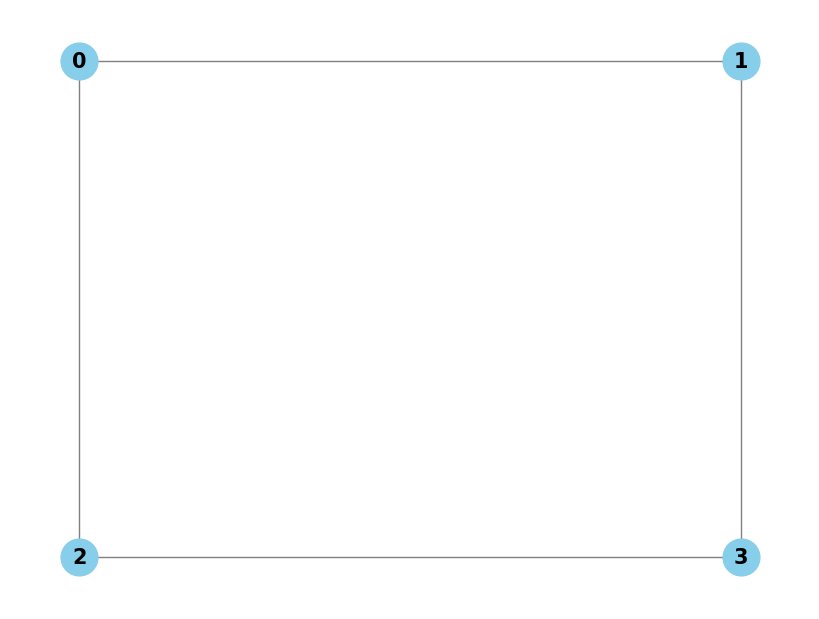

None


Matchings WITH relabeling: 2
Matchings: [{('11', '01'), ('10', '00')}, {('11', '10'), ('01', '00')}]
Relabeled edges: {('11', '01'), ('11', '10'), ('01', '00'), ('10', '00')}

Matchings WITHOUT relabeling: 2
Matchings: [{('00', '01'), ('10', '11')}, {('00', '10'), ('01', '11')}]
Number of qubits: 2

Relabeled Graph:


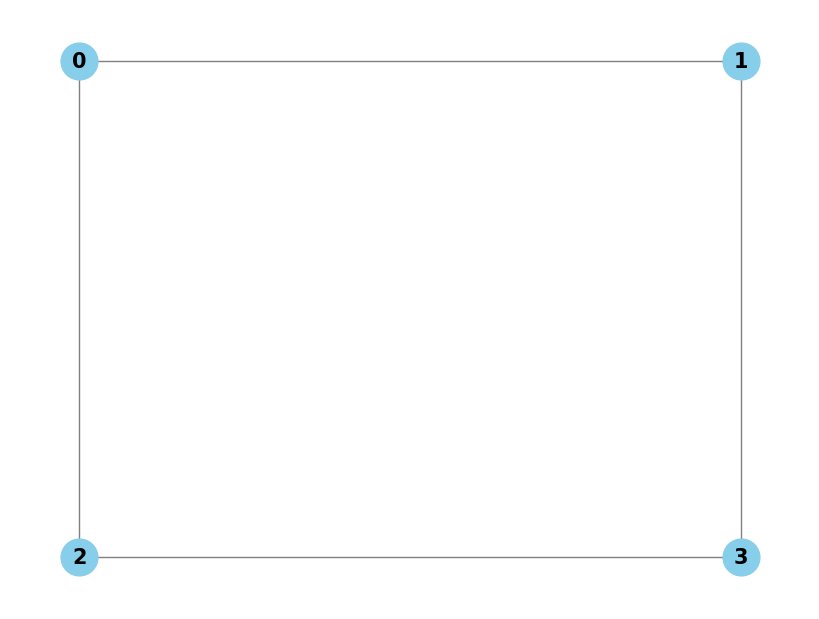

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


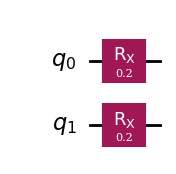


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


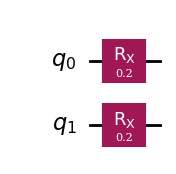


CX Gate Count Summary for Cycle Graph C4:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                             |    0/0   
2        |    0/0                                 |    0/0                             |    0/0   
5        |    0/0                                 |    0/0                             |    0/0   
10       |    0/0                                 |    0/0                             |    0/0   
20       |    0/0                                 |    0/0                             |    0/0   
50       |    0/0                                 |    0/0                             |    0/0   
100      |    0/0                                 |    0/0                             |    0/0   
Error plot saved as: trotterization_plots/cycle_graph_c4

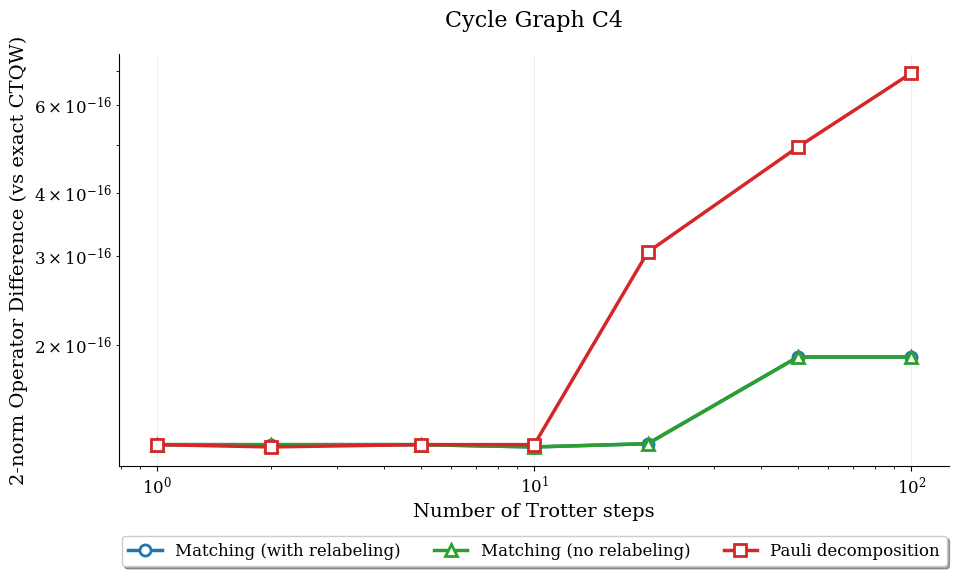

In [4]:
edges = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
analyze_and_plot(edges, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '10'), ('00', '01'), ('00', '10'), ('00', '11'), ('01', '11')}
Number of qubits: 2

Original Graph:


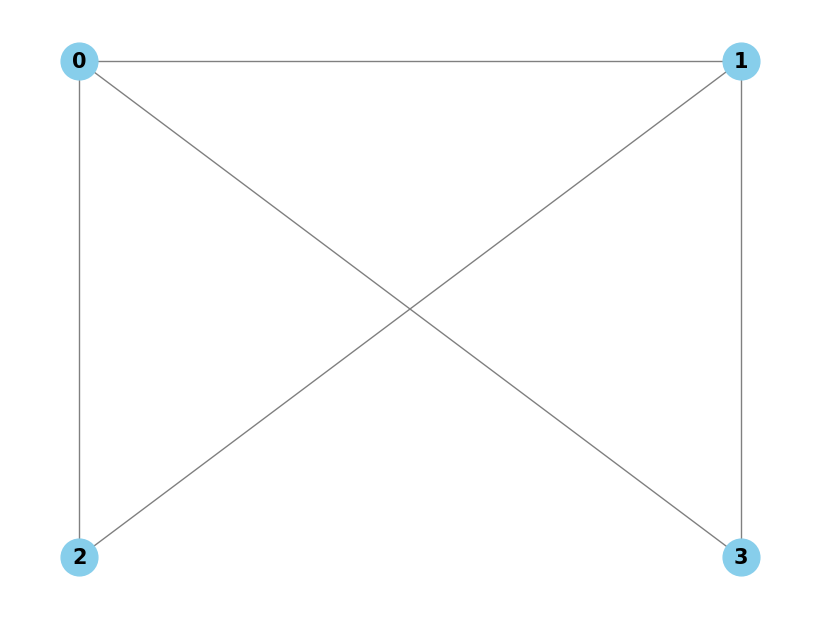

None


Matchings WITH relabeling: 3
Matchings: [{('11', '10'), ('00', '01')}, {('00', '11')}, {('11', '01'), ('00', '10')}]
Relabeled edges: {('11', '01'), ('11', '10'), ('00', '01'), ('00', '10'), ('00', '11')}

Matchings WITHOUT relabeling: 3
Matchings: [{('01', '10'), ('00', '11')}, {('00', '01')}, {('00', '10'), ('01', '11')}]
Number of qubits: 2

Relabeled Graph:


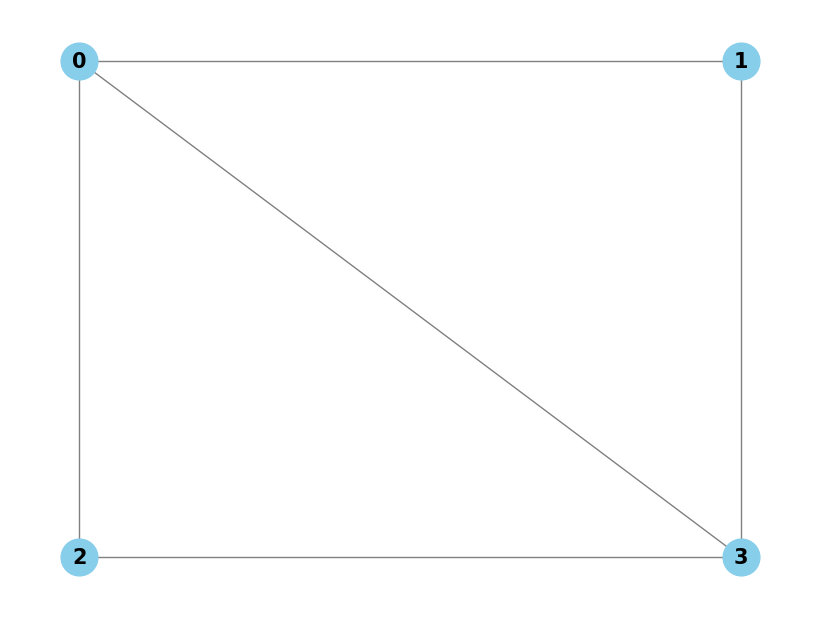

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


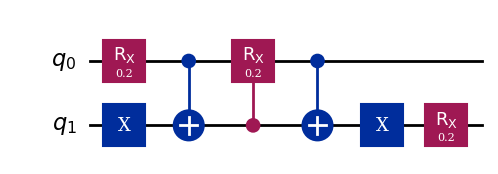


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


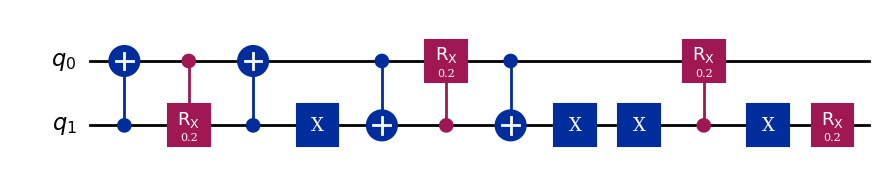


CX Gate Count Summary for Complete Graph K4 - C2:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    4/2                                 |   10/2                             |    4/2   
2        |    8/3                                 |   20/2                             |    8/2   
5        |   20/3                                 |   50/2                             |   20/2   
10       |   40/3                                 |  100/2                             |   40/2   
20       |   80/3                                 |  200/2                             |   80/2   
50       |  200/3                                 |  500/2                             |  200/2   
100      |  400/3                                 | 1000/2                             |  400/2   
Error plot saved as: trotterization_plots/comple

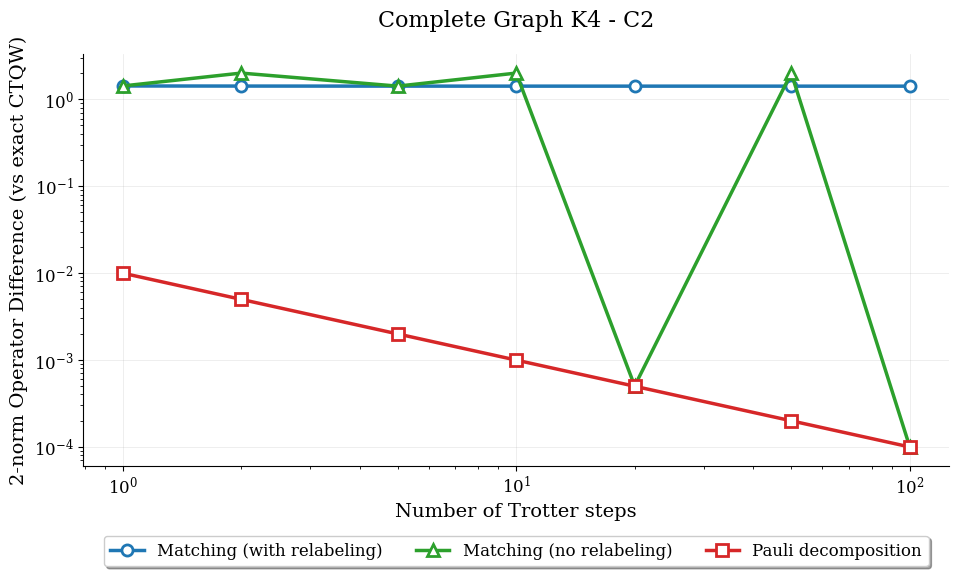

In [5]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
analyze_and_plot(edges, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('00', '01'), ('01', '10'), ('10', '11')}
Number of qubits: 2

Original Graph:


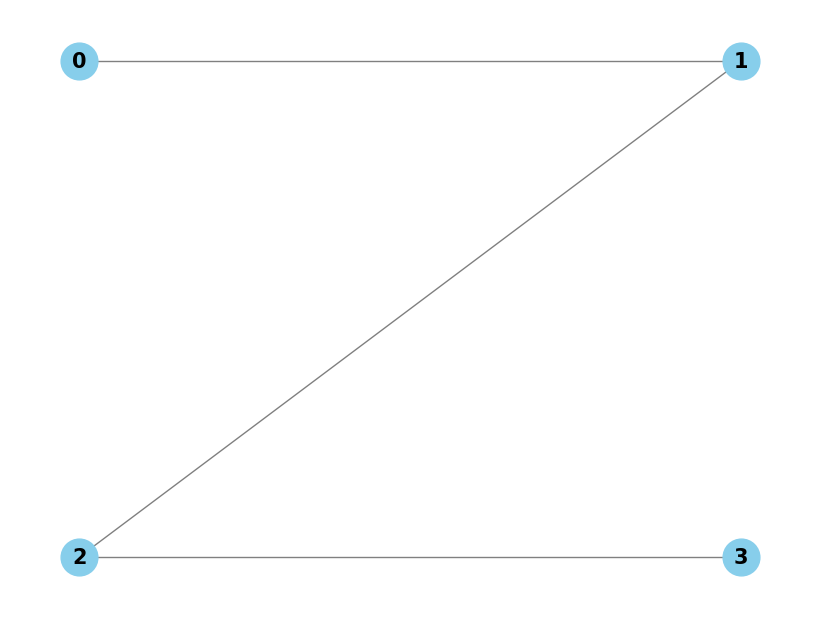

None


Matchings WITH relabeling: 2
Matchings: [{('11', '10'), ('00', '01')}, {('01', '11')}]
Relabeled edges: {('11', '10'), ('00', '01'), ('01', '11')}

Matchings WITHOUT relabeling: 2
Matchings: [{('00', '01'), ('10', '11')}, {('01', '10')}]
Number of qubits: 2

Relabeled Graph:


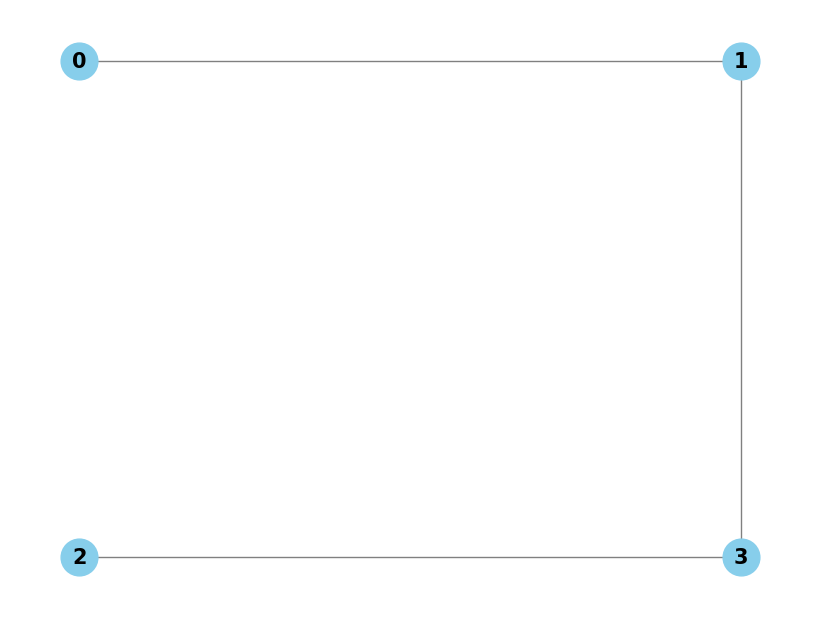

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


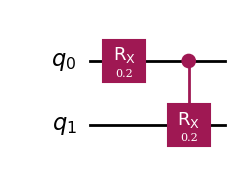


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


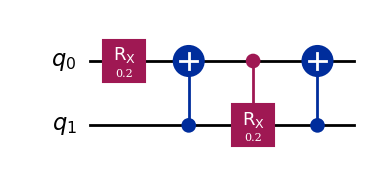


CX Gate Count Summary for Path Graph P3:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    2/2                                 |    4/2                             |    4/2   
2        |    4/2                                 |    8/2                             |    8/2   
5        |   10/2                                 |   20/2                             |   20/2   
10       |   20/2                                 |   40/2                             |   40/2   
20       |   40/2                                 |   80/2                             |   80/2   
50       |  100/2                                 |  200/2                             |  200/2   
100      |  200/2                                 |  400/2                             |  400/2   
Error plot saved as: trotterization_plots/path_graph_p3_e

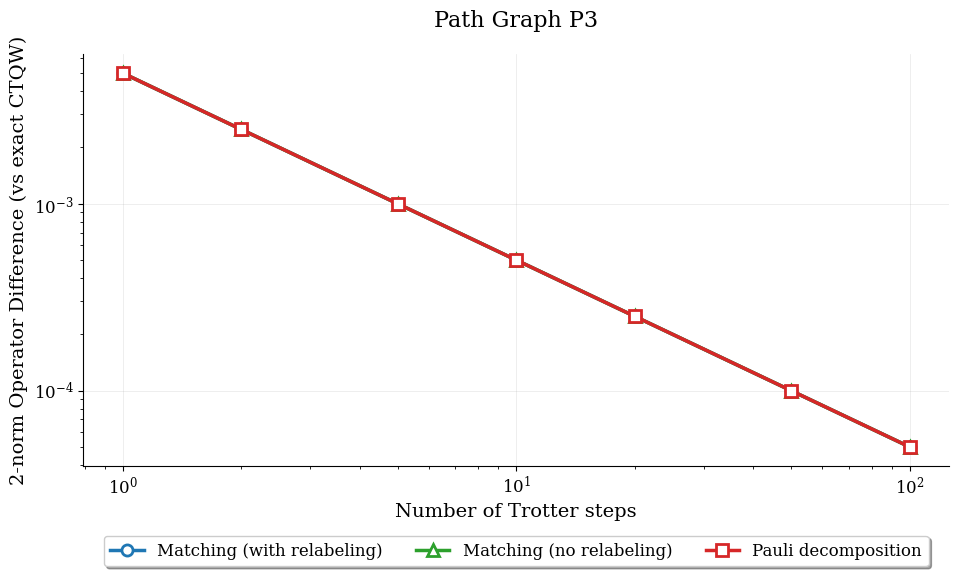

In [6]:
edges = {('00', '01'), ('01', '10'), ('10', '11')}
analyze_and_plot(edges, "Path Graph P3")


Tree Graph (2 qubits)
Original edges: {('00', '01'), ('00', '10'), ('00', '11')}
Number of qubits: 2

Original Graph:


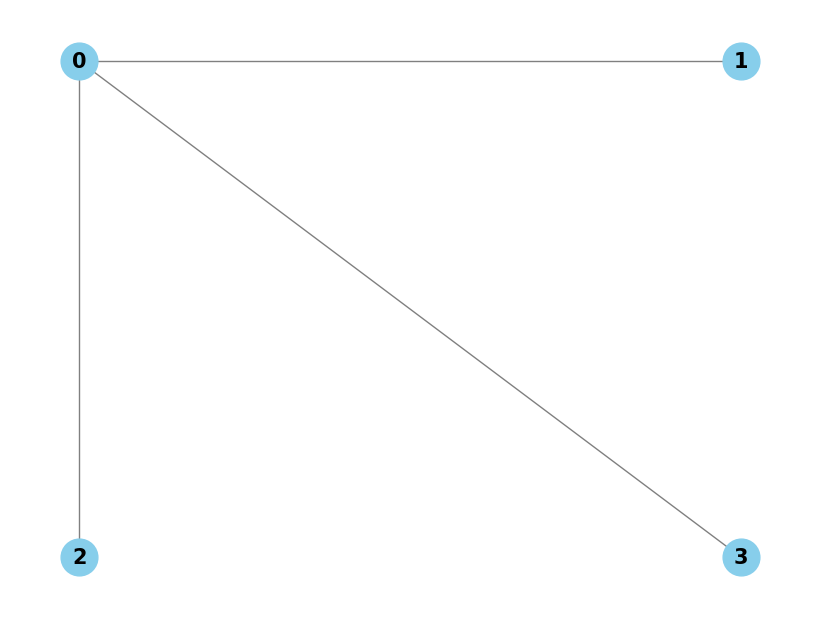

None


Matchings WITH relabeling: 3
Matchings: [{('01', '10')}, {('01', '11')}, {('01', '00')}]
Relabeled edges: {('01', '00'), ('01', '10'), ('01', '11')}

Matchings WITHOUT relabeling: 3
Matchings: [{('00', '01')}, {('00', '10')}, {('00', '11')}]
Number of qubits: 2

Relabeled Graph:


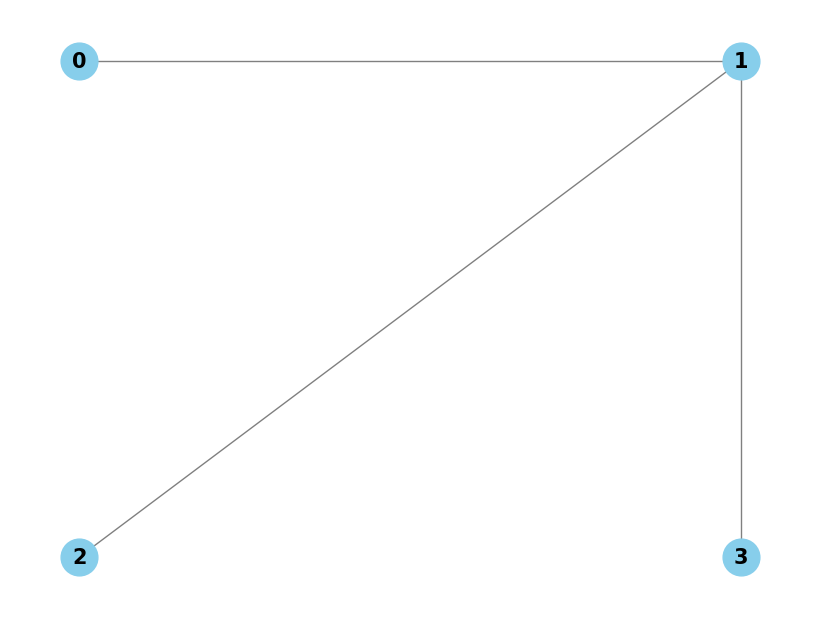

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


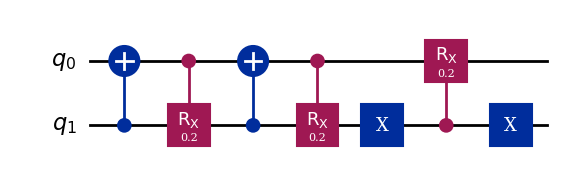


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


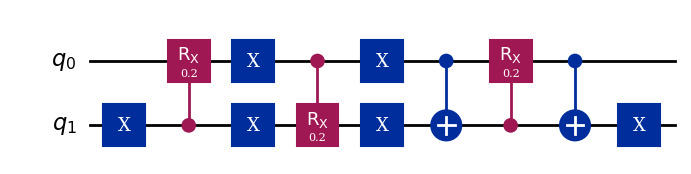


CX Gate Count Summary for Tree Graph (2 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    8/3                                 |    8/3                             |    8/3   
2        |   16/3                                 |   16/3                             |   16/3   
5        |   40/3                                 |   40/3                             |   40/3   
10       |   80/3                                 |   80/3                             |   80/3   
20       |  160/3                                 |  160/3                             |  160/3   
50       |  400/3                                 |  400/3                             |  400/3   
100      |  800/3                                 |  800/3                             |  800/3   
Error plot saved as: trotterization_plots/tree_gr

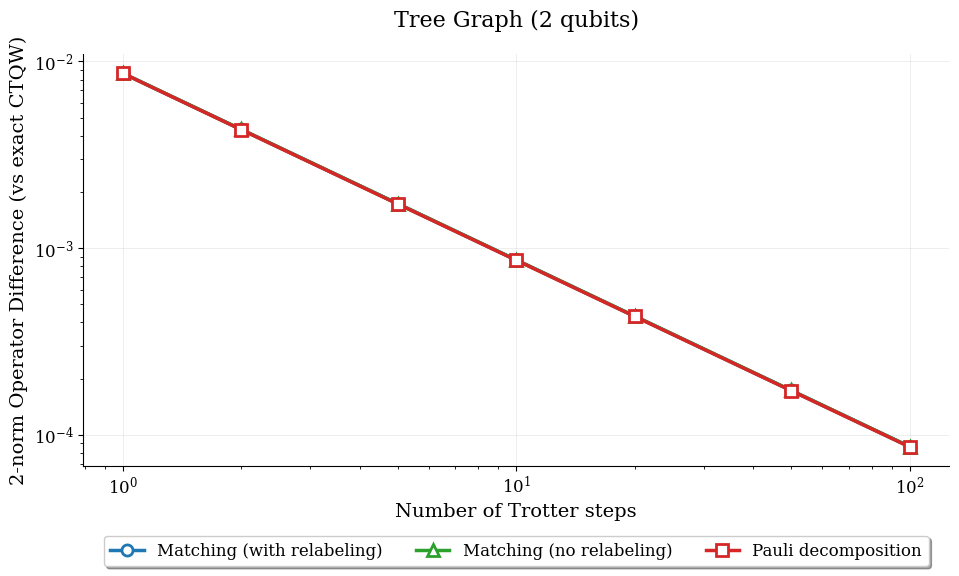

In [7]:
edges = {('00','01'), ('00','10'), ('00','11')}
analyze_and_plot(edges, "Tree Graph (2 qubits)")


Tree Graph (3 qubits)
Original edges: {('000', '100'), ('000', '001'), ('000', '011'), ('000', '111'), ('000', '101'), ('000', '110'), ('000', '010')}
Number of qubits: 3

Original Graph:


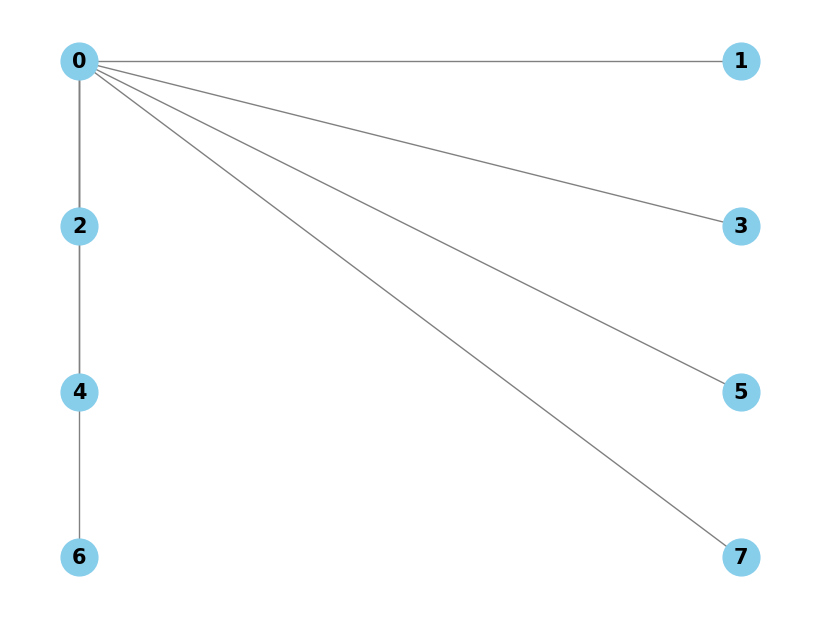

None


Matchings WITH relabeling: 7
Matchings: [{('001', '011')}, {('001', '101')}, {('001', '100')}, {('001', '111')}, {('001', '110')}, {('001', '010')}, {('001', '000')}]
Relabeled edges: {('001', '101'), ('001', '111'), ('001', '110'), ('001', '000'), ('001', '100'), ('001', '010'), ('001', '011')}

Matchings WITHOUT relabeling: 7
Matchings: [{('000', '100')}, {('000', '001')}, {('000', '011')}, {('000', '111')}, {('000', '101')}, {('000', '110')}, {('000', '010')}]
Number of qubits: 3

Relabeled Graph:


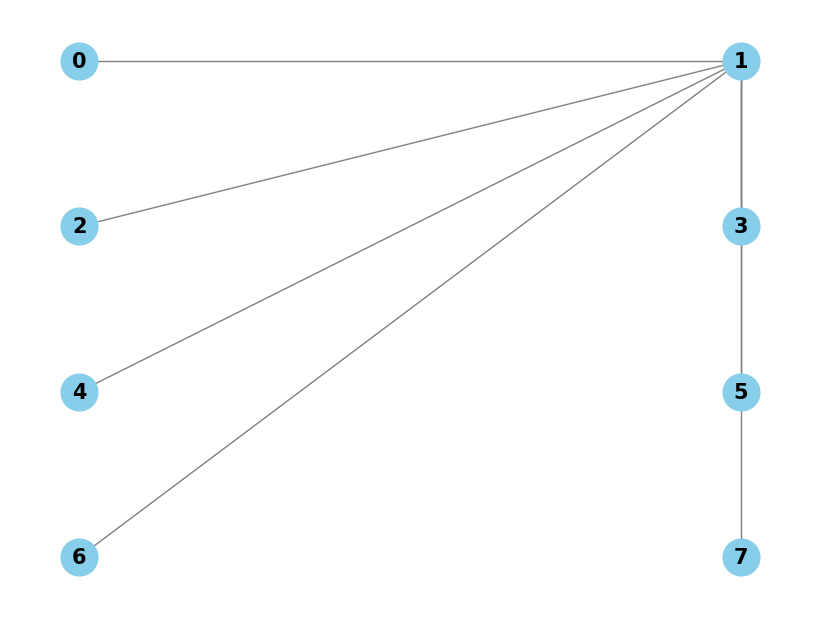

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


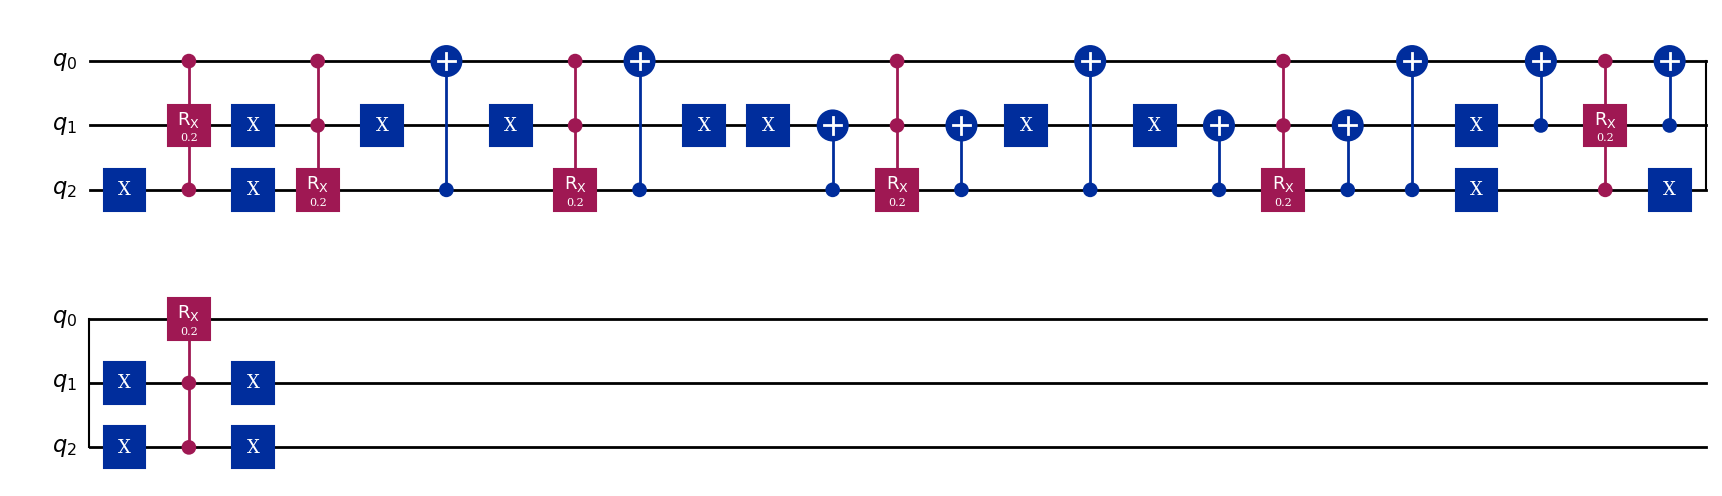


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


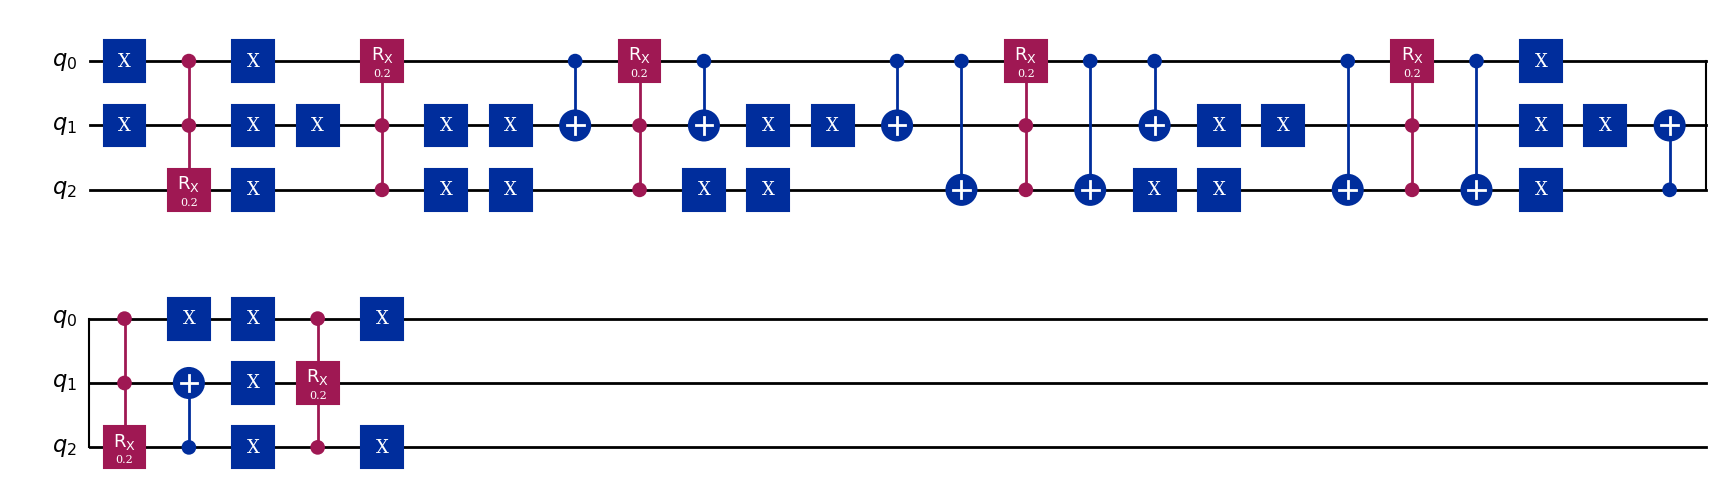


CX Gate Count Summary for Tree Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   66/59                                |   66/55                            |   76/30  
2        |  132/118                               |  132/110                           |  152/60  
5        |  330/295                               |  330/275                           |  380/150 
10       |  660/590                               |  660/550                           |  760/300 
20       | 1320/1180                              | 1320/1100                          | 1520/600 
50       | 3300/2950                              | 3300/2750                          | 3800/1500
100      | 6600/5900                              | 6600/5500                          | 7600/3000
Error plot saved as: trotterization_plots/tree_gr

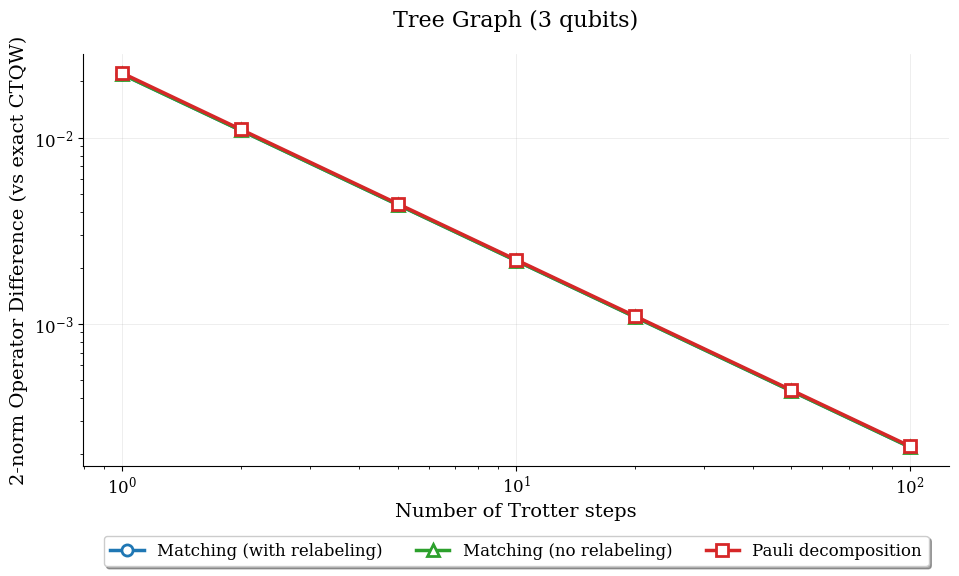

In [8]:
edges = {('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'), ('000','111')}
analyze_and_plot(edges, "Tree Graph (3 qubits)")


Dense Non-Bipartite Graph (3 qubits)
Original edges: {('000', '100'), ('001', '111'), ('100', '111'), ('010', '110'), ('000', '110'), ('001', '011'), ('110', '111'), ('101', '110'), ('011', '111'), ('010', '111'), ('101', '111'), ('100', '110'), ('001', '101'), ('100', '101'), ('010', '011'), ('000', '011'), ('001', '100'), ('001', '010'), ('000', '001'), ('011', '101'), ('011', '100'), ('000', '101'), ('000', '010'), ('010', '100')}
Number of qubits: 3

Original Graph:


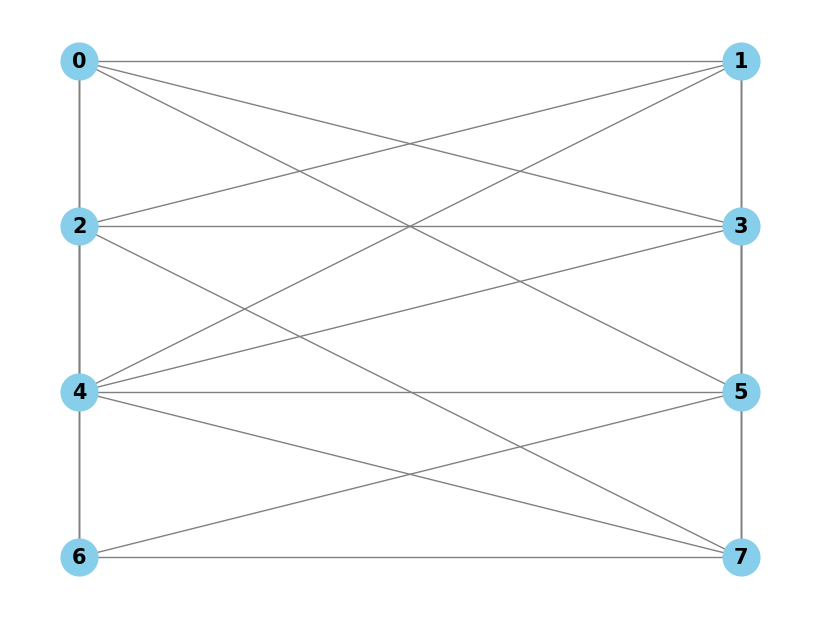

None


Matchings WITH relabeling: 7
Matchings: [{('000', '100'), ('010', '110'), ('011', '111'), ('001', '101')}, {('001', '111'), ('000', '110'), ('011', '101'), ('010', '100')}, {('000', '011'), ('101', '110'), ('100', '111'), ('001', '010')}, {('010', '111'), ('000', '101'), ('001', '100')}, {('011', '100')}, {('000', '010'), ('001', '011'), ('100', '110'), ('101', '111')}, {('010', '011'), ('110', '111'), ('000', '001'), ('100', '101')}]
Relabeled edges: {('000', '100'), ('001', '111'), ('100', '111'), ('010', '110'), ('000', '110'), ('001', '011'), ('110', '111'), ('101', '110'), ('011', '111'), ('010', '111'), ('101', '111'), ('100', '110'), ('001', '101'), ('010', '011'), ('000', '011'), ('001', '100'), ('100', '101'), ('001', '010'), ('000', '001'), ('011', '101'), ('011', '100'), ('000', '101'), ('000', '010'), ('010', '100')}

Matchings WITHOUT relabeling: 7
Matchings: [{('000', '100'), ('010', '110'), ('011', '111'), ('001', '101')}, {('001', '111'), ('000', '110'), ('011', '101')

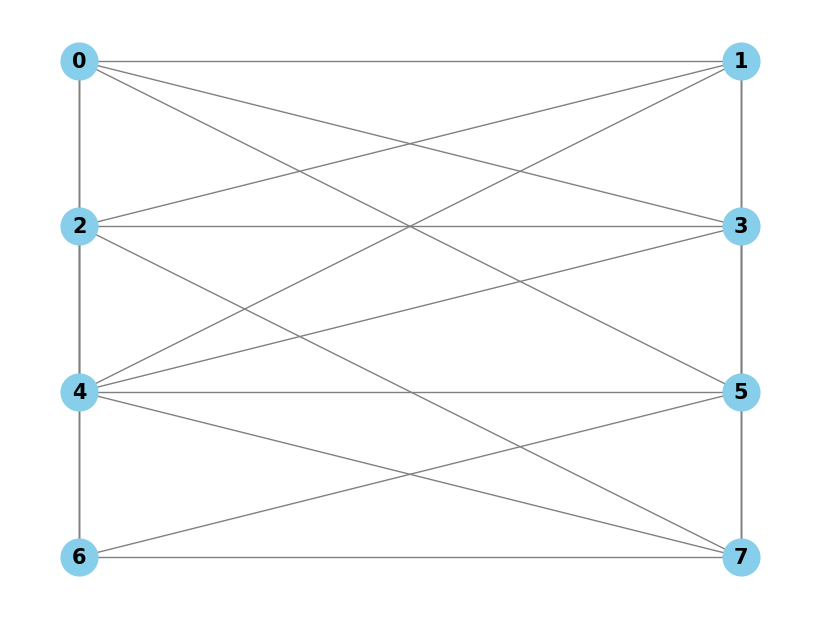

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


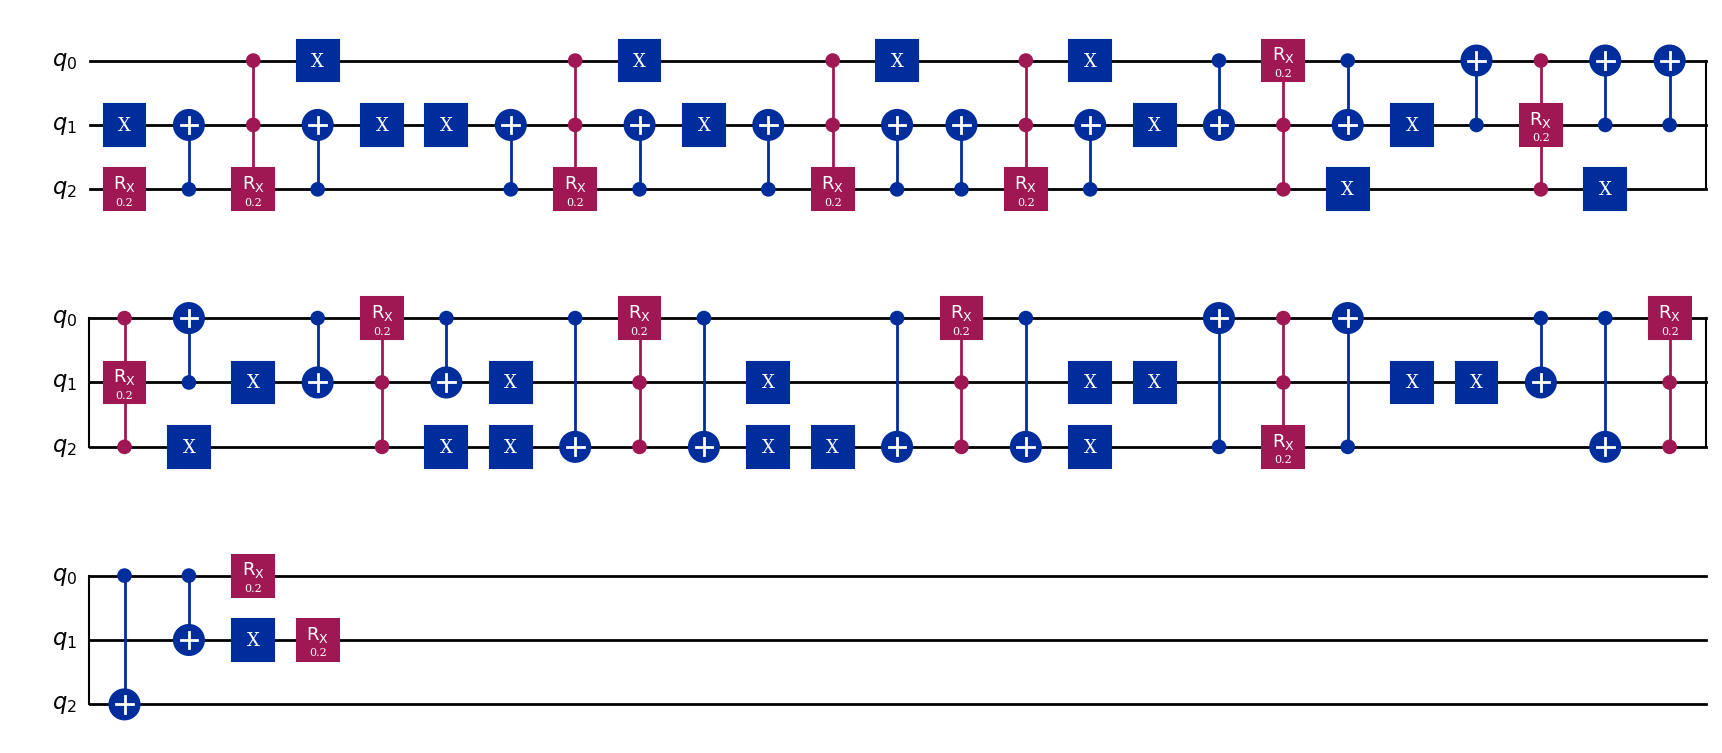


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


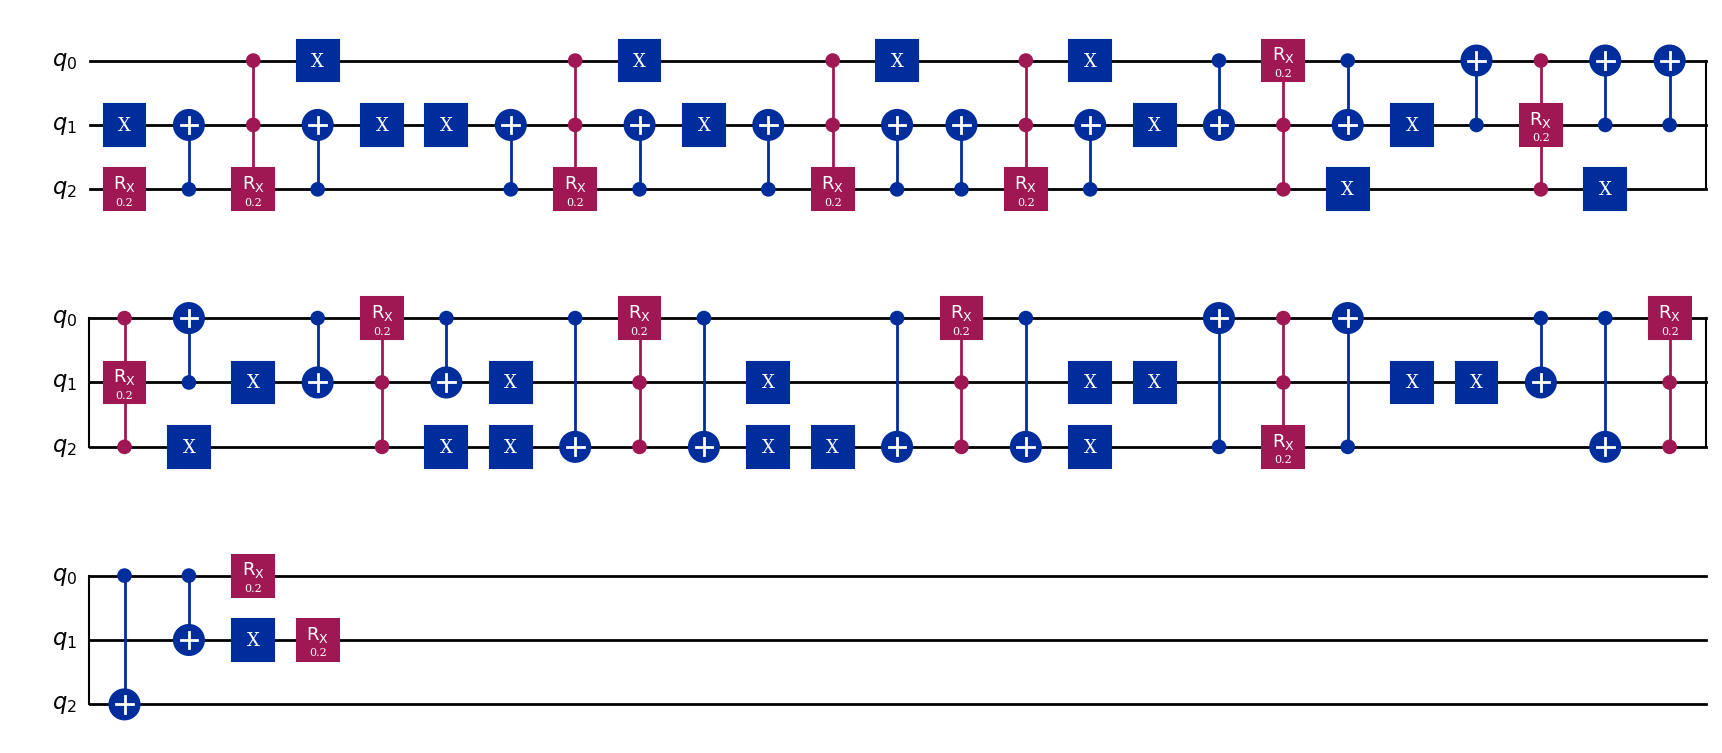


CX Gate Count Summary for Dense Non-Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  122/105                               |  122/105                           |   32/20  
2        |  244/210                               |  244/210                           |   64/40  
5        |  610/525                               |  610/525                           |  160/100 
10       | 1220/1050                              | 1220/1050                          |  320/200 
20       | 2440/2100                              | 2440/2100                          |  640/400 
50       | 6100/5250                              | 6100/5250                          | 1600/1000
100      | 12200/10500                              | 12200/10500                          | 3200/2000
Error plot saved as: trotteriz

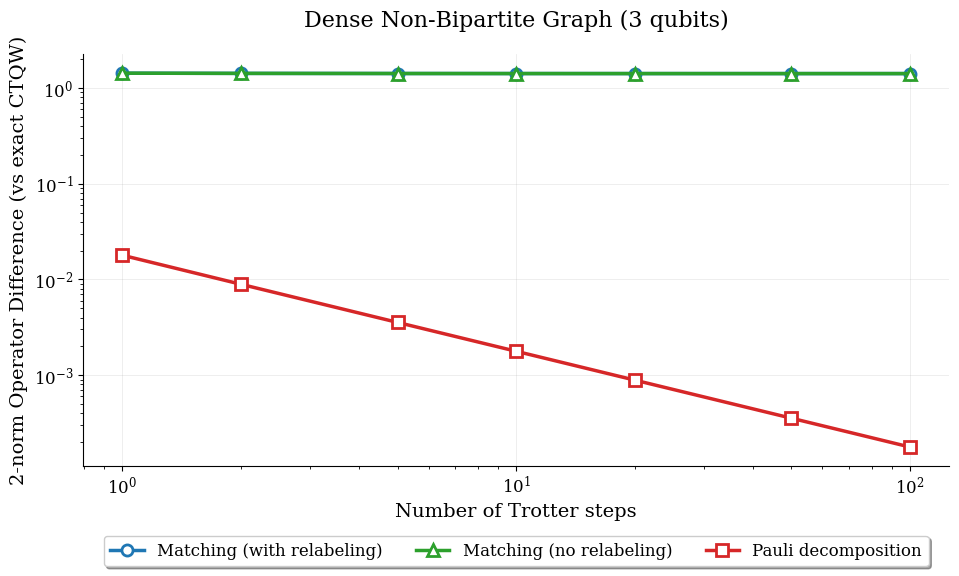

In [9]:
dense_nonbipartite_8 = {
    ('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'),
    ('001','010'), ('001','011'), ('001','100'), ('001','101'), ('001','111'),
    ('010','011'), ('010','100'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','111'),
    ('100','101'), ('100','110'), ('100','111'),
    ('101','110'), ('101','111'),
    ('110','111')
}

analyze_and_plot(dense_nonbipartite_8, "Dense Non-Bipartite Graph (3 qubits)")


Dense Bipartite Graph (3 qubits)
Original edges: {('000', '100'), ('001', '111'), ('010', '110'), ('000', '110'), ('011', '110'), ('011', '111'), ('010', '111'), ('000', '111'), ('001', '101'), ('001', '100'), ('011', '100'), ('001', '110'), ('011', '101'), ('010', '101'), ('000', '101'), ('010', '100')}
Number of qubits: 3

Original Graph:


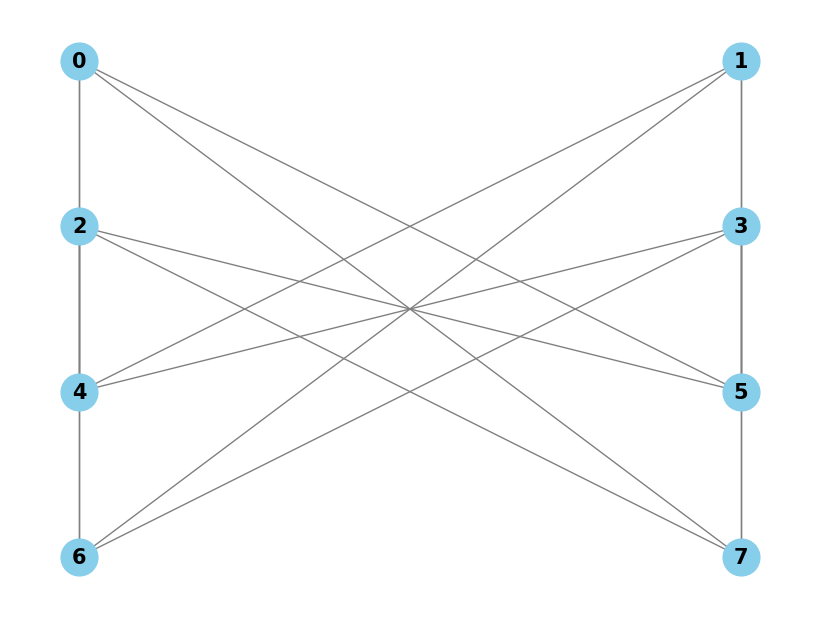

None


Matchings WITH relabeling: 4
Matchings: [{('101', '100'), ('110', '111'), ('010', '011'), ('001', '000')}, {('001', '111'), ('101', '000'), ('110', '011'), ('010', '100')}, {('110', '000'), ('010', '111'), ('001', '100'), ('101', '011')}, {('001', '011'), ('010', '000'), ('101', '111'), ('110', '100')}]
Relabeled edges: {('101', '100'), ('001', '111'), ('110', '000'), ('010', '000'), ('010', '011'), ('001', '100'), ('101', '011'), ('101', '000'), ('001', '011'), ('001', '000'), ('110', '111'), ('110', '100'), ('010', '111'), ('101', '111'), ('110', '011'), ('010', '100')}

Matchings WITHOUT relabeling: 4
Matchings: [{('000', '100'), ('010', '110'), ('011', '111'), ('001', '101')}, {('001', '111'), ('000', '110'), ('010', '101'), ('011', '100')}, {('000', '101'), ('010', '111'), ('011', '110'), ('001', '100')}, {('001', '110'), ('000', '111'), ('011', '101'), ('010', '100')}]
Number of qubits: 3

Relabeled Graph:


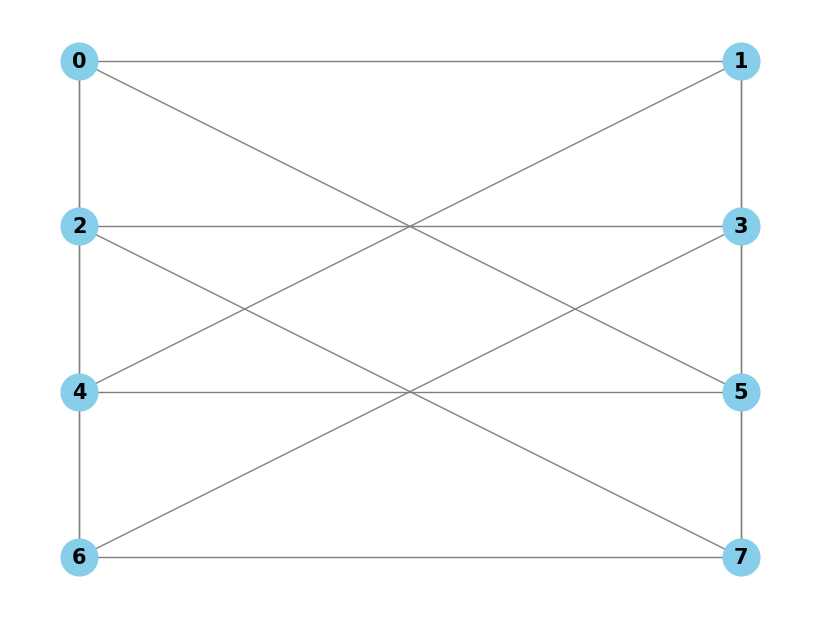

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


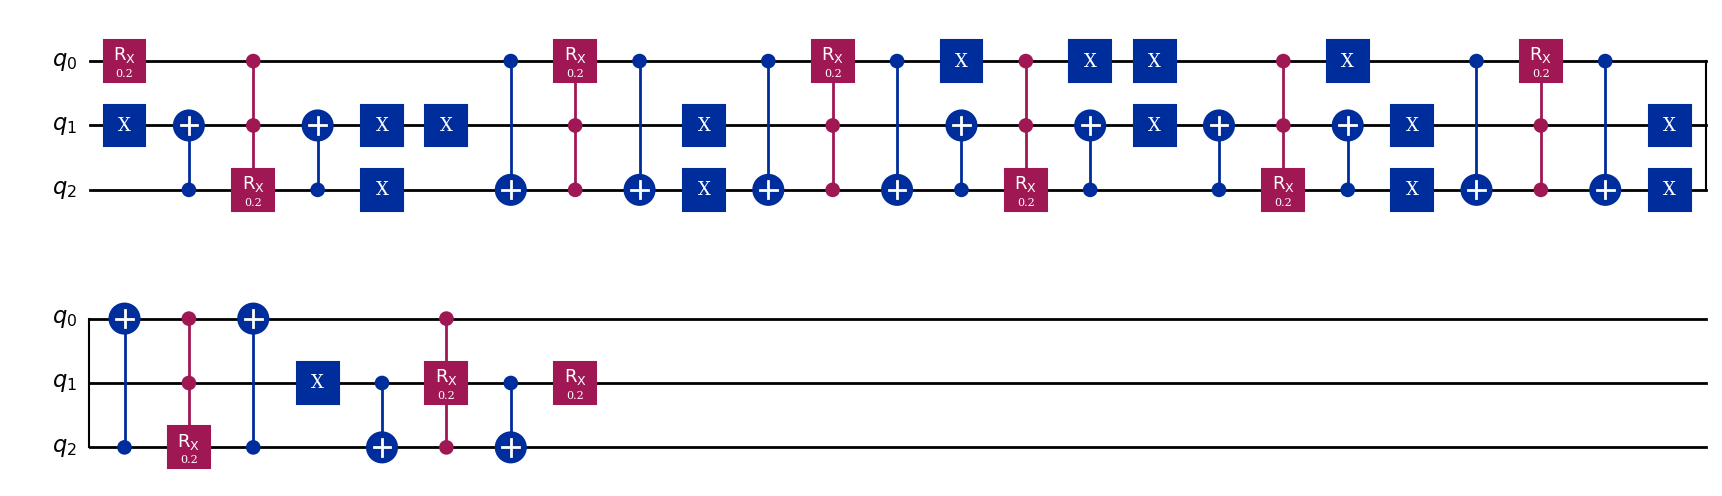


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


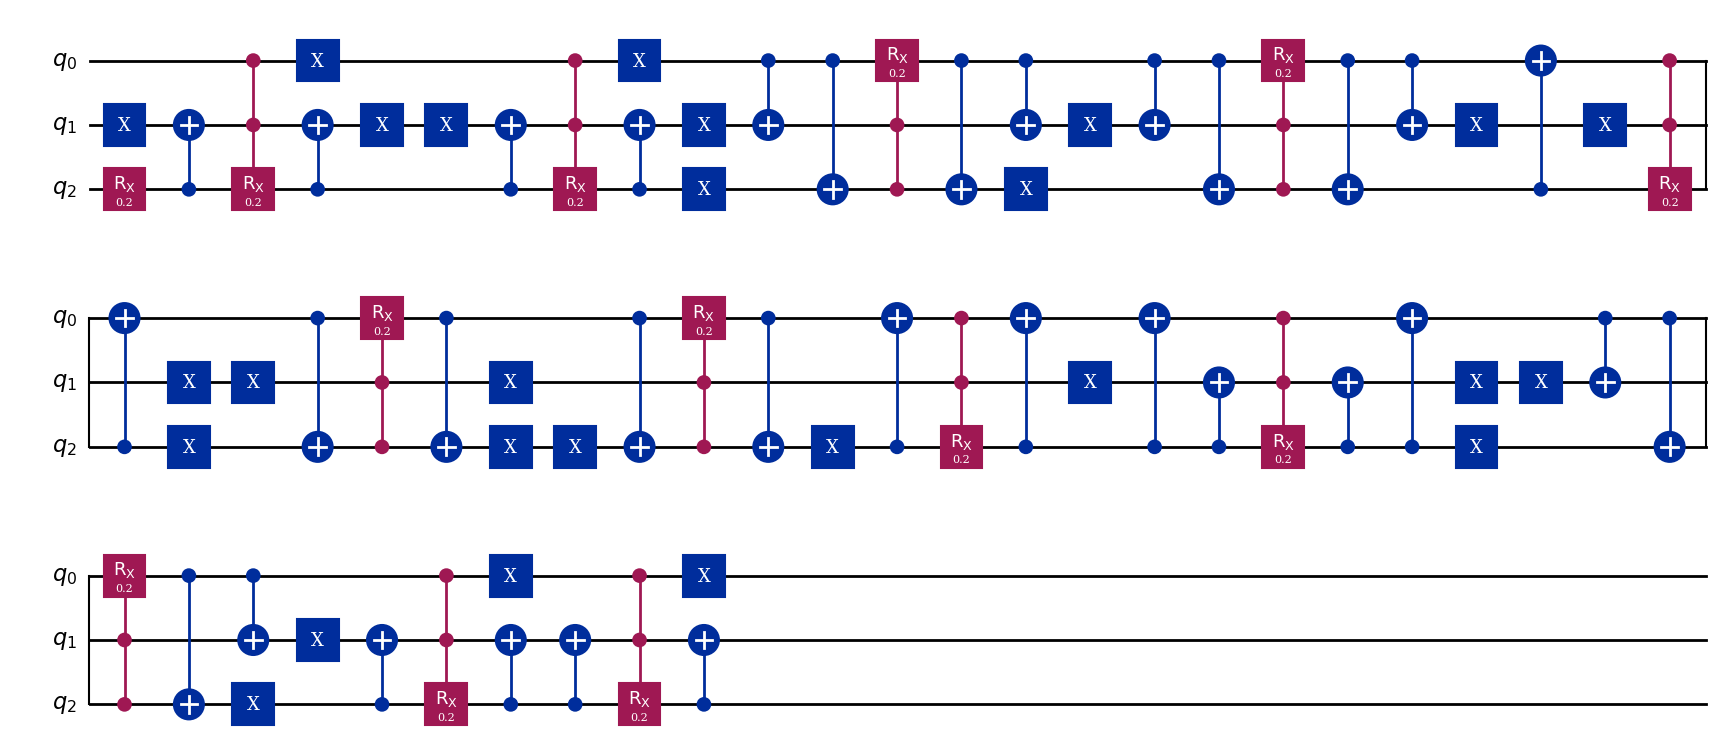


CX Gate Count Summary for Dense Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   80/70                                |  128/107                           |    8/6   
2        |  160/140                               |  256/213                           |   16/12  
5        |  400/350                               |  640/531                           |   40/30  
10       |  800/700                               | 1280/1061                          |   80/60  
20       | 1600/1400                              | 2560/2121                          |  160/120 
50       | 4000/3500                              | 6400/5301                          |  400/300 
100      | 8000/7000                              | 12800/10601                          |  800/600 
Error plot saved as: trotterization_

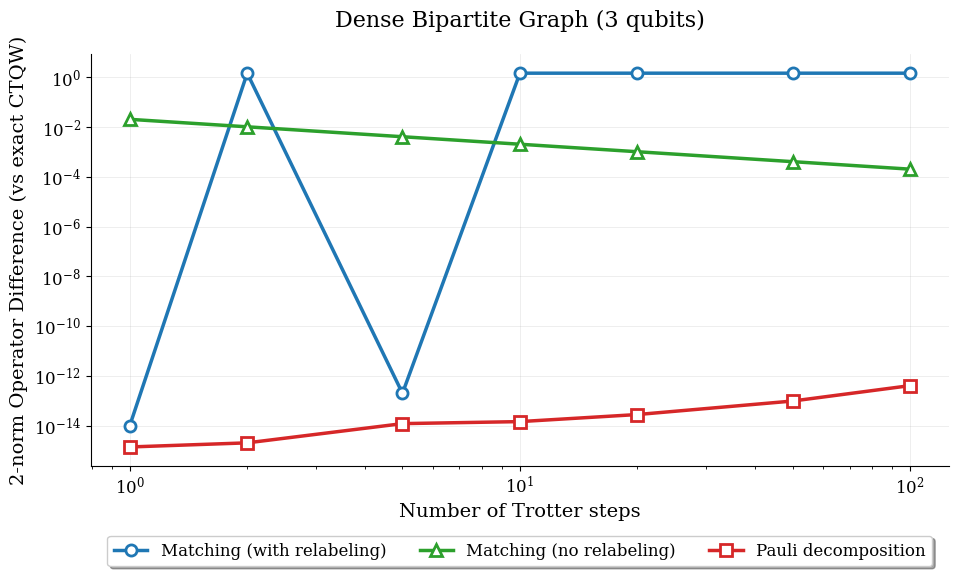

In [10]:
dense_bipartite_8 = {
    ('000','100'), ('000','101'), ('000','110'), ('000','111'),
    ('001','100'), ('001','101'), ('001','110'), ('001','111'),
    ('010','100'), ('010','101'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','110'), ('011','111')  
}
analyze_and_plot(dense_bipartite_8, "Dense Bipartite Graph (3 qubits)")


Sparse Non-Bipartite Graph (3 qubits)
Original edges: {('000', '001'), ('010', '000'), ('110', '111'), ('100', '101'), ('101', '011'), ('011', '100'), ('001', '010')}
Number of qubits: 3

Original Graph:


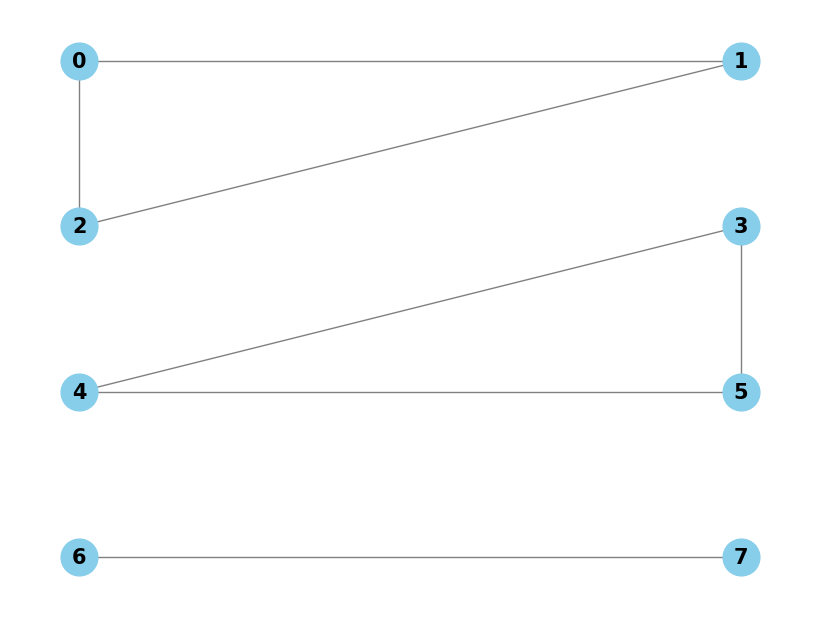

None


Matchings WITH relabeling: 4
Matchings: [{('101', '111')}, {('001', '000'), ('011', '010'), ('100', '101')}, {('111', '100'), ('110', '011')}, {('010', '110')}]
Relabeled edges: {('001', '000'), ('010', '110'), ('100', '101'), ('111', '100'), ('110', '011'), ('101', '111'), ('011', '010')}

Matchings WITHOUT relabeling: 3
Matchings: [{('000', '001'), ('100', '101'), ('110', '111')}, {('010', '000'), ('101', '011')}, {('011', '100'), ('001', '010')}]
Number of qubits: 3

Relabeled Graph:


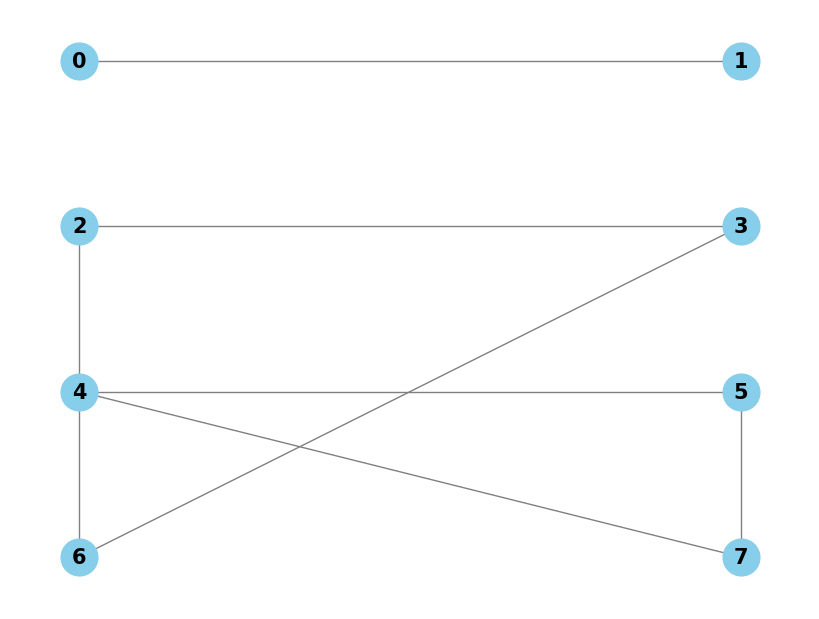

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


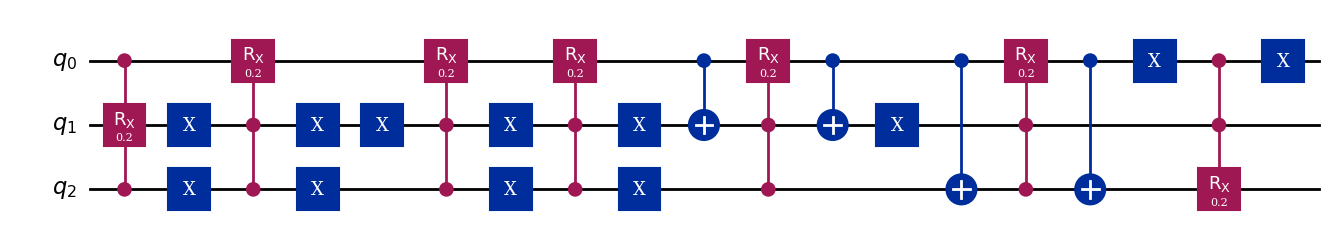


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


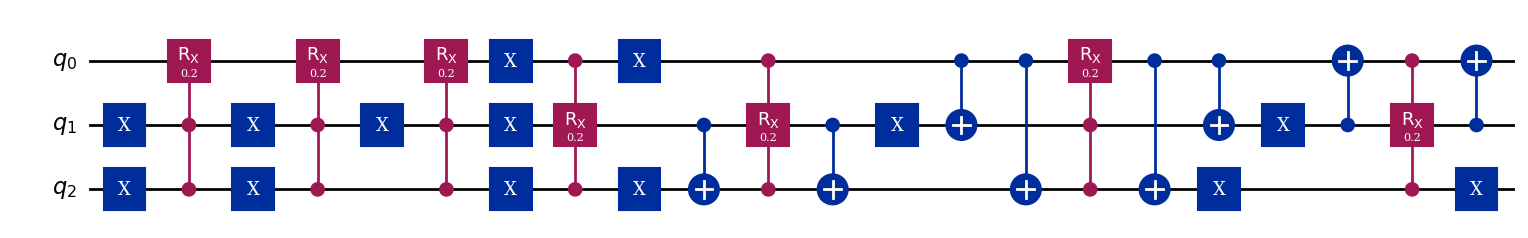


CX Gate Count Summary for Sparse Non-Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   60/57                                |   64/61                            |   56/26  
2        |  120/114                               |  128/122                           |  112/52  
5        |  300/285                               |  320/305                           |  280/130 
10       |  600/570                               |  640/610                           |  560/260 
20       | 1200/1140                              | 1280/1220                          | 1120/520 
50       | 3000/2850                              | 3200/3050                          | 2800/1300
100      | 6000/5700                              | 6400/6100                          | 5600/2600
Error plot saved as: trotterizati

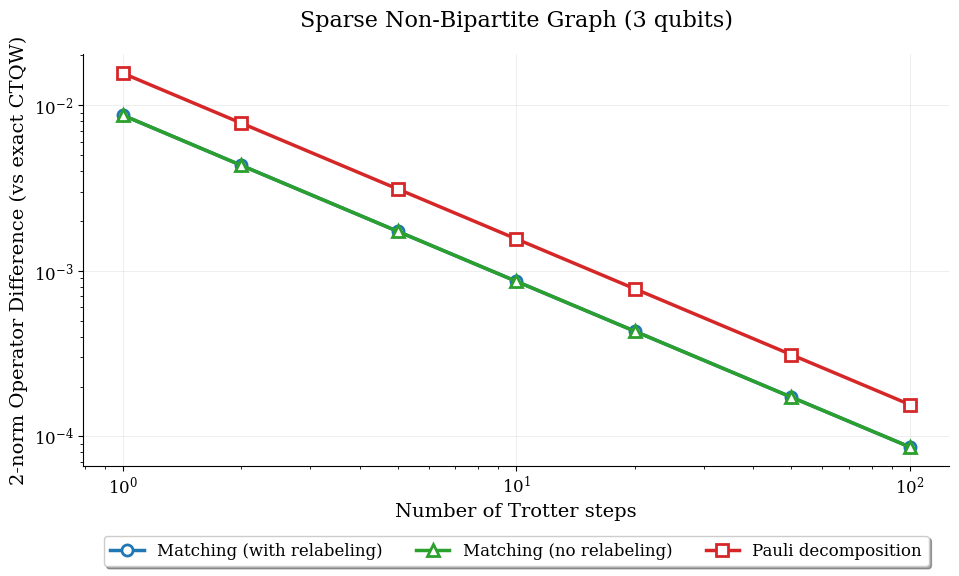

In [11]:
sparse_nonbipartite_8 = {
    ('000','001'), ('001','010'), ('010','000'),  # Triangle (odd cycle)
    ('011','100'), ('100','101'), ('101','011'),  # Another triangle
    ('110','111')
}
analyze_and_plot(sparse_nonbipartite_8, "Sparse Non-Bipartite Graph (3 qubits)")


Sparse Bipartite Graph (3 qubits)
Original edges: {('100', '011'), ('000', '001'), ('010', '001'), ('110', '101'), ('010', '011'), ('100', '101'), ('110', '111')}
Number of qubits: 3

Original Graph:


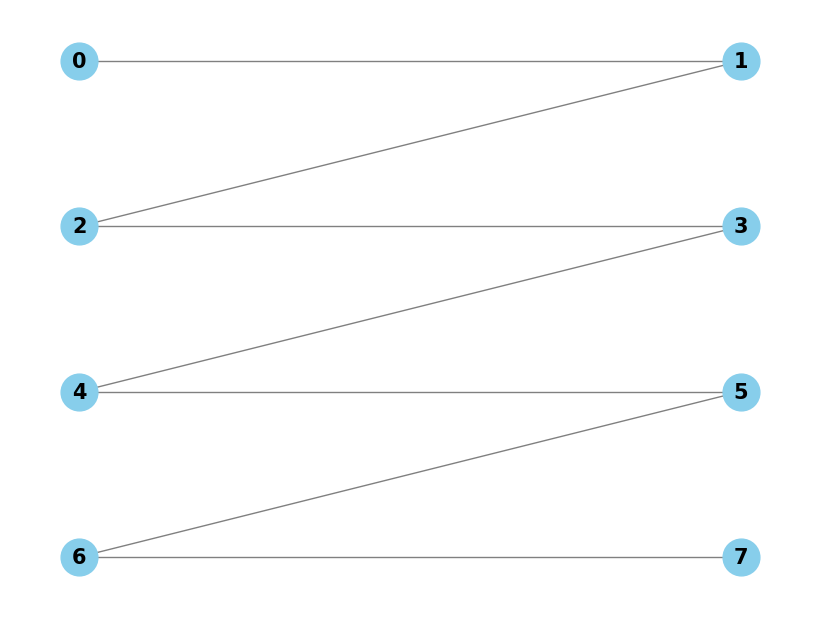

None


Matchings WITH relabeling: 4
Matchings: [{('001', '101')}, {('001', '000'), ('111', '110'), ('100', '101'), ('011', '010')}, {('100', '110')}, {('011', '000')}]
Relabeled edges: {('001', '101'), ('001', '000'), ('011', '000'), ('100', '101'), ('111', '110'), ('011', '010'), ('100', '110')}

Matchings WITHOUT relabeling: 2
Matchings: [{('110', '101'), ('100', '011'), ('010', '001')}, {('110', '111'), ('000', '001'), ('100', '101'), ('010', '011')}]
Number of qubits: 3

Relabeled Graph:


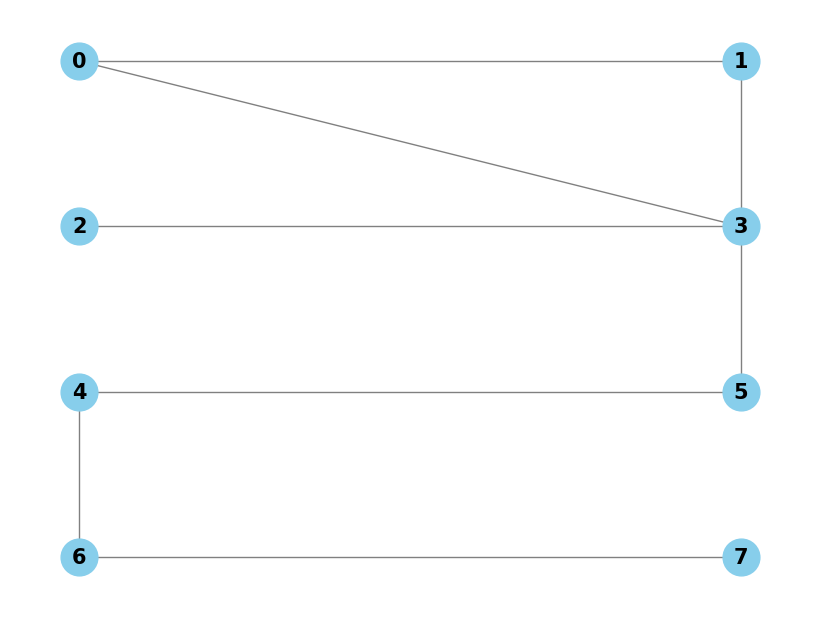

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


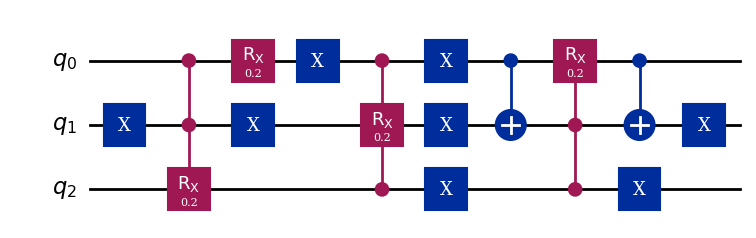


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


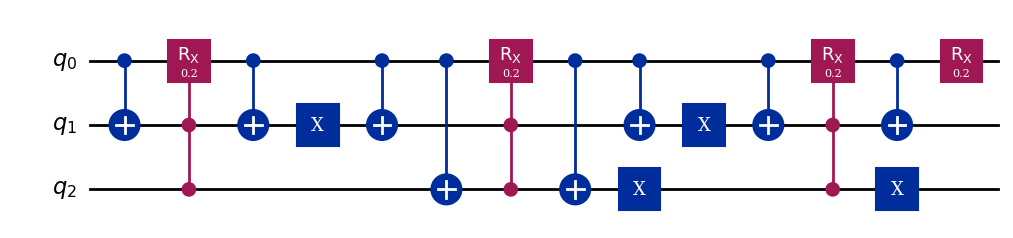


CX Gate Count Summary for Sparse Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   26/24                                |   32/25                            |   20/16  
2        |   52/48                                |   64/49                            |   40/32  
5        |  130/120                               |  160/121                           |  100/80  
10       |  260/240                               |  320/241                           |  200/160 
20       |  520/480                               |  640/481                           |  400/320 
50       | 1300/1200                              | 1600/1201                          | 1000/800 
100      | 2600/2400                              | 3200/2401                          | 2000/1600
Error plot saved as: trotterization_p

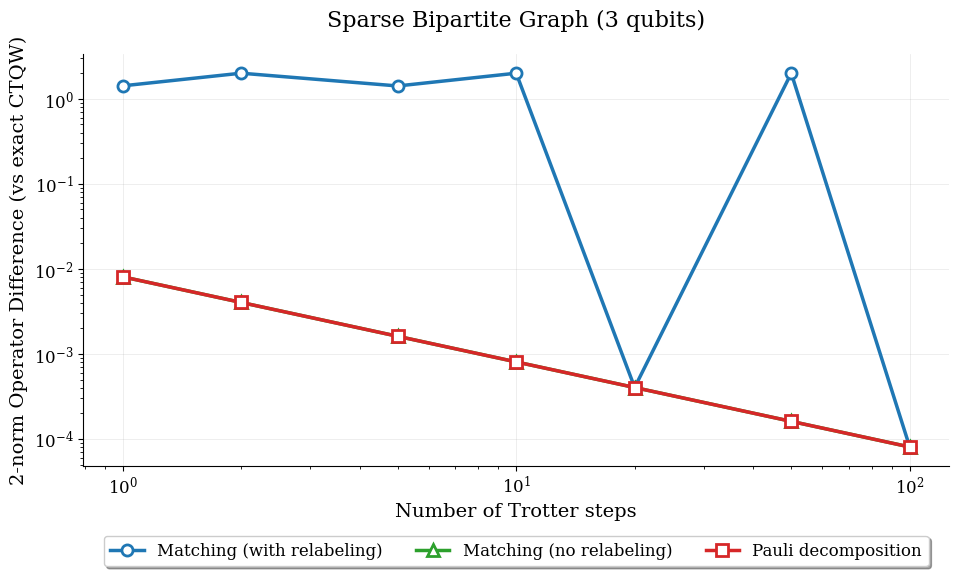

In [12]:
sparse_bipartite_8 = {
    ('000','001'), ('010','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}
analyze_and_plot(sparse_bipartite_8, "Sparse Bipartite Graph (3 qubits)")


Dense Non-Bipartite Graph (4 qubits)
Original edges: {('1010', '1111'), ('1010', '1110'), ('0110', '1010'), ('0010', '1010'), ('0101', '0111'), ('0011', '1011'), ('1010', '1011'), ('0011', '0100'), ('0110', '1110'), ('0010', '0100'), ('1010', '1100'), ('1100', '1110'), ('0001', '0100'), ('1100', '1111'), ('0011', '1001'), ('0110', '1100'), ('1000', '1010'), ('0000', '0011'), ('0000', '0110'), ('0000', '0101'), ('1001', '1010'), ('0100', '1010'), ('1100', '1101'), ('1001', '1110'), ('1000', '1011'), ('0001', '1001'), ('0101', '1011'), ('1001', '1011'), ('0010', '1000'), ('0000', '0111'), ('0111', '1011'), ('0111', '1111'), ('0000', '0010'), ('1000', '1100'), ('1001', '1101'), ('0001', '1000'), ('0101', '1101'), ('1000', '1001'), ('1110', '1111'), ('0111', '1101'), ('1011', '1111'), ('0100', '1100'), ('0010', '0011'), ('0010', '0110'), ('0011', '0101'), ('0101', '1001'), ('1011', '1101'), ('1011', '1100'), ('0001', '0011'), ('0011', '0111'), ('0001', '0101'), ('0100', '1000'), ('0110', 

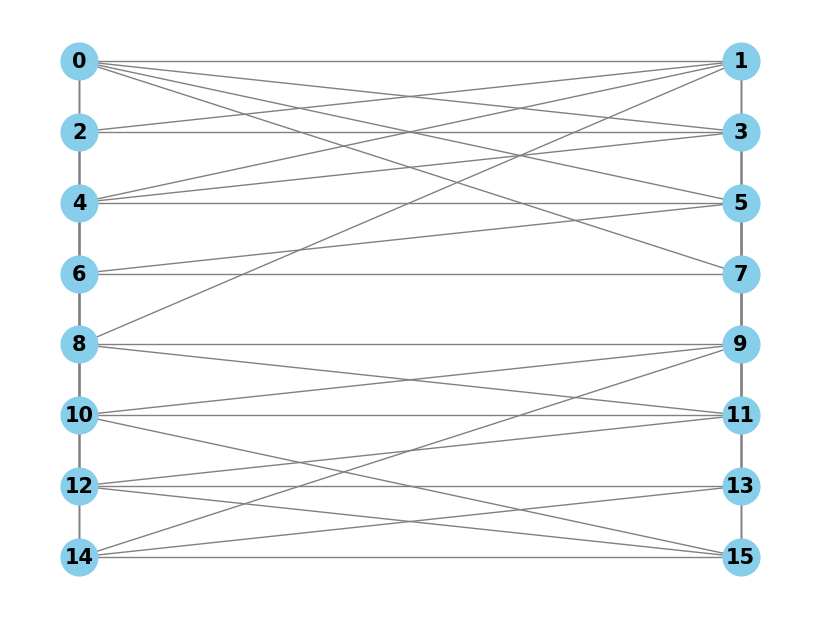

None


Matchings WITH relabeling: 10
Matchings: [{('0110', '1100'), ('1010', '1111'), ('0100', '0111'), ('0011', '0000'), ('1001', '1110'), ('1000', '1011'), ('0001', '0010')}, {('0011', '1001'), ('1100', '1111'), ('0110', '1010'), ('0111', '1101'), ('0100', '0001'), ('0101', '1011'), ('0010', '1000')}, {('0001', '1000'), ('0000', '0110'), ('1101', '1110'), ('0101', '1001'), ('0100', '0011'), ('1010', '1100'), ('0111', '1011')}, {('1001', '1010'), ('0100', '0010'), ('0011', '0101'), ('1011', '1101'), ('0000', '1100')}, {('0101', '0110'), ('1011', '1100'), ('0000', '1010')}, {('0000', '0101')}, {('1010', '1110'), ('0001', '0101'), ('1011', '1111'), ('0010', '0110'), ('0100', '0000'), ('1001', '1101'), ('0011', '0111'), ('1000', '1100')}, {('0101', '1101'), ('0010', '1010'), ('0011', '1011'), ('0110', '1110'), ('0000', '1000'), ('0001', '1001'), ('0111', '1111')}, {('1000', '1010'), ('0101', '0111'), ('1101', '1111'), ('0010', '0000'), ('0100', '0110'), ('1001', '1011'), ('0001', '0011'), ('11

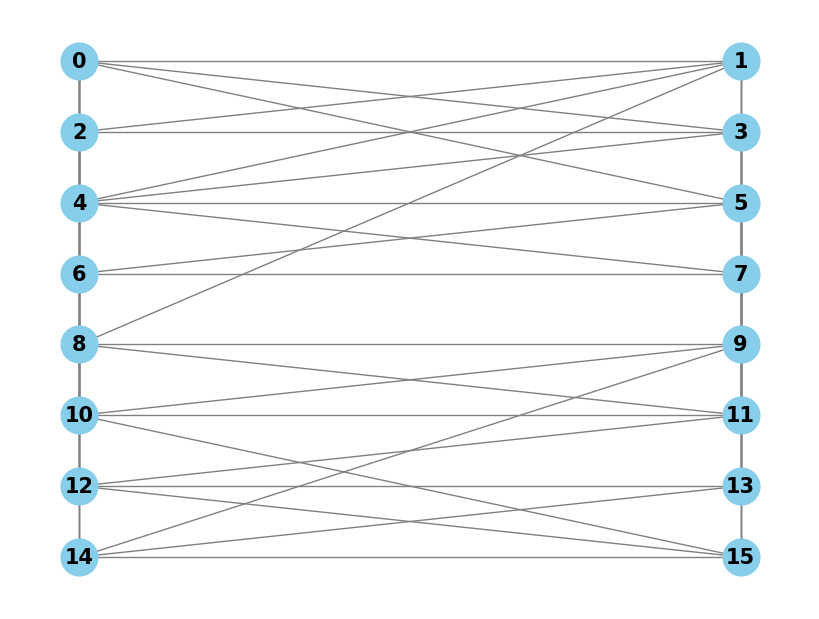

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


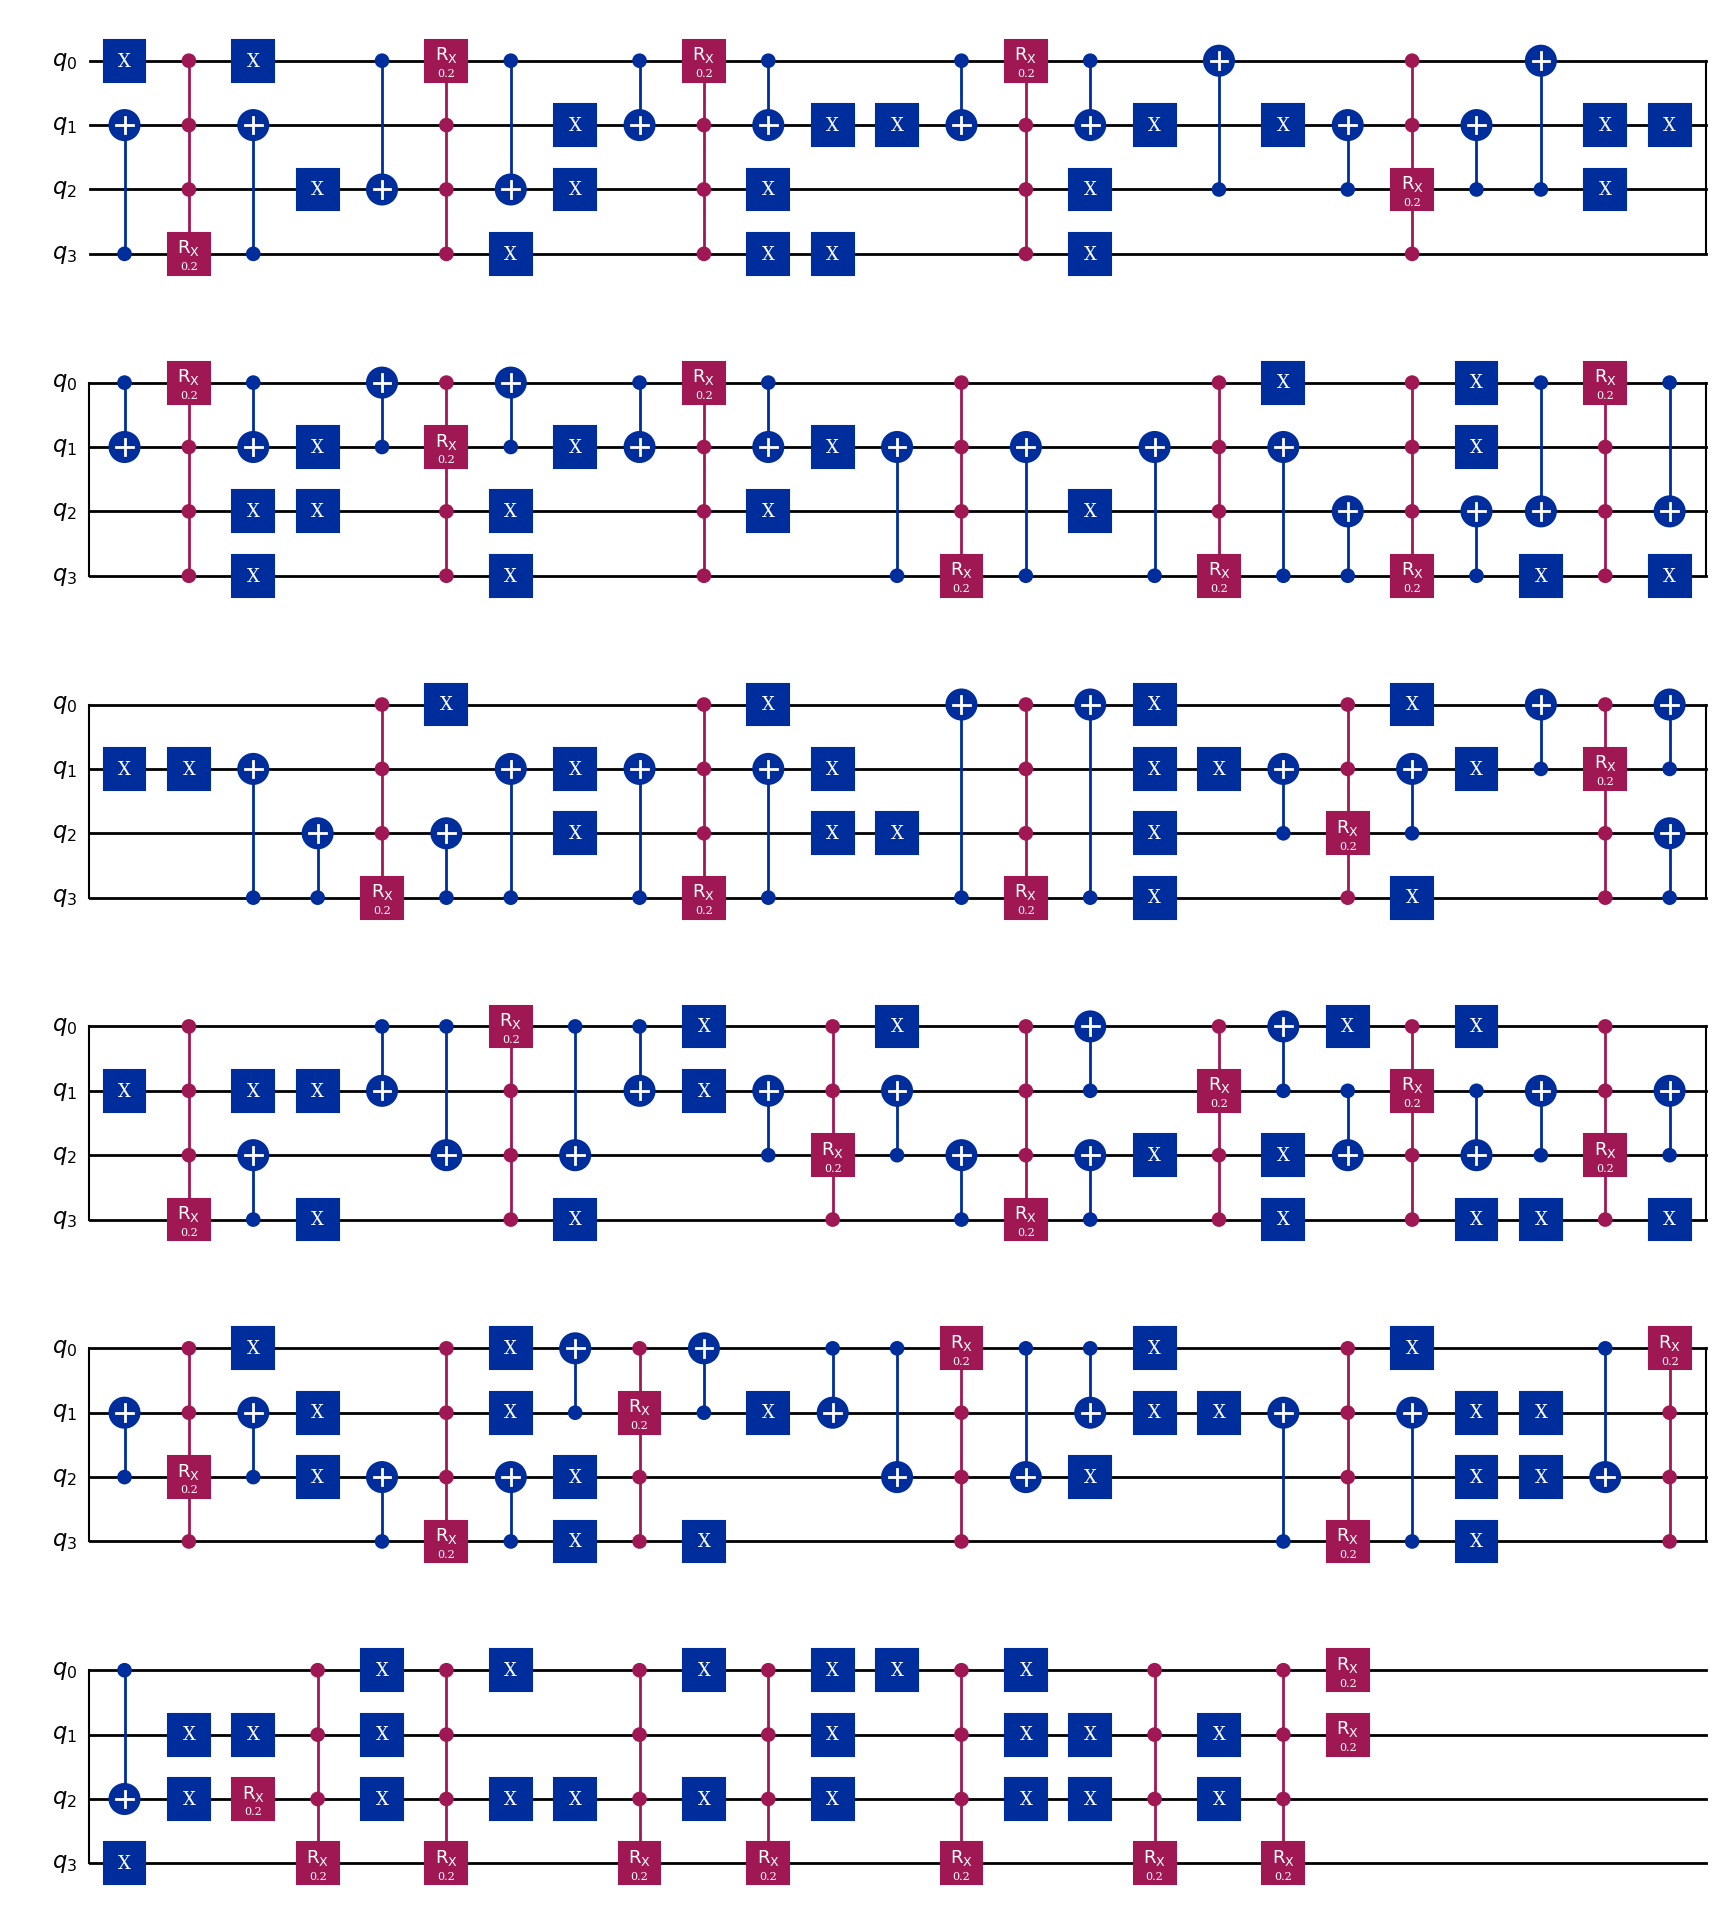


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


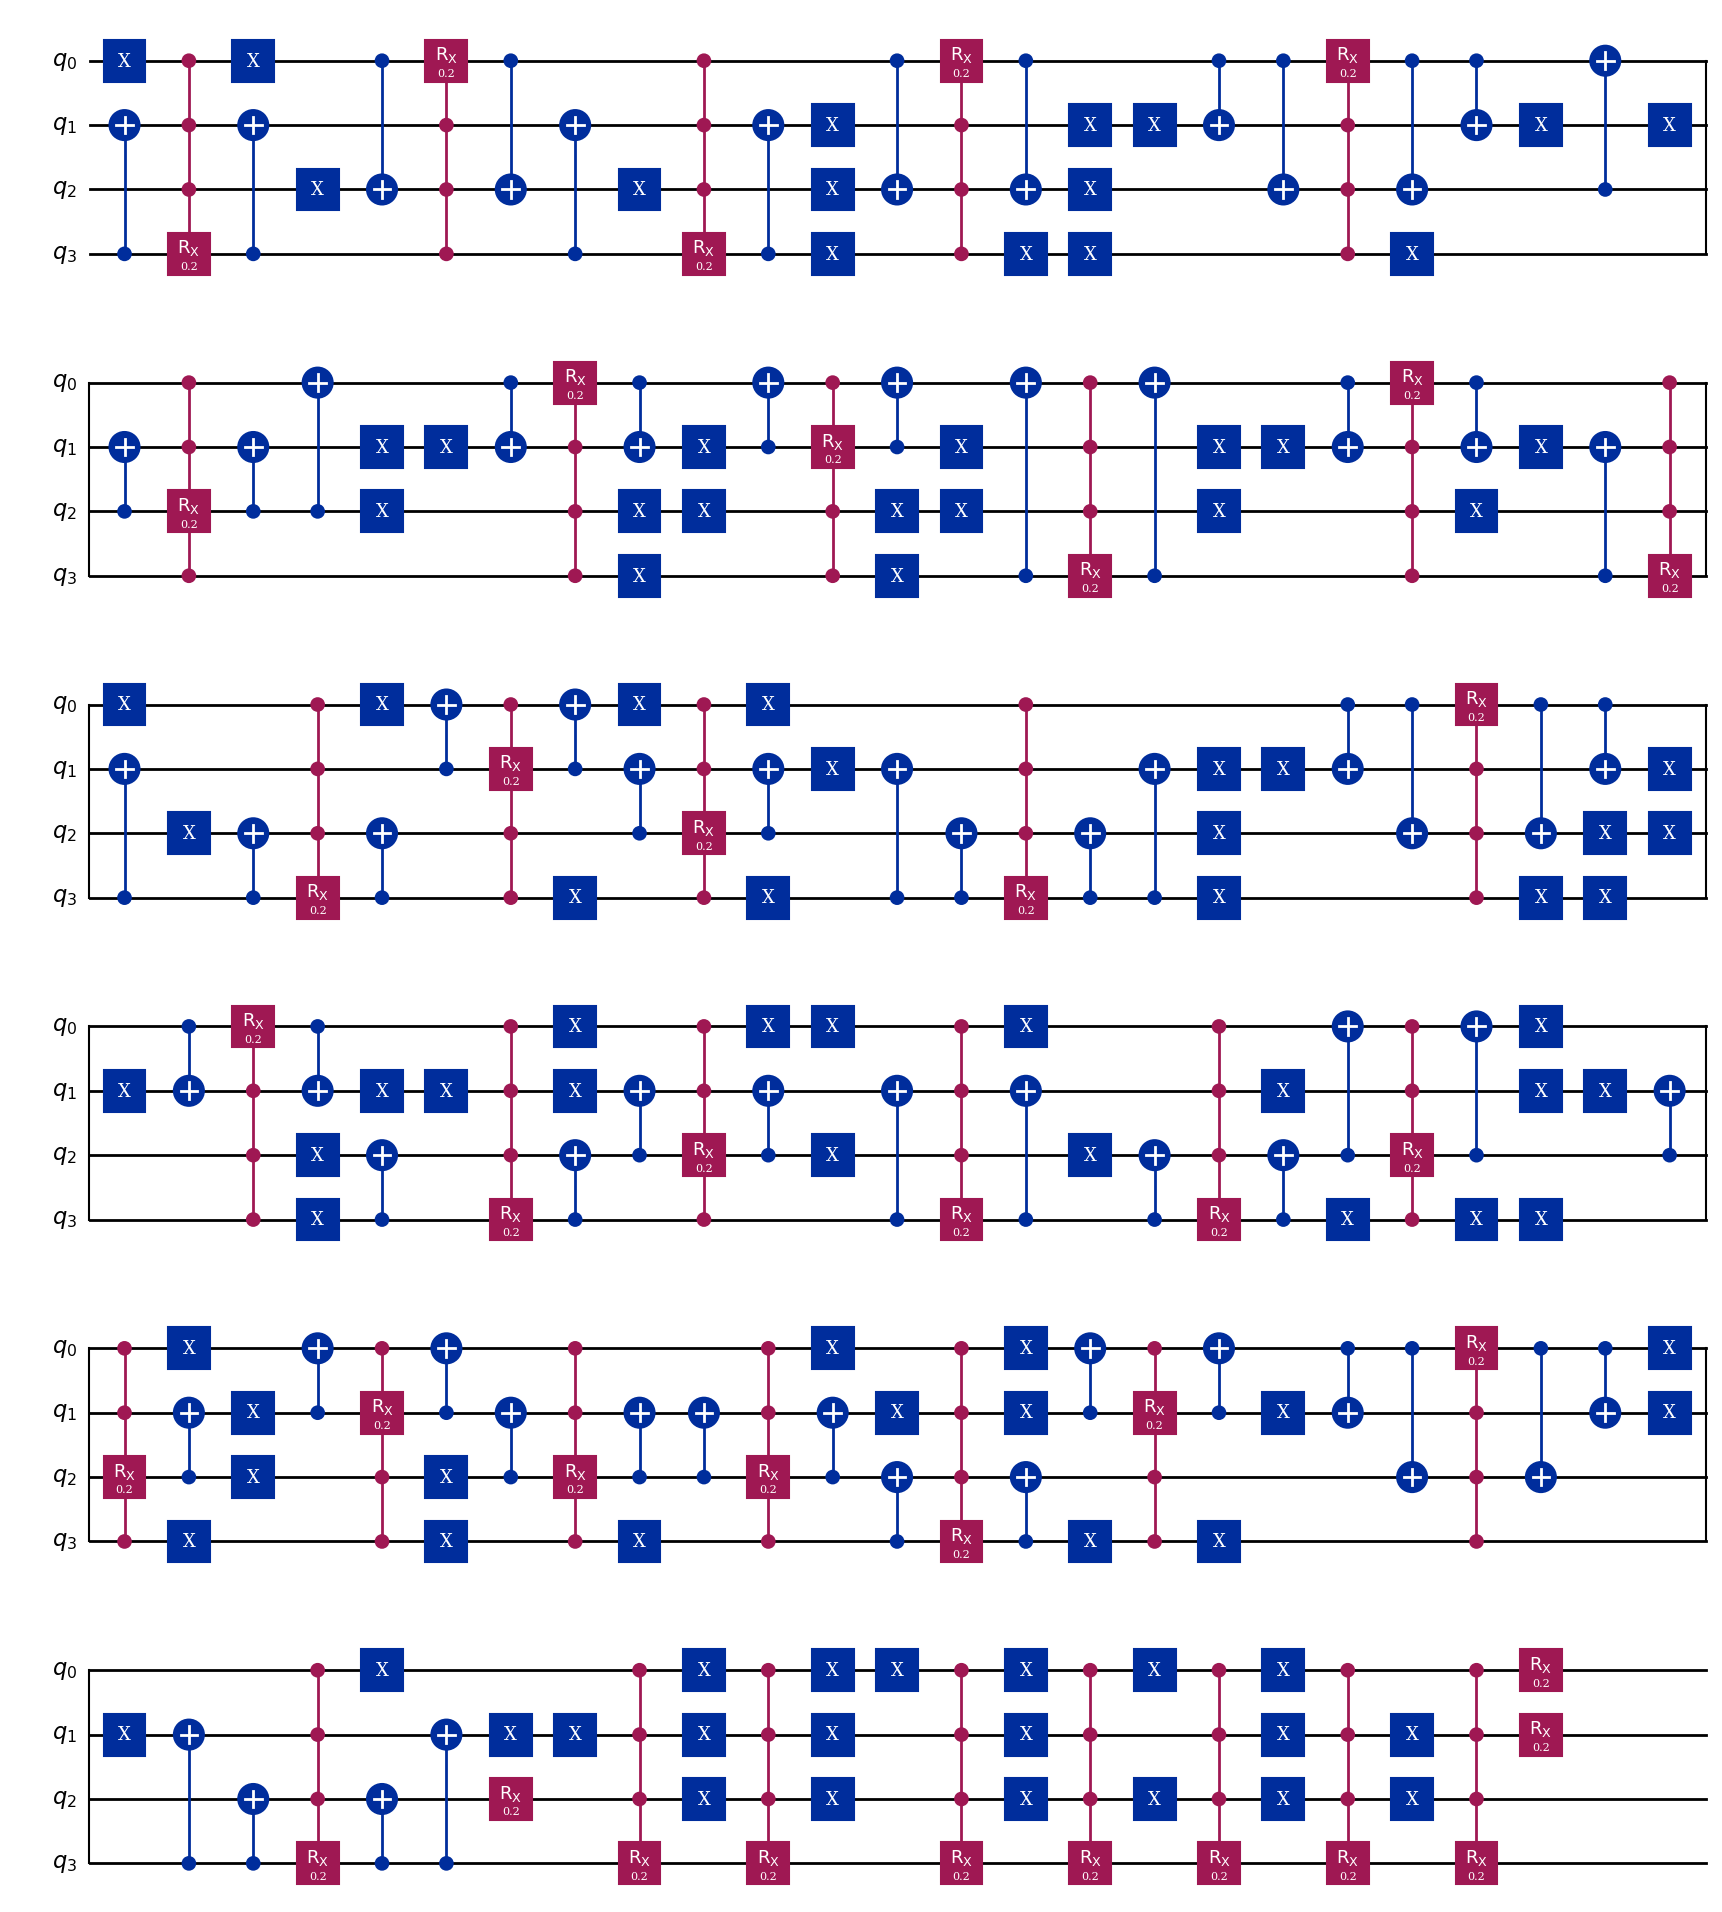


CX Gate Count Summary for Dense Non-Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  808/786                               |  812/788                           |  200/101 
2        | 1616/1572                              | 1624/1576                          |  400/202 
5        | 4040/3930                              | 4060/3940                          | 1000/505 
10       | 8080/7860                              | 8120/7880                          | 2000/1010
20       | 16160/15720                              | 16240/15760                          | 4000/2020
50       | 40400/39300                              | 40600/39400                          | 10000/5050
100      | 80800/78600                              | 81200/78800                          | 20000/10100
Error plot saved as

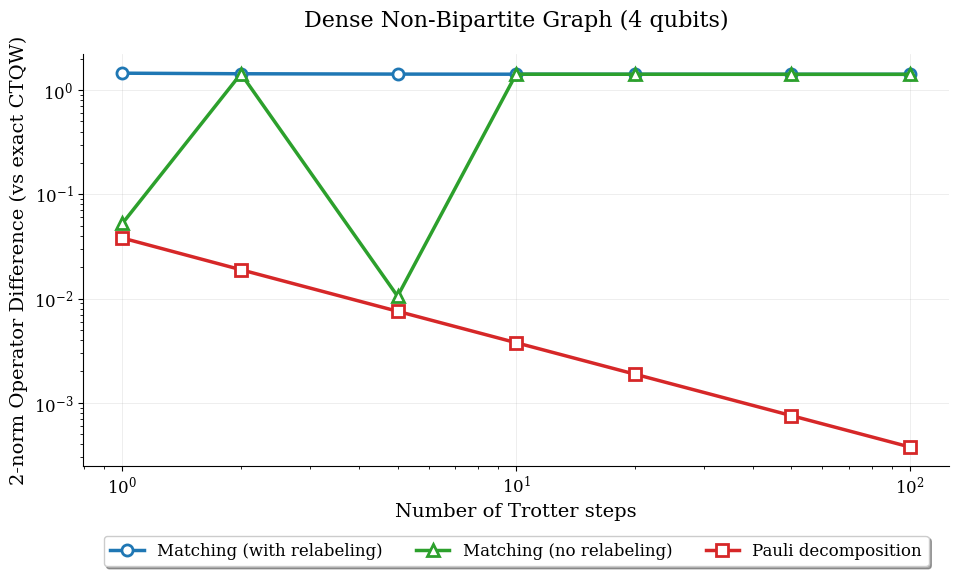

In [13]:
dense_nonbipartite_16 = {
    ('0000','0001'), ('0000','0010'), ('0000','0011'), ('0000','0100'), ('0000','0101'), ('0000','0110'), ('0000','0111'),
    ('0001','0010'), ('0001','0011'), ('0001','0100'), ('0001','0101'), ('0001','1000'), ('0001','1001'),
    ('0010','0011'), ('0010','0100'), ('0010','0110'), ('0010','1000'), ('0010','1010'),
    ('0011','0100'), ('0011','0101'), ('0011','0111'), ('0011','1001'), ('0011','1011'),
    ('0100','0101'), ('0100','0110'), ('0100','1000'), ('0100','1010'), ('0100','1100'),
    ('0101','0110'), ('0101','0111'), ('0101','1001'), ('0101','1011'), ('0101','1101'),
    ('0110','0111'), ('0110','1010'), ('0110','1100'), ('0110','1110'),
    ('0111','1011'), ('0111','1101'), ('0111','1111'),
    ('1000','1001'), ('1000','1010'), ('1000','1011'), ('1000','1100'),
    ('1001','1010'), ('1001','1011'), ('1001','1101'), ('1001','1110'),
    ('1010','1011'), ('1010','1100'), ('1010','1110'), ('1010','1111'),
    ('1011','1100'), ('1011','1101'), ('1011','1111'),
    ('1100','1101'), ('1100','1110'), ('1100','1111'),
    ('1101','1110'), ('1101','1111'),
    ('1110','1111')
}
analyze_and_plot(dense_nonbipartite_16, "Dense Non-Bipartite Graph (4 qubits)")


Dense Bipartite Graph (4 qubits)
Original edges: {('0010', '1010'), ('0110', '1010'), ('0010', '1110'), ('0010', '1011'), ('0010', '1111'), ('0110', '1110'), ('0110', '1111'), ('0110', '1101'), ('0010', '1101'), ('0010', '1100'), ('0110', '1100'), ('0010', '1001'), ('0110', '1001'), ('0001', '1100'), ('0100', '1010'), ('0101', '1010'), ('0111', '1010'), ('0100', '1110'), ('0100', '1111'), ('0101', '1011'), ('0101', '1111'), ('0010', '1000'), ('0110', '1000'), ('0111', '1011'), ('0111', '1111'), ('0100', '1101'), ('0001', '1000'), ('0101', '1101'), ('0111', '1101'), ('0100', '1100'), ('0100', '1001'), ('0101', '1001'), ('0111', '1001'), ('0000', '1010'), ('0100', '1000'), ('0000', '1110'), ('0000', '1111'), ('0000', '1101'), ('0000', '1100'), ('0000', '1001'), ('0011', '1010'), ('0011', '1110'), ('0011', '1011'), ('0011', '1111'), ('0000', '1000'), ('0001', '1010'), ('0110', '1011'), ('0011', '1101'), ('0001', '1110'), ('0001', '1111'), ('0001', '1011'), ('0011', '1100'), ('0011', '100

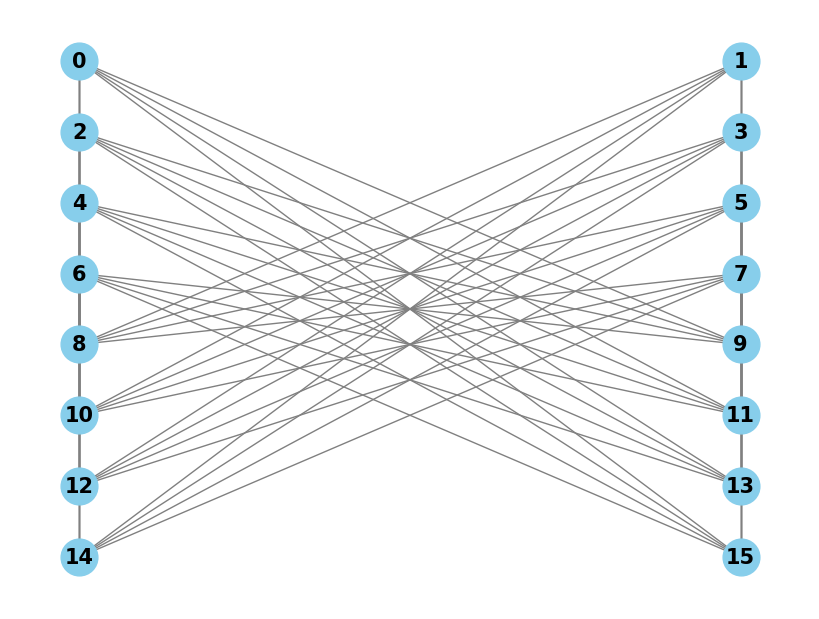

None


Matchings WITH relabeling: 11
Matchings: [{('1001', '1011'), ('0001', '0011'), ('0010', '0000'), ('1010', '1000')}, {('1100', '1011'), ('1010', '1111'), ('0100', '0111'), ('0001', '1101'), ('0110', '0000'), ('1001', '0011'), ('1110', '0101'), ('0010', '1000')}, {('0010', '0111'), ('1100', '1111'), ('1010', '1101'), ('1001', '0101'), ('1110', '0011'), ('0001', '1011'), ('0100', '1000')}, {('1010', '0011'), ('0001', '0111'), ('1001', '1111'), ('0010', '0101'), ('0110', '1101'), ('1100', '0000'), ('1110', '1011')}, {('1100', '0011'), ('1110', '1000'), ('1001', '0111'), ('1010', '0000'), ('0001', '1111'), ('0110', '0101'), ('0010', '1101'), ('0100', '1011')}, {('0001', '1000'), ('1010', '0101'), ('0110', '1111'), ('0010', '1011'), ('1110', '0111'), ('1001', '0000'), ('0100', '0011')}, {('1100', '0101'), ('0100', '1111'), ('1110', '0000'), ('0110', '0011'), ('1010', '0111')}, {('1110', '1101'), ('0010', '1111'), ('0110', '1011'), ('1100', '0111')}, {('0110', '1000'), ('0100', '1101')}, {('

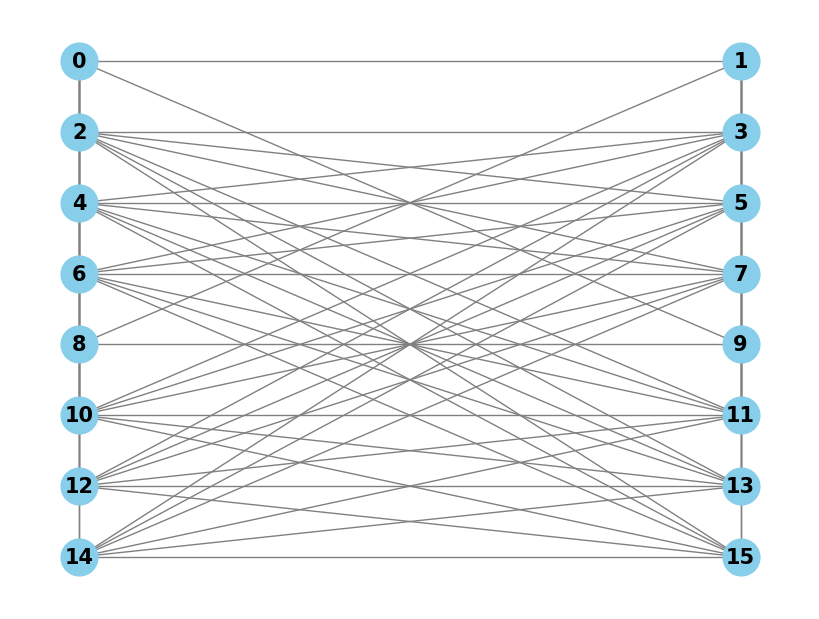

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


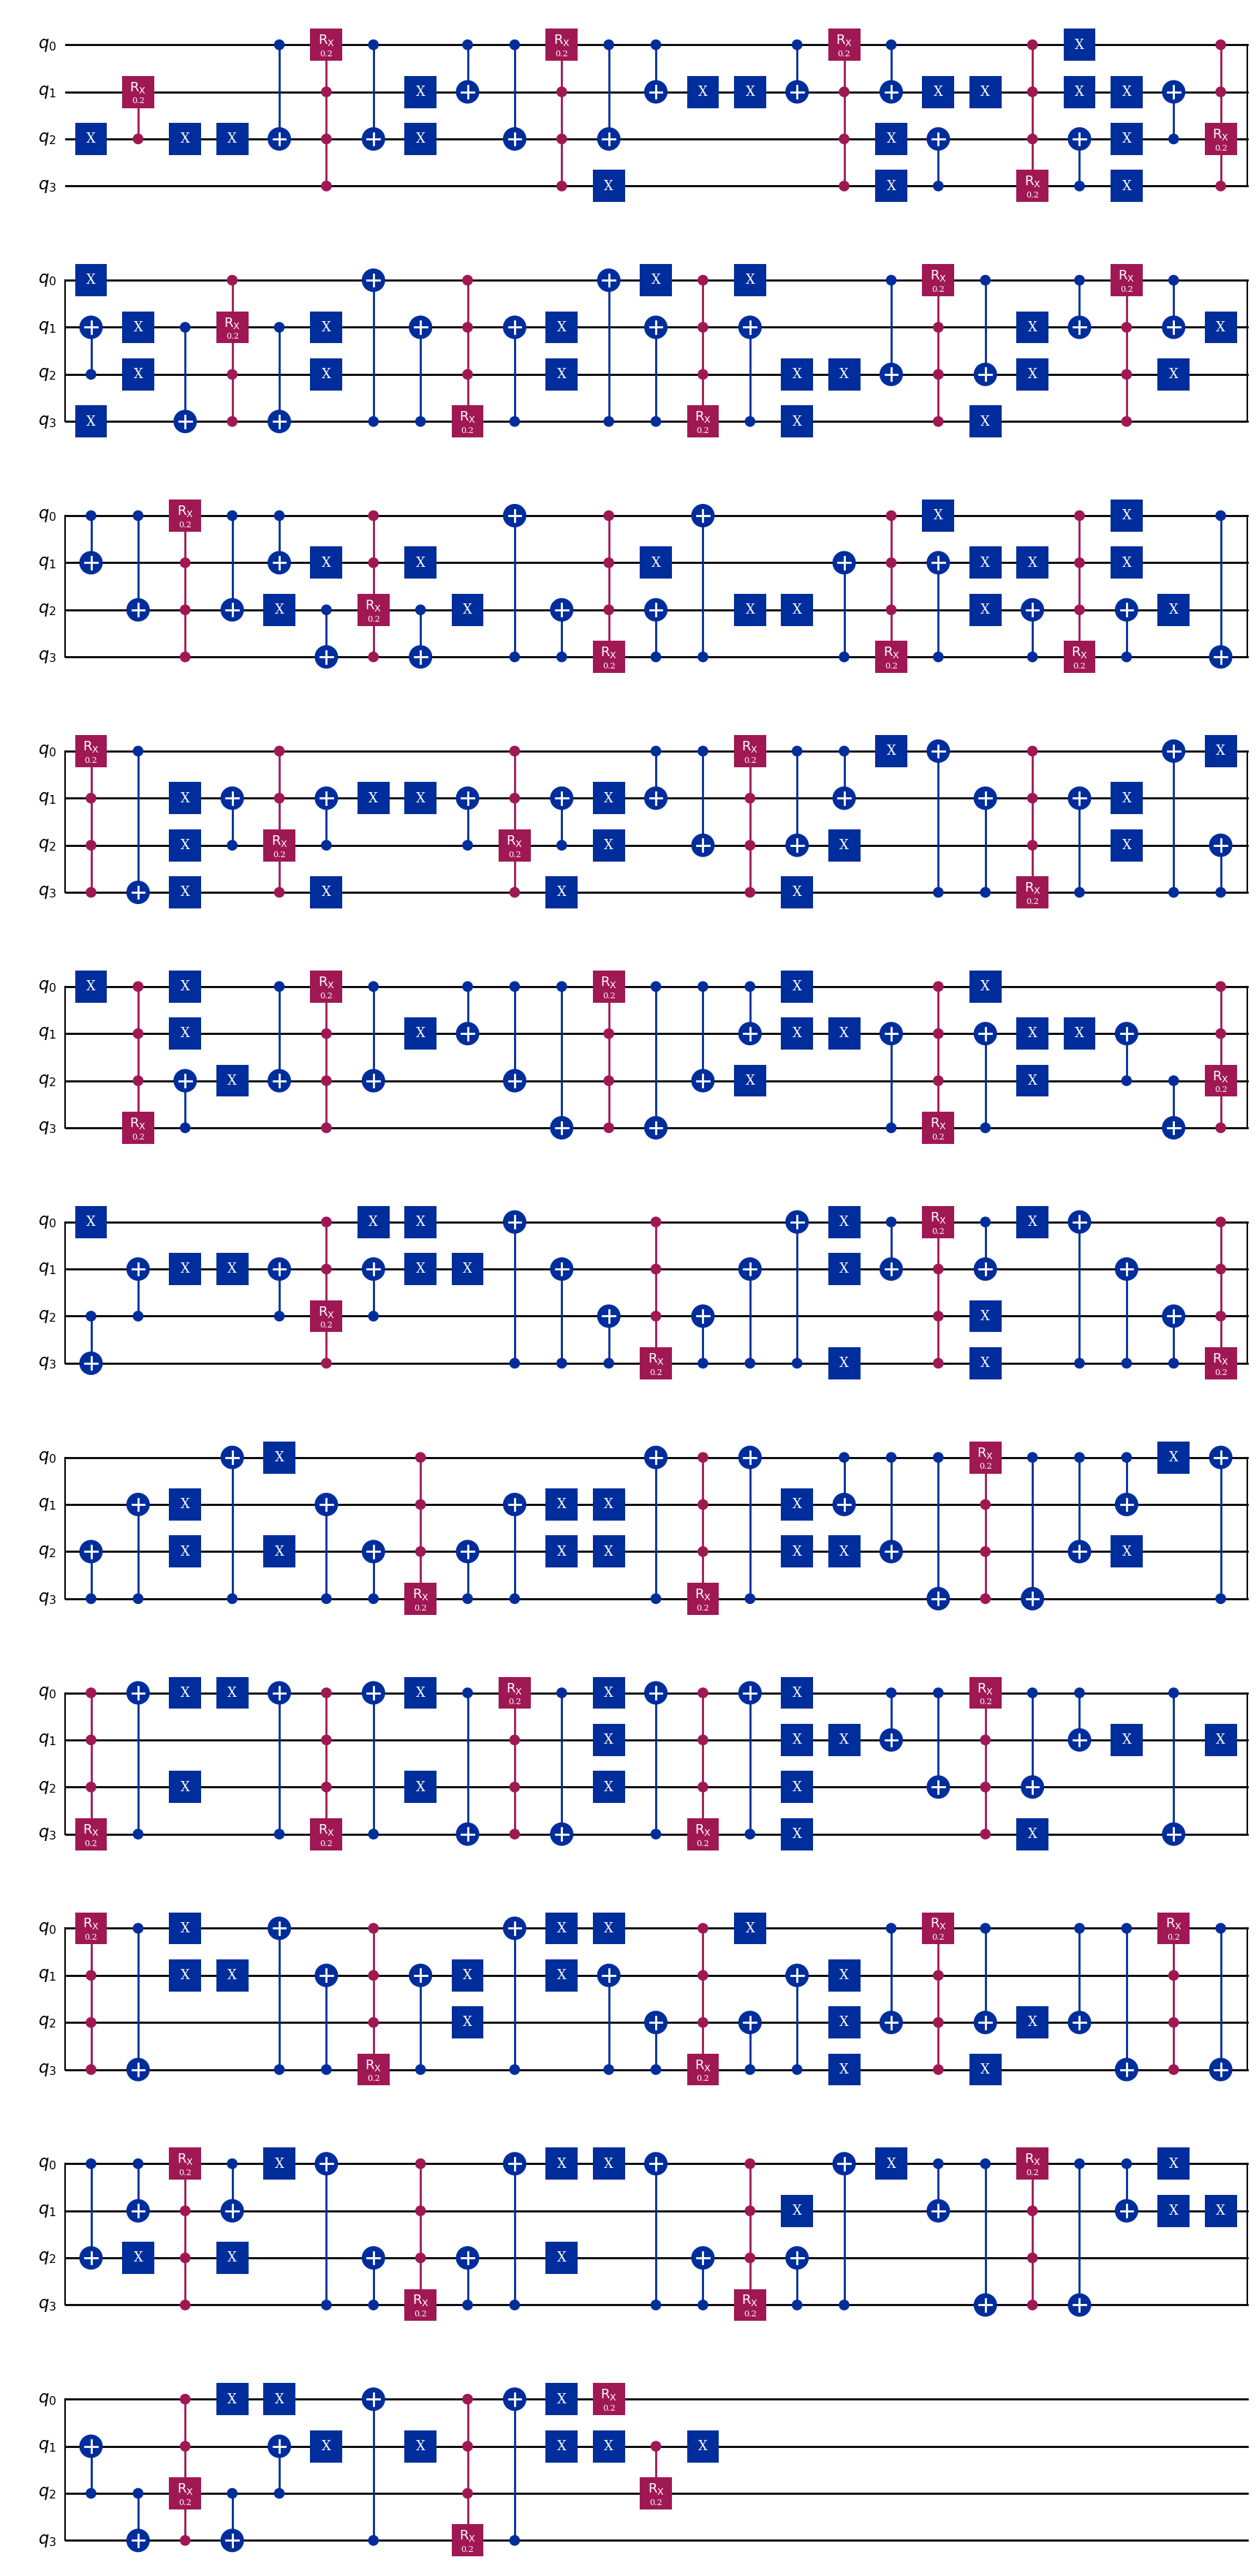


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


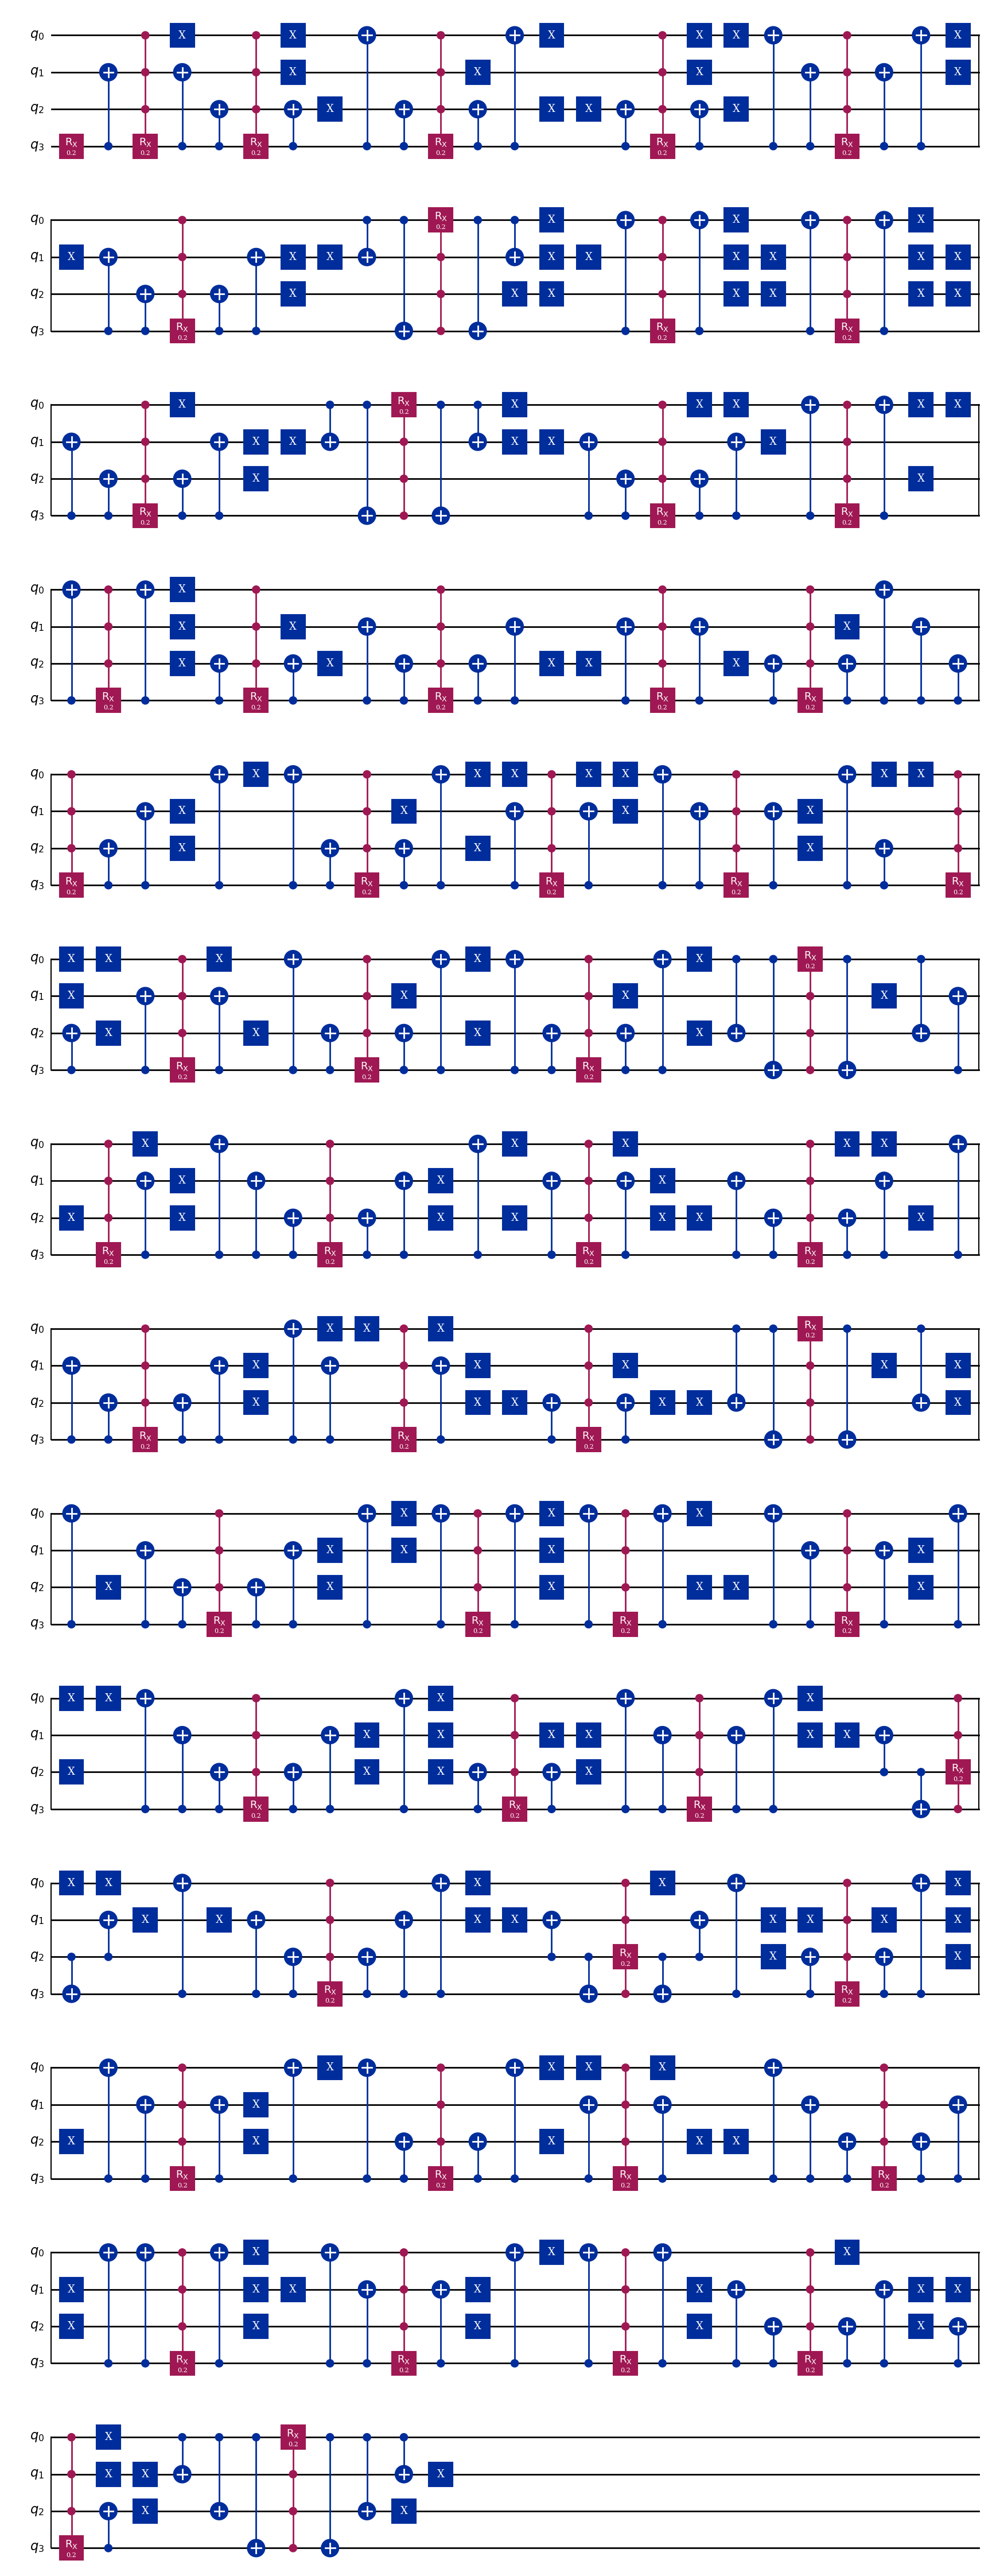


CX Gate Count Summary for Dense Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        | 1108/1044                              | 1312/1211                          |   24/14  
2        | 2216/2086                              | 2624/2422                          |   48/28  
5        | 5540/5212                              | 6560/6055                          |  120/70  
10       | 11080/10422                              | 13120/12110                          |  240/140 
20       | 22160/20842                              | 26240/24220                          |  480/280 
50       | 55400/52102                              | 65600/60550                          | 1200/700 
100      | 110800/104202                              | 131200/121100                          | 2400/1400
Error plot saved a

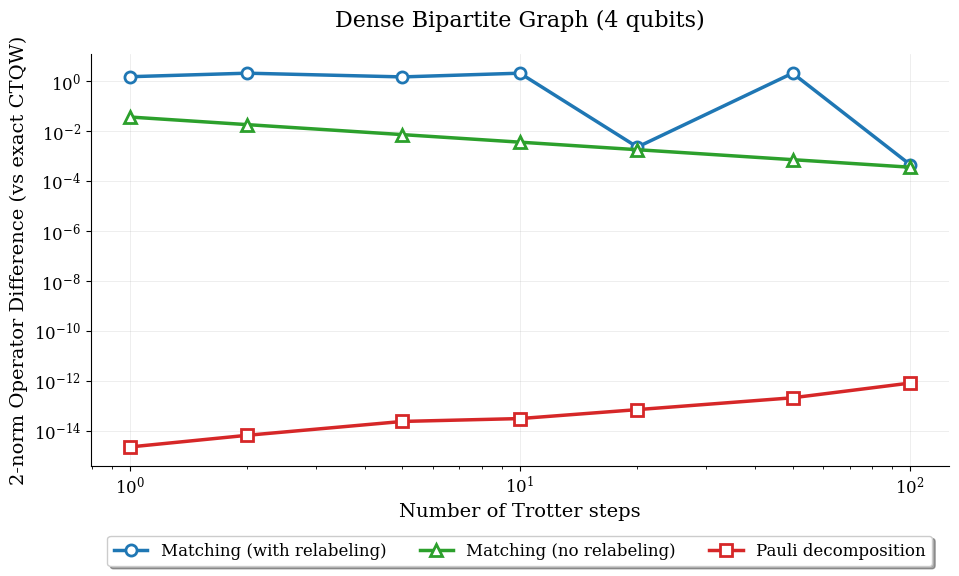

In [14]:
dense_bipartite_16 = {
    ('0000','1000'), ('0000','1001'), ('0000','1010'), ('0000','1011'), ('0000','1100'), ('0000','1101'), ('0000','1110'), ('0000','1111'),
    ('0001','1000'), ('0001','1001'), ('0001','1010'), ('0001','1011'), ('0001','1100'), ('0001','1101'), ('0001','1110'), ('0001','1111'),
    ('0010','1000'), ('0010','1001'), ('0010','1010'), ('0010','1011'), ('0010','1100'), ('0010','1101'), ('0010','1110'), ('0010','1111'),
    ('0011','1000'), ('0011','1001'), ('0011','1010'), ('0011','1011'), ('0011','1100'), ('0011','1101'), ('0011','1110'), ('0011','1111'),
    ('0100','1000'), ('0100','1001'), ('0100','1010'), ('0100','1011'), ('0100','1100'), ('0100','1101'), ('0100','1110'), ('0100','1111'),
    ('0101','1000'), ('0101','1001'), ('0101','1010'), ('0101','1011'), ('0101','1100'), ('0101','1101'), ('0101','1110'), ('0101','1111'),
    ('0110','1000'), ('0110','1001'), ('0110','1010'), ('0110','1011'), ('0110','1100'), ('0110','1101'), ('0110','1110'), ('0110','1111'),
    ('0111','1000'), ('0111','1001'), ('0111','1010'), ('0111','1011'), ('0111','1100'), ('0111','1101'), ('0111','1110'), ('0111','1111')
}

analyze_and_plot(dense_bipartite_16, "Dense Bipartite Graph (4 qubits)")


Sparse Non-Bipartite Graph (4 qubits)
Original edges: {('1000', '1001'), ('0011', '1011'), ('0011', '0100'), ('0000', '1000'), ('1011', '1100'), ('0110', '0111'), ('1001', '1010'), ('0010', '0000'), ('0101', '0110'), ('1100', '1101'), ('1010', '1000'), ('0001', '0010'), ('0100', '0101'), ('0111', '0011'), ('0000', '0001'), ('1110', '1111')}
Number of qubits: 4

Original Graph:


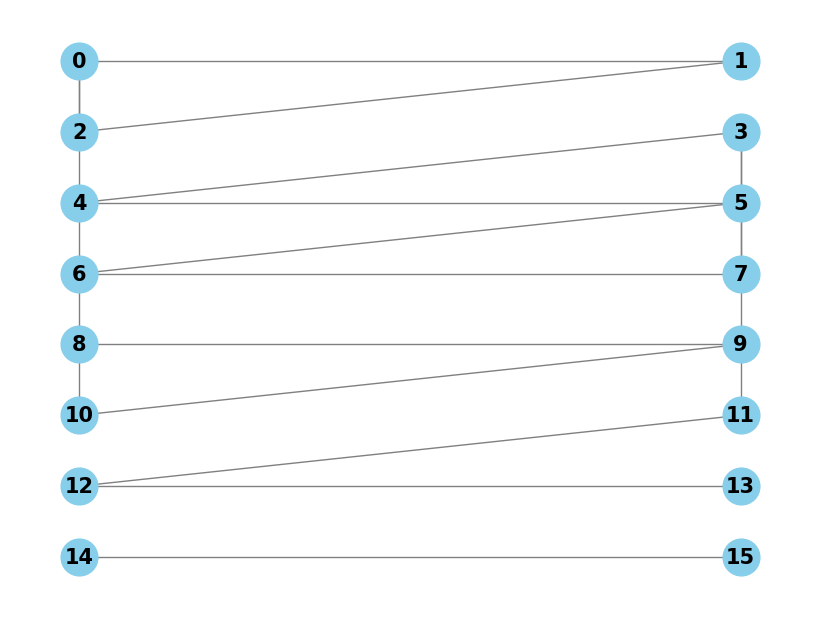

None


Matchings WITH relabeling: 5
Matchings: [{('0111', '0011'), ('1001', '1101'), ('1000', '1100')}, {('0000', '1000'), ('0011', '1011')}, {('0001', '0010'), ('1100', '1010'), ('0101', '0110'), ('0011', '0100')}, {('0010', '0000'), ('1010', '1000'), ('1011', '1001')}, {('0110', '0111'), ('0000', '0001'), ('1110', '1111'), ('0100', '0101')}]
Relabeled edges: {('0110', '0111'), ('1110', '1111'), ('0011', '1011'), ('0101', '0110'), ('0011', '0100'), ('0010', '0000'), ('1010', '1000'), ('0000', '1000'), ('0001', '0010'), ('0100', '0101'), ('0111', '0011'), ('0000', '0001'), ('1100', '1010'), ('1001', '1101'), ('1000', '1100'), ('1011', '1001')}

Matchings WITHOUT relabeling: 5
Matchings: [{('0110', '0111'), ('1000', '1001'), ('1100', '1101'), ('0100', '0101'), ('0000', '0001'), ('1110', '1111')}, {('1001', '1010'), ('0011', '1011'), ('0101', '0110'), ('0000', '1000'), ('0001', '0010')}, {('1011', '1100'), ('0011', '0100')}, {('0010', '0000'), ('1010', '1000')}, {('0111', '0011')}]
Number of q

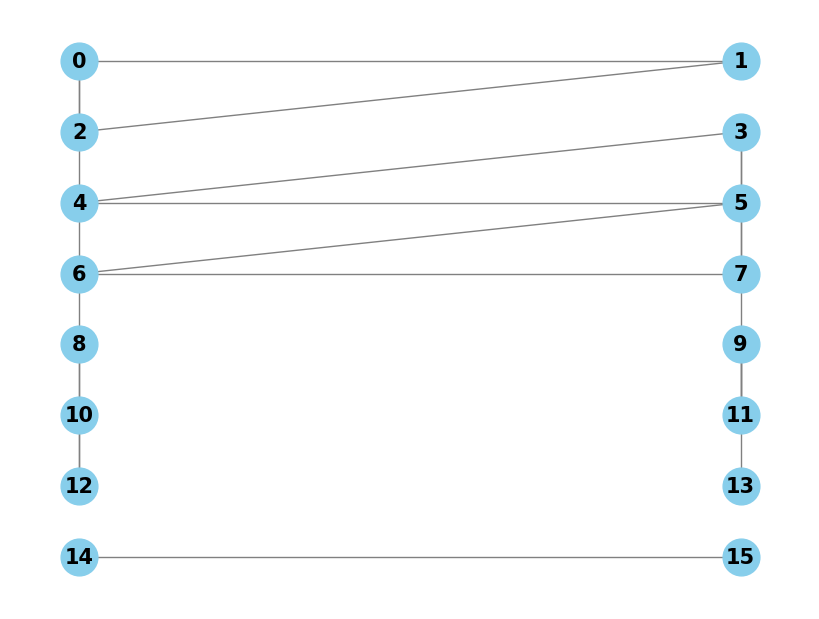

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


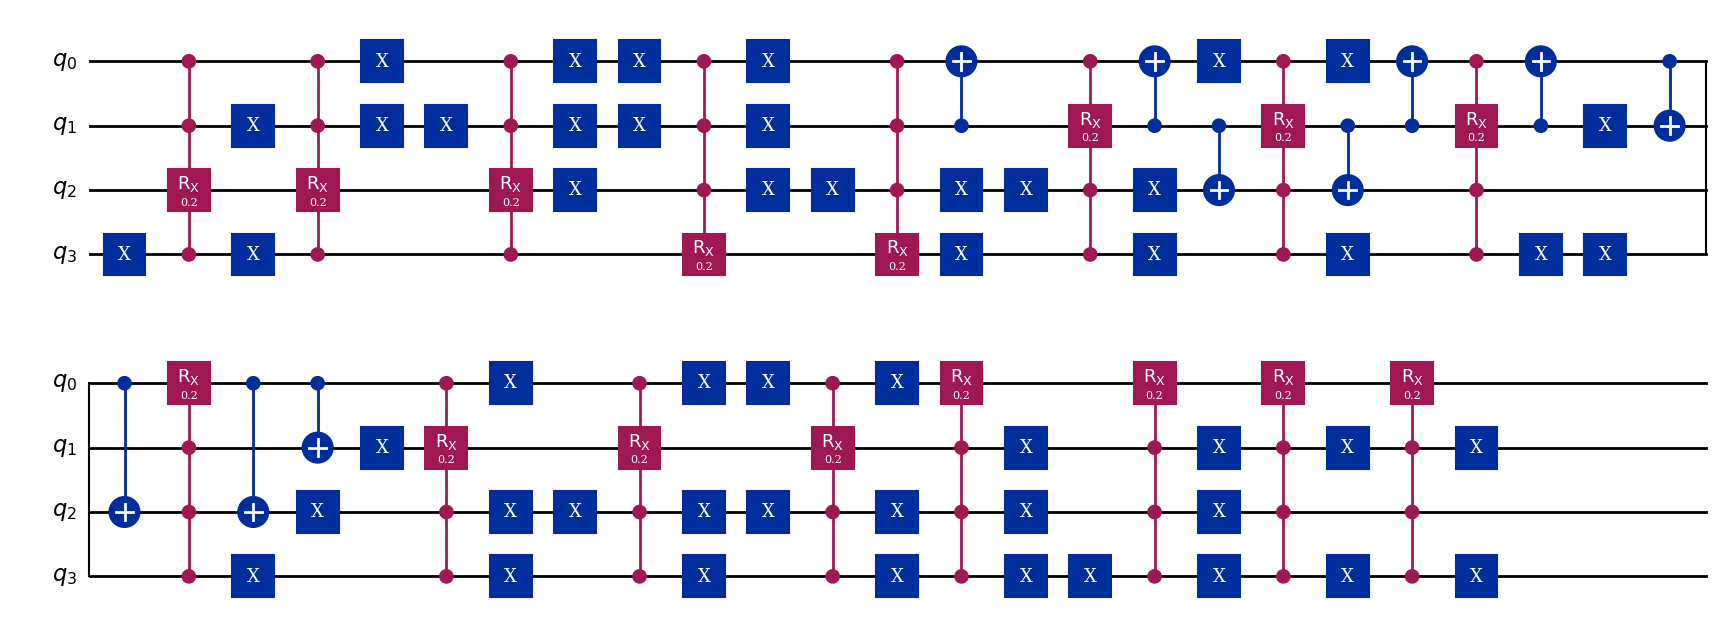


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


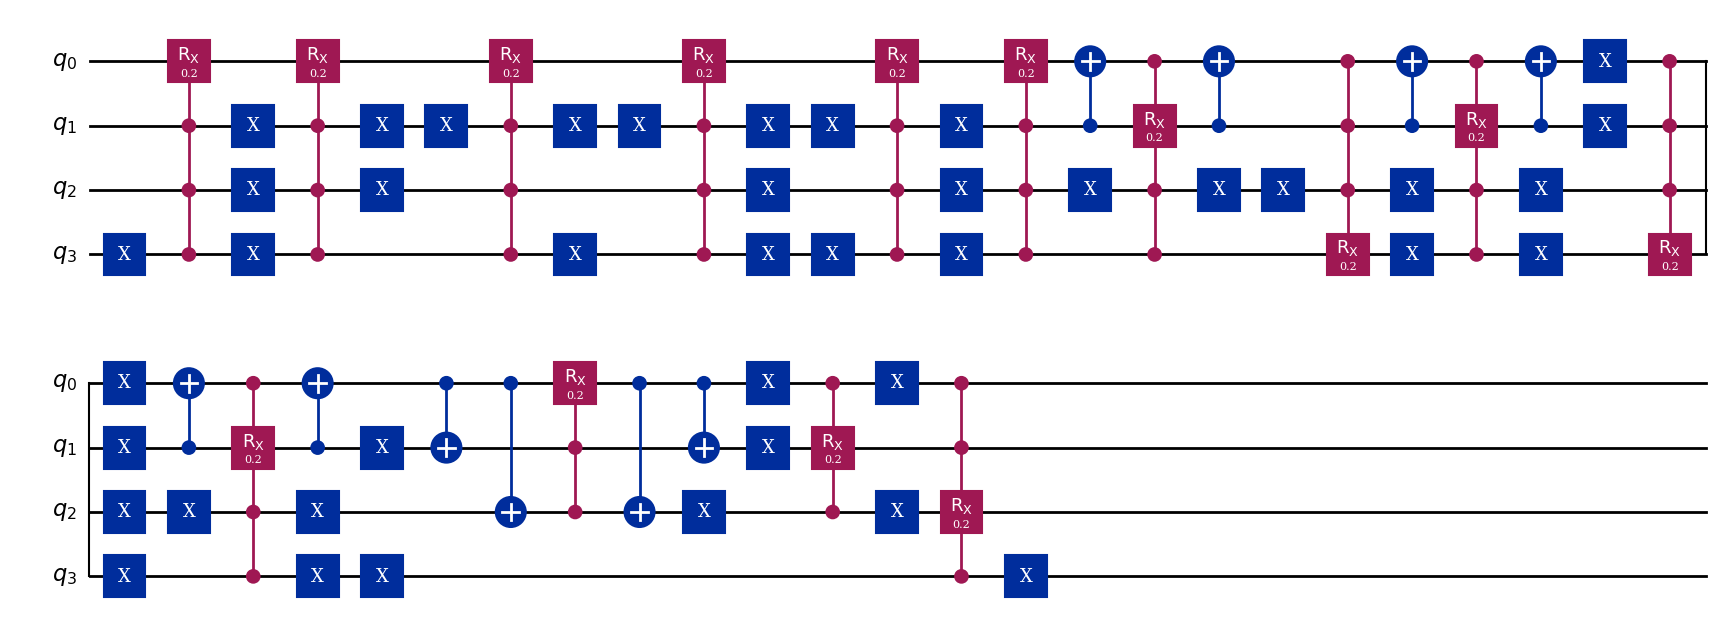


CX Gate Count Summary for Sparse Non-Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  330/328                               |  266/261                           |  100/61  
2        |  660/656                               |  532/522                           |  200/122 
5        | 1650/1640                              | 1330/1305                          |  500/305 
10       | 3300/3280                              | 2660/2610                          | 1000/610 
20       | 6600/6560                              | 5320/5220                          | 2000/1220
50       | 16500/16400                              | 13300/13050                          | 5000/3050
100      | 33000/32800                              | 26600/26100                          | 10000/6100
Error plot saved as: tro

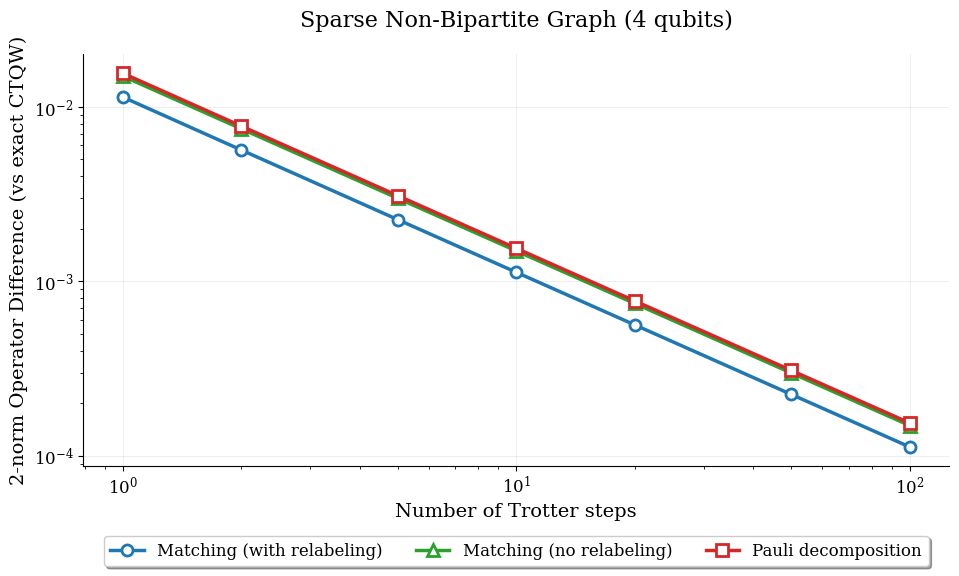

In [15]:
sparse_nonbipartite_16 = {
    ('0000','0001'), ('0001','0010'), ('0010','0000'),           # Triangle
    ('0011','0100'), ('0100','0101'), ('0101','0110'), ('0110','0111'), ('0111','0011'),  # Pentagon
    ('1000','1001'), ('1001','1010'), ('1010','1000'),         # Triangle
    ('1011','1100'), ('1100','1101'),
    ('1110','1111'),
    ('0000','1000'), ('0011','1011')  # Connecting components
}

analyze_and_plot(sparse_nonbipartite_16, "Sparse Non-Bipartite Graph (4 qubits)")


Sparse Bipartite Graph (4 qubits)
Original edges: {('0010', '0001'), ('1100', '1111'), ('1010', '1001'), ('1100', '1011'), ('0000', '0011'), ('0100', '0111'), ('0110', '1001'), ('1110', '1101'), ('1010', '1101'), ('0010', '0101'), ('0110', '0101'), ('0100', '0011'), ('1000', '1011'), ('0000', '0001'), ('1000', '0111')}
Number of qubits: 4

Original Graph:


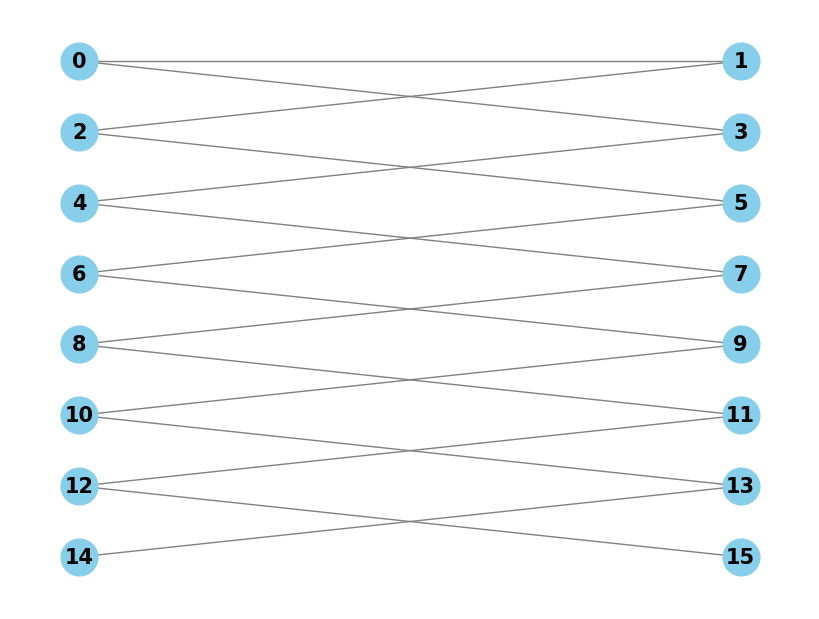

None


Matchings WITH relabeling: 5
Matchings: [{('1011', '1010'), ('0011', '0010'), ('1100', '1101'), ('0111', '0110'), ('1111', '1110'), ('0101', '0100'), ('0000', '0001'), ('1001', '1000')}, {('0011', '0110'), ('1011', '1101'), ('1111', '0100'), ('1001', '0010')}, {('0000', '1000')}, {('0101', '0001')}, {('1100', '1110')}]
Relabeled edges: {('1011', '1010'), ('0011', '0010'), ('0011', '0110'), ('0101', '0001'), ('1001', '0010'), ('1100', '1101'), ('0111', '0110'), ('1011', '1101'), ('1111', '1110'), ('0000', '1000'), ('0101', '0100'), ('0000', '0001'), ('1100', '1110'), ('1001', '1000'), ('1111', '0100')}

Matchings WITHOUT relabeling: 3
Matchings: [{('0010', '0001'), ('1010', '1001'), ('1100', '1111'), ('0000', '0011'), ('0100', '0111'), ('1110', '1101'), ('0110', '0101'), ('1000', '1011')}, {('1100', '1011'), ('0110', '1001'), ('1010', '1101'), ('0010', '0101'), ('0100', '0011'), ('1000', '0111')}, {('0000', '0001')}]
Number of qubits: 4

Relabeled Graph:


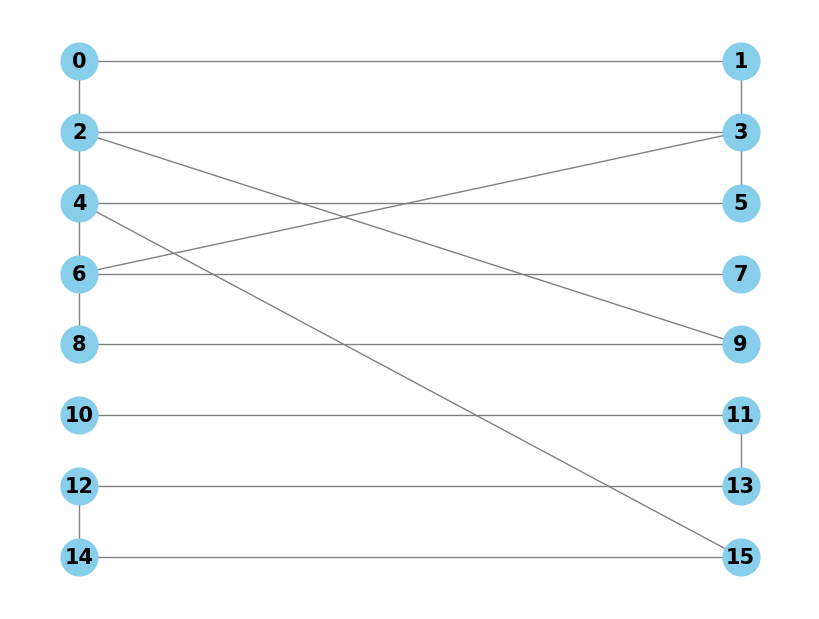

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


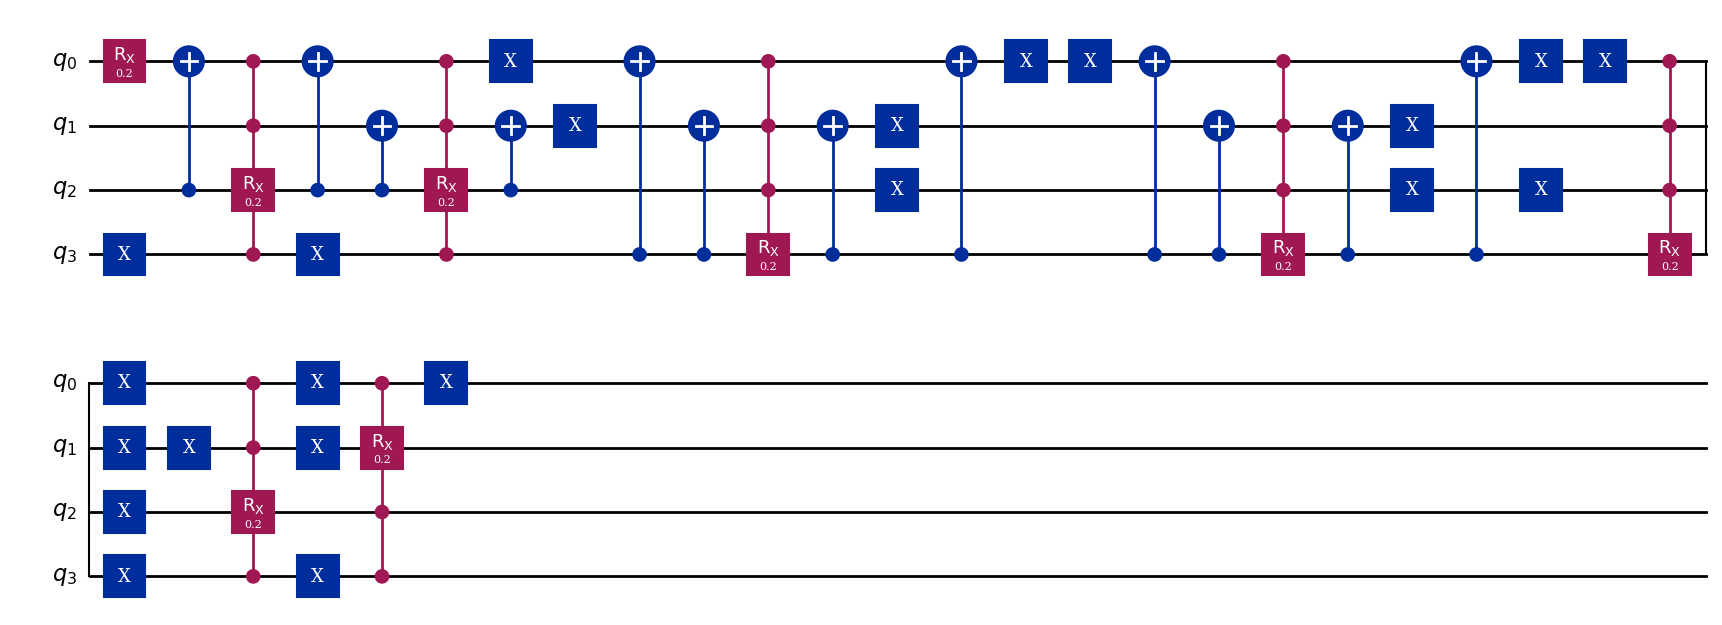


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


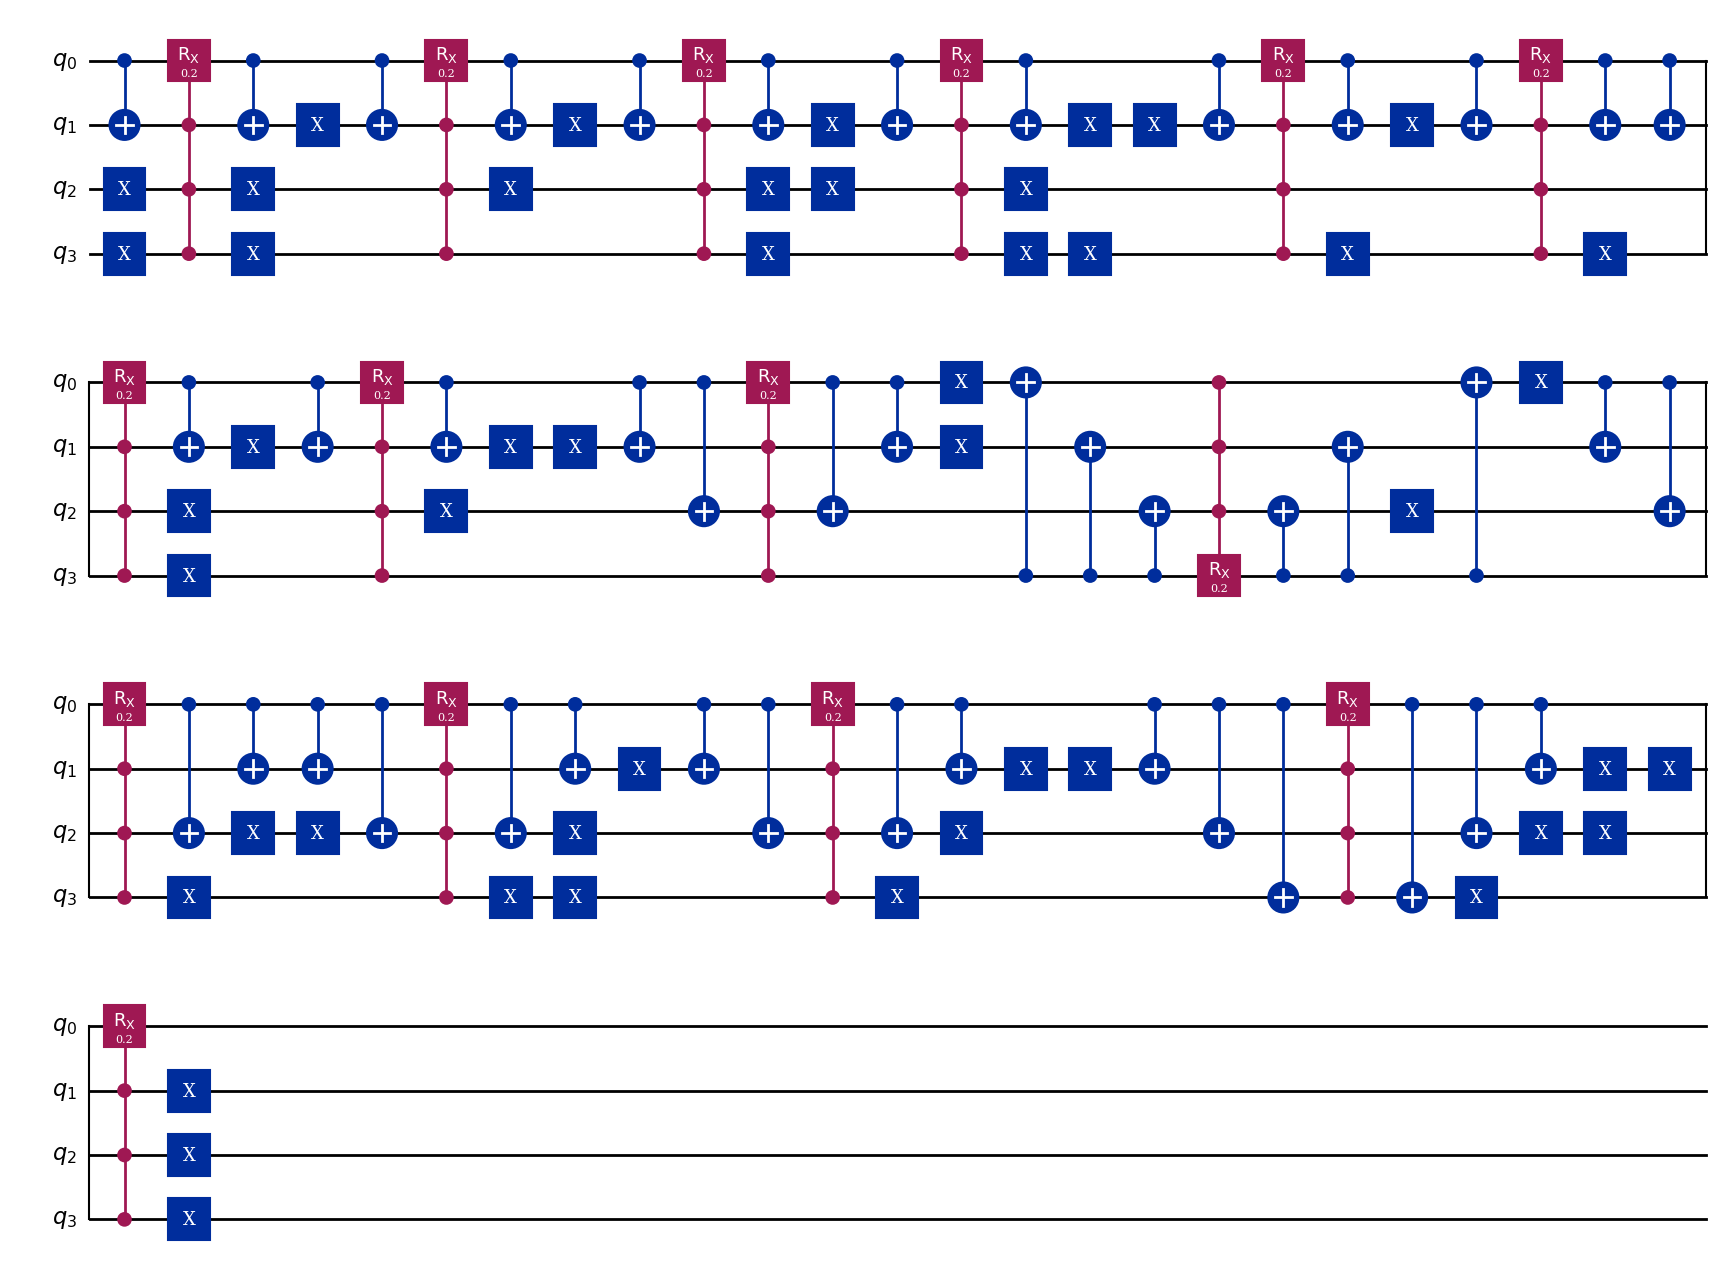


CX Gate Count Summary for Sparse Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  152/147                               |  344/314                           |   58/52  
2        |  304/294                               |  688/627                           |  116/104 
5        |  760/735                               | 1720/1566                          |  290/260 
10       | 1520/1470                              | 3440/3131                          |  580/520 
20       | 3040/2940                              | 6880/6261                          | 1160/1040
50       | 7600/7350                              | 17200/15651                          | 2900/2600
100      | 15200/14700                              | 34400/31301                          | 5800/5200
Error plot saved as: trotteriza

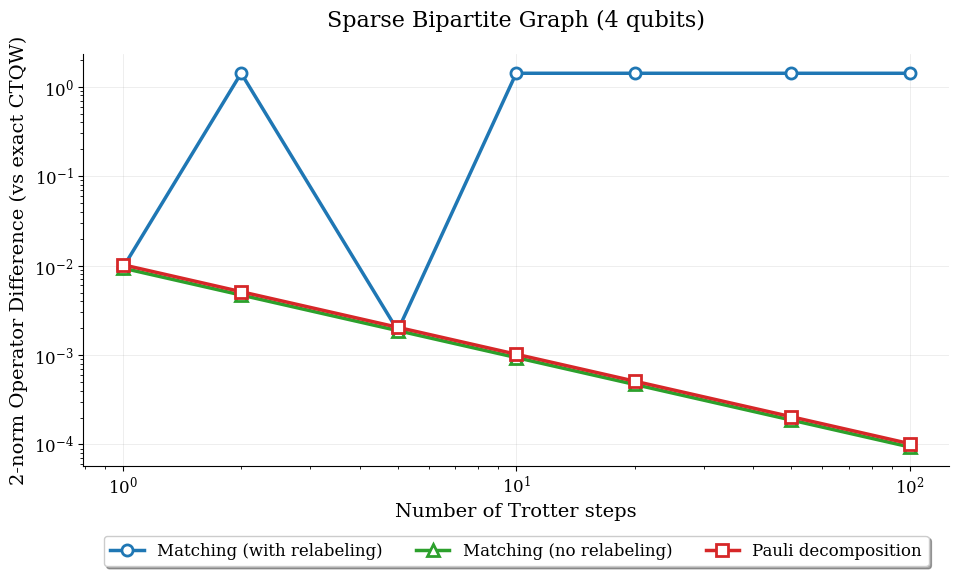

In [16]:
sparse_bipartite_16 = {
    ('0000','0001'), ('0000','0011'),
    ('0010','0001'), ('0010','0101'),
    ('0100','0011'), ('0100','0111'),
    ('0110','0101'), ('0110','1001'),
    ('1000','0111'), ('1000','1011'),
    ('1010','1001'), ('1010','1101'),
    ('1100','1011'), ('1100','1111'),
    ('1110','1101')
}
analyze_and_plot(sparse_bipartite_16, "Sparse Bipartite Graph (4 qubits)")


Cayley Graph of Z2 x Z2 x Z2 (3 qubits)
Original edges: {('000', '100'), ('001', '101'), ('010', '011'), ('100', '101'), ('010', '110'), ('001', '011'), ('000', '001'), ('110', '111'), ('011', '111'), ('101', '111'), ('000', '010'), ('100', '110')}
Number of qubits: 3

Original Graph:


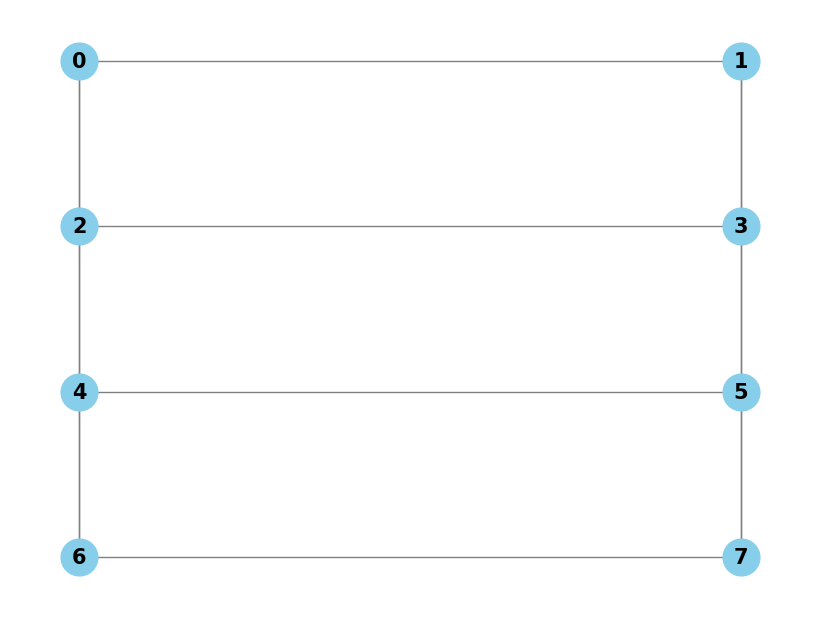

None


Matchings WITH relabeling: 3
Matchings: [{('000', '100'), ('010', '110'), ('011', '111'), ('001', '101')}, {('110', '111'), ('000', '001'), ('100', '101'), ('010', '011')}, {('001', '011'), ('000', '010'), ('100', '110'), ('101', '111')}]
Relabeled edges: {('000', '100'), ('001', '101'), ('100', '101'), ('010', '011'), ('010', '110'), ('001', '011'), ('110', '111'), ('000', '001'), ('011', '111'), ('101', '111'), ('000', '010'), ('100', '110')}

Matchings WITHOUT relabeling: 3
Matchings: [{('000', '100'), ('010', '110'), ('011', '111'), ('001', '101')}, {('110', '111'), ('000', '001'), ('100', '101'), ('010', '011')}, {('001', '011'), ('000', '010'), ('100', '110'), ('101', '111')}]
Number of qubits: 3

Relabeled Graph:


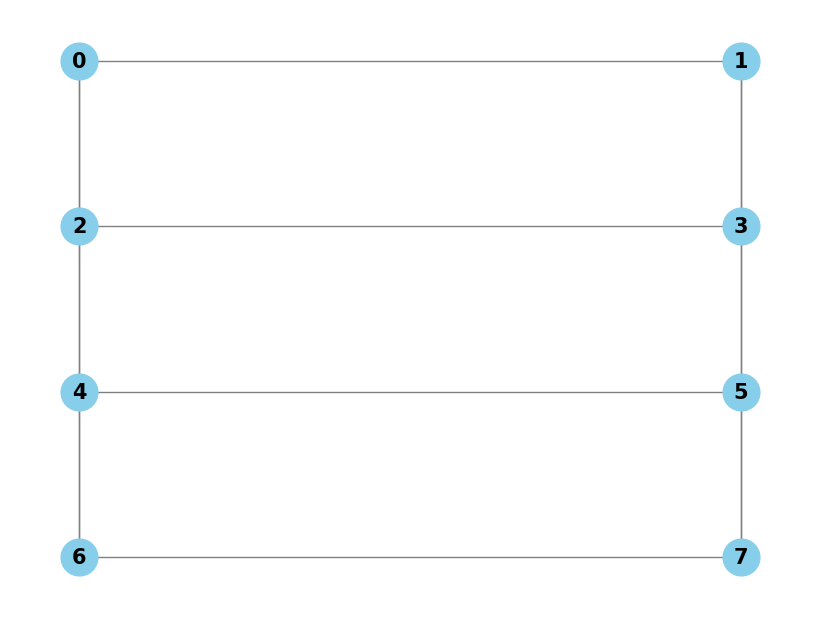

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


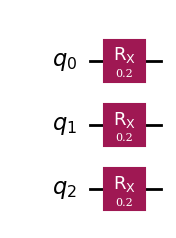


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


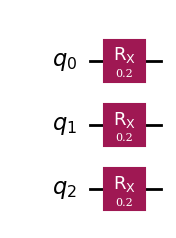


CX Gate Count Summary for Cayley Graph of Z2 x Z2 x Z2 (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                             |    0/0   
2        |    0/0                                 |    0/0                             |    0/0   
5        |    0/0                                 |    0/0                             |    0/0   
10       |    0/0                                 |    0/0                             |    0/0   
20       |    0/0                                 |    0/0                             |    0/0   
50       |    0/0                                 |    0/0                             |    0/0   
100      |    0/0                                 |    0/0                             |    0/0   
Error plot saved as: trotteriza

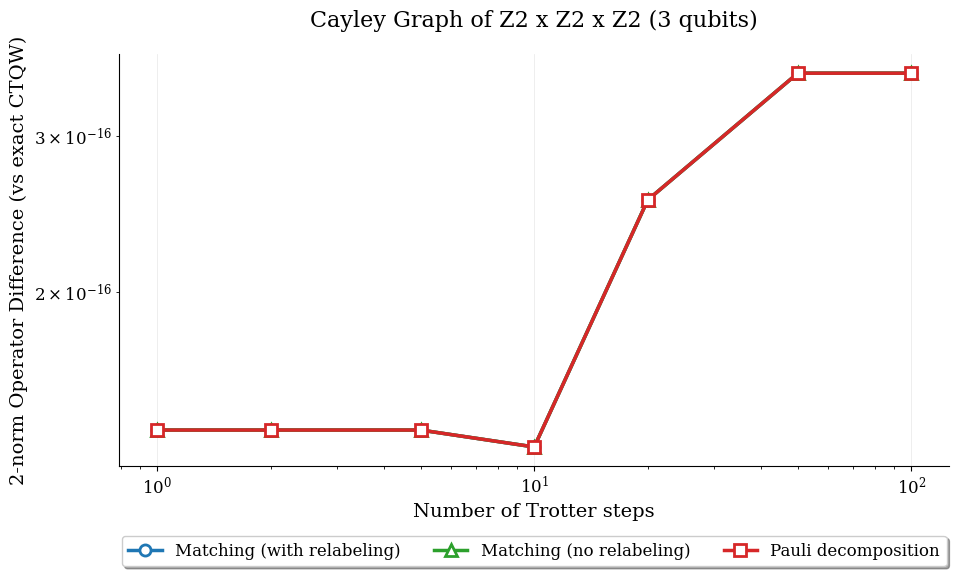

In [17]:
cayley_8 = set()
vertices_8 = [format(i, '03b') for i in range(8)]
generators_8 = ['001', '010', '100']
for v in vertices_8:
    v_int = int(v, 2)
    for g in generators_8:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '03b')
        if v < neighbor:  # Avoid duplicates
            cayley_8.add((v, neighbor))

analyze_and_plot(cayley_8, "Cayley Graph of Z2 x Z2 x Z2 (3 qubits)")


Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)
Original edges: {('1010', '1110'), ('0010', '1010'), ('0101', '0111'), ('0011', '1011'), ('1010', '1011'), ('0110', '1110'), ('0000', '1000'), ('1100', '1110'), ('1000', '1010'), ('1100', '1101'), ('0001', '1001'), ('1001', '1011'), ('0111', '1111'), ('1001', '1101'), ('0000', '0010'), ('1000', '1100'), ('1110', '1111'), ('0101', '1101'), ('1000', '1001'), ('1011', '1111'), ('0100', '1100'), ('0010', '0011'), ('0010', '0110'), ('0001', '0011'), ('0011', '0111'), ('0001', '0101'), ('0110', '0111'), ('1101', '1111'), ('0000', '0100'), ('0100', '0110'), ('0100', '0101'), ('0000', '0001')}
Number of qubits: 4

Original Graph:


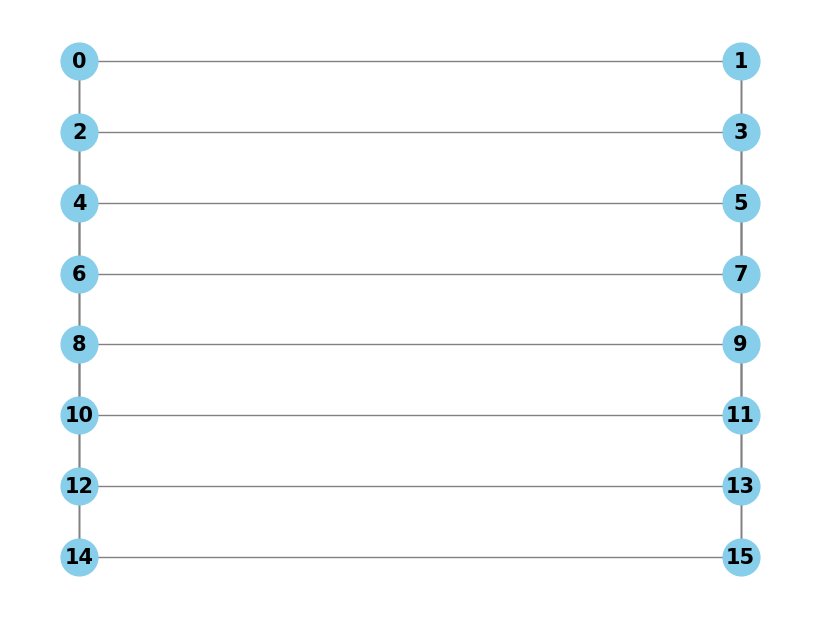

None


Matchings WITH relabeling: 4
Matchings: [{('1010', '1110'), ('0001', '0101'), ('1011', '1111'), ('0010', '0110'), ('0000', '0100'), ('1001', '1101'), ('0011', '0111'), ('1000', '1100')}, {('0101', '1101'), ('0010', '1010'), ('0100', '1100'), ('0011', '1011'), ('0110', '1110'), ('0000', '1000'), ('0001', '1001'), ('0111', '1111')}, {('1000', '1010'), ('0101', '0111'), ('1101', '1111'), ('0100', '0110'), ('1001', '1011'), ('0001', '0011'), ('1100', '1110'), ('0000', '0010')}, {('0110', '0111'), ('1000', '1001'), ('1010', '1011'), ('0010', '0011'), ('1100', '1101'), ('0100', '0101'), ('0000', '0001'), ('1110', '1111')}]
Relabeled edges: {('0101', '1101'), ('1000', '1001'), ('1010', '1110'), ('0010', '1010'), ('1011', '1111'), ('0100', '1100'), ('0101', '0111'), ('0011', '1011'), ('0010', '0110'), ('0110', '1110'), ('1010', '1011'), ('0010', '0011'), ('0000', '1000'), ('0001', '0011'), ('1100', '1110'), ('0011', '0111'), ('0001', '0101'), ('1110', '1111'), ('0110', '0111'), ('1000', '1010

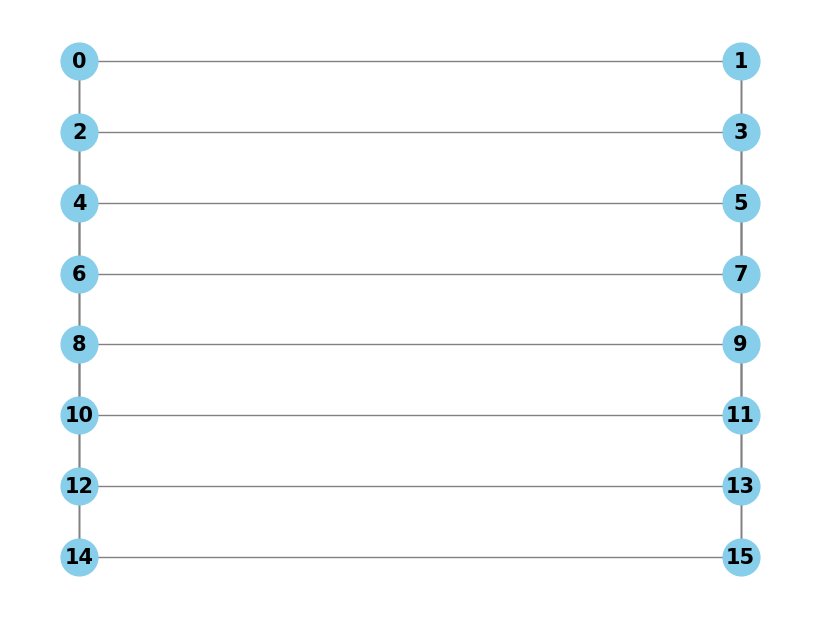

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


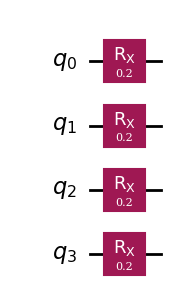


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


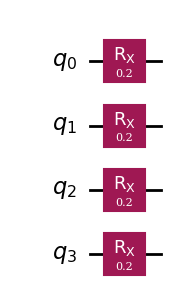


CX Gate Count Summary for Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                             |    0/0   
2        |    0/0                                 |    0/0                             |    0/0   
5        |    0/0                                 |    0/0                             |    0/0   
10       |    0/0                                 |    0/0                             |    0/0   
20       |    0/0                                 |    0/0                             |    0/0   
50       |    0/0                                 |    0/0                             |    0/0   
100      |    0/0                                 |    0/0                             |    0/0   
Error plot saved as: trott

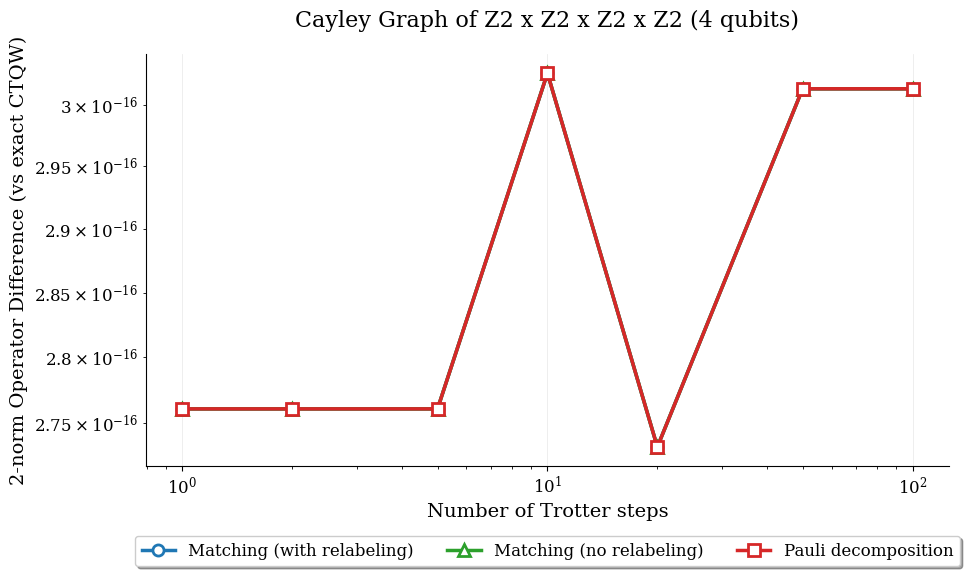

In [18]:
cayley_16 = set()
vertices_16 = [format(i, '04b') for i in range(16)]
generators_16 = ['0001', '0010', '0100', '1000']
for v in vertices_16:
    v_int = int(v, 2)
    for g in generators_16:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '04b')
        if v < neighbor:  # Avoid duplicates
            cayley_16.add((v, neighbor))
analyze_and_plot(cayley_16, "Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)")


Circulant Graph C8(1,2) (3 qubits)
Original edges: {('010', '011'), ('100', '101'), ('001', '010'), ('001', '011'), ('000', '001'), ('011', '101'), ('101', '110'), ('110', '111'), ('100', '110'), ('011', '100'), ('101', '111'), ('000', '010'), ('010', '100')}
Number of qubits: 3

Original Graph:


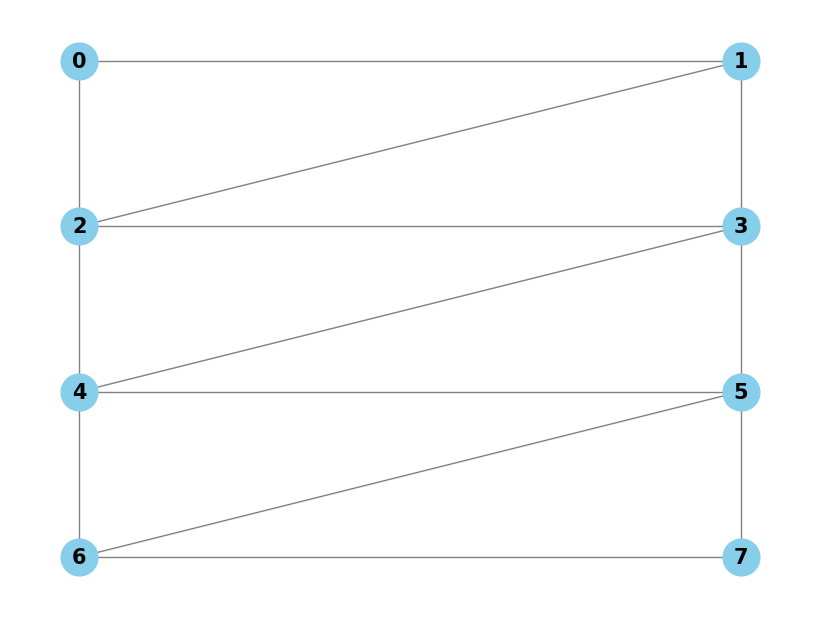

None


Matchings WITH relabeling: 5
Matchings: [{('101', '100'), ('000', '001'), ('111', '110'), ('010', '011')}, {('111', '101'), ('001', '011'), ('000', '010'), ('110', '100')}, {('001', '010'), ('011', '101')}, {('010', '111'), ('101', '110')}, {('011', '111')}]
Relabeled edges: {('101', '100'), ('010', '011'), ('001', '010'), ('111', '110'), ('001', '011'), ('000', '001'), ('111', '101'), ('011', '101'), ('101', '110'), ('011', '111'), ('110', '100'), ('010', '111'), ('000', '010')}

Matchings WITHOUT relabeling: 5
Matchings: [{('110', '111'), ('000', '001'), ('100', '101'), ('010', '011')}, {('001', '010'), ('011', '101')}, {('011', '100'), ('101', '110')}, {('010', '100')}, {('000', '010'), ('001', '011'), ('100', '110'), ('101', '111')}]
Number of qubits: 3

Relabeled Graph:


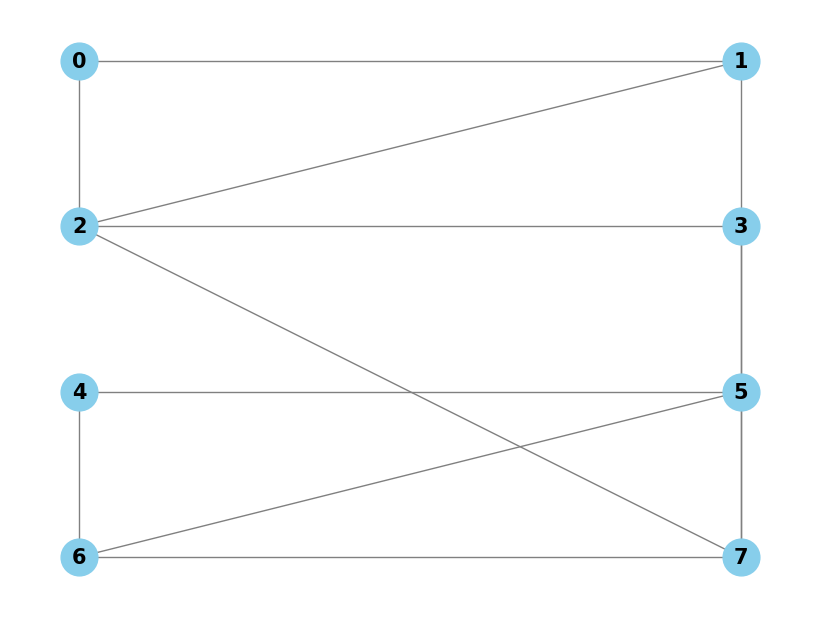

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


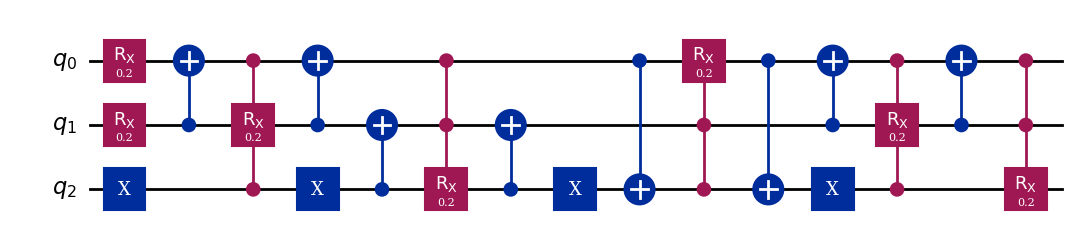


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


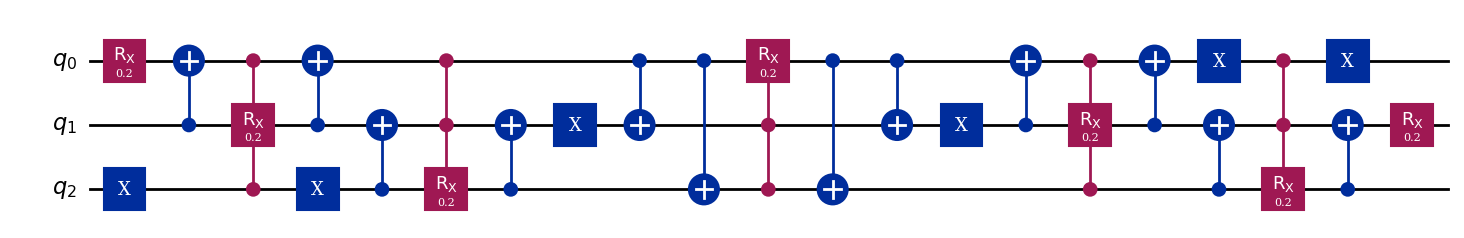


CX Gate Count Summary for Circulant Graph C8(1,2) (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   48/44                                |   52/47                            |   24/16  
2        |   96/88                                |  104/94                            |   48/32  
5        |  240/220                               |  260/235                           |  120/80  
10       |  480/440                               |  520/470                           |  240/160 
20       |  960/880                               | 1040/940                           |  480/320 
50       | 2400/2200                              | 2600/2350                          | 1200/800 
100      | 4800/4400                              | 5200/4700                          | 2400/1600
Error plot saved as: trotterization_

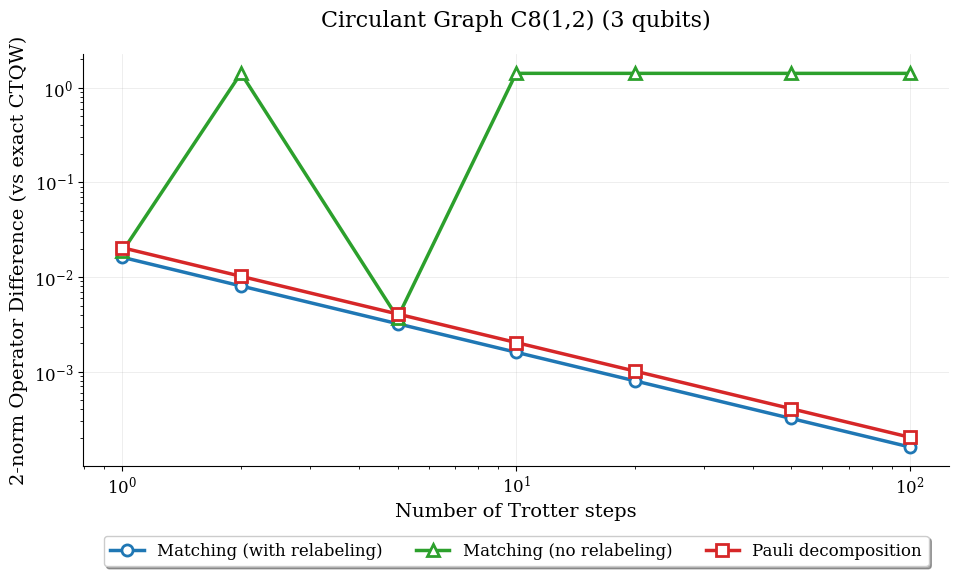

In [19]:
circulant_8 = set()
n = 8
offsets_8 = [1, 2]
for i in range(n):
    v = format(i, '03b')
    for offset in offsets_8:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '03b')
        if v < neighbor:  # Avoid duplicates
            circulant_8.add((v, neighbor))
analyze_and_plot(circulant_8, "Circulant Graph C8(1,2) (3 qubits)")


Circulant Graph C16(1,3,5) (4 qubits)
Original edges: {('1010', '1111'), ('0100', '0111'), ('1010', '1011'), ('0011', '0100'), ('1010', '1101'), ('0110', '1011'), ('0001', '0100'), ('1100', '1111'), ('0000', '0011'), ('0110', '1001'), ('0000', '0101'), ('1001', '1010'), ('0101', '1010'), ('1100', '1101'), ('1001', '1110'), ('1000', '1011'), ('0111', '1010'), ('1000', '1101'), ('0011', '1000'), ('1110', '1111'), ('1000', '1001'), ('0011', '0110'), ('1001', '1100'), ('1011', '1110'), ('0111', '1100'), ('0100', '1001'), ('0010', '0011'), ('0010', '0101'), ('0001', '0110'), ('1011', '1100'), ('0101', '1000'), ('0111', '1000'), ('0010', '0111'), ('0110', '0111'), ('1101', '1110'), ('0101', '0110'), ('0001', '0010'), ('0100', '0101'), ('0000', '0001')}
Number of qubits: 4

Original Graph:


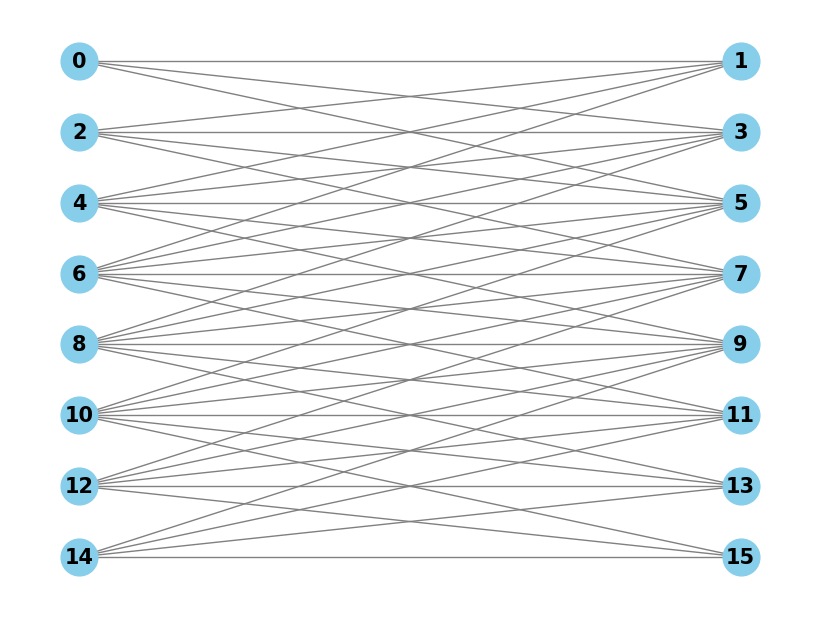

None


Matchings WITH relabeling: 8
Matchings: [{('0110', '1100'), ('1010', '1111'), ('0000', '0101'), ('0011', '0100'), ('1001', '1110'), ('0001', '0010'), ('1000', '1101'), ('0111', '1011')}, {('1100', '1111'), ('0000', '0011'), ('1010', '1101'), ('0010', '0101'), ('1000', '1011'), ('0111', '1001'), ('0001', '0100')}, {('1001', '1010'), ('0001', '0111'), ('0011', '1000'), ('1011', '1110')}, {('1001', '1100'), ('0110', '1000'), ('1101', '1110'), ('0101', '1010')}, {('0101', '1000'), ('0100', '1001'), ('1011', '1100'), ('0110', '1010')}, {('0100', '0110'), ('0101', '0111')}, {('1000', '1001'), ('1010', '1011'), ('0010', '0011'), ('1100', '1101'), ('0111', '0110'), ('0100', '0101'), ('0000', '0001'), ('1110', '1111')}, {('0010', '0110'), ('0011', '0111')}]
Relabeled edges: {('1010', '1111'), ('0110', '1010'), ('0101', '0111'), ('1010', '1011'), ('0011', '0100'), ('1010', '1101'), ('0001', '0100'), ('0110', '1100'), ('1100', '1111'), ('0000', '0011'), ('0000', '0101'), ('1001', '1010'), ('0101

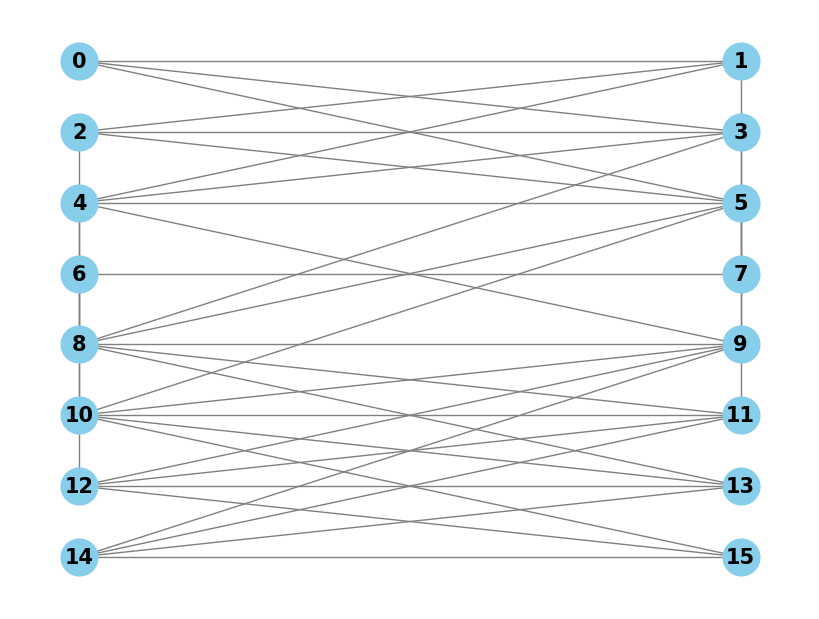

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


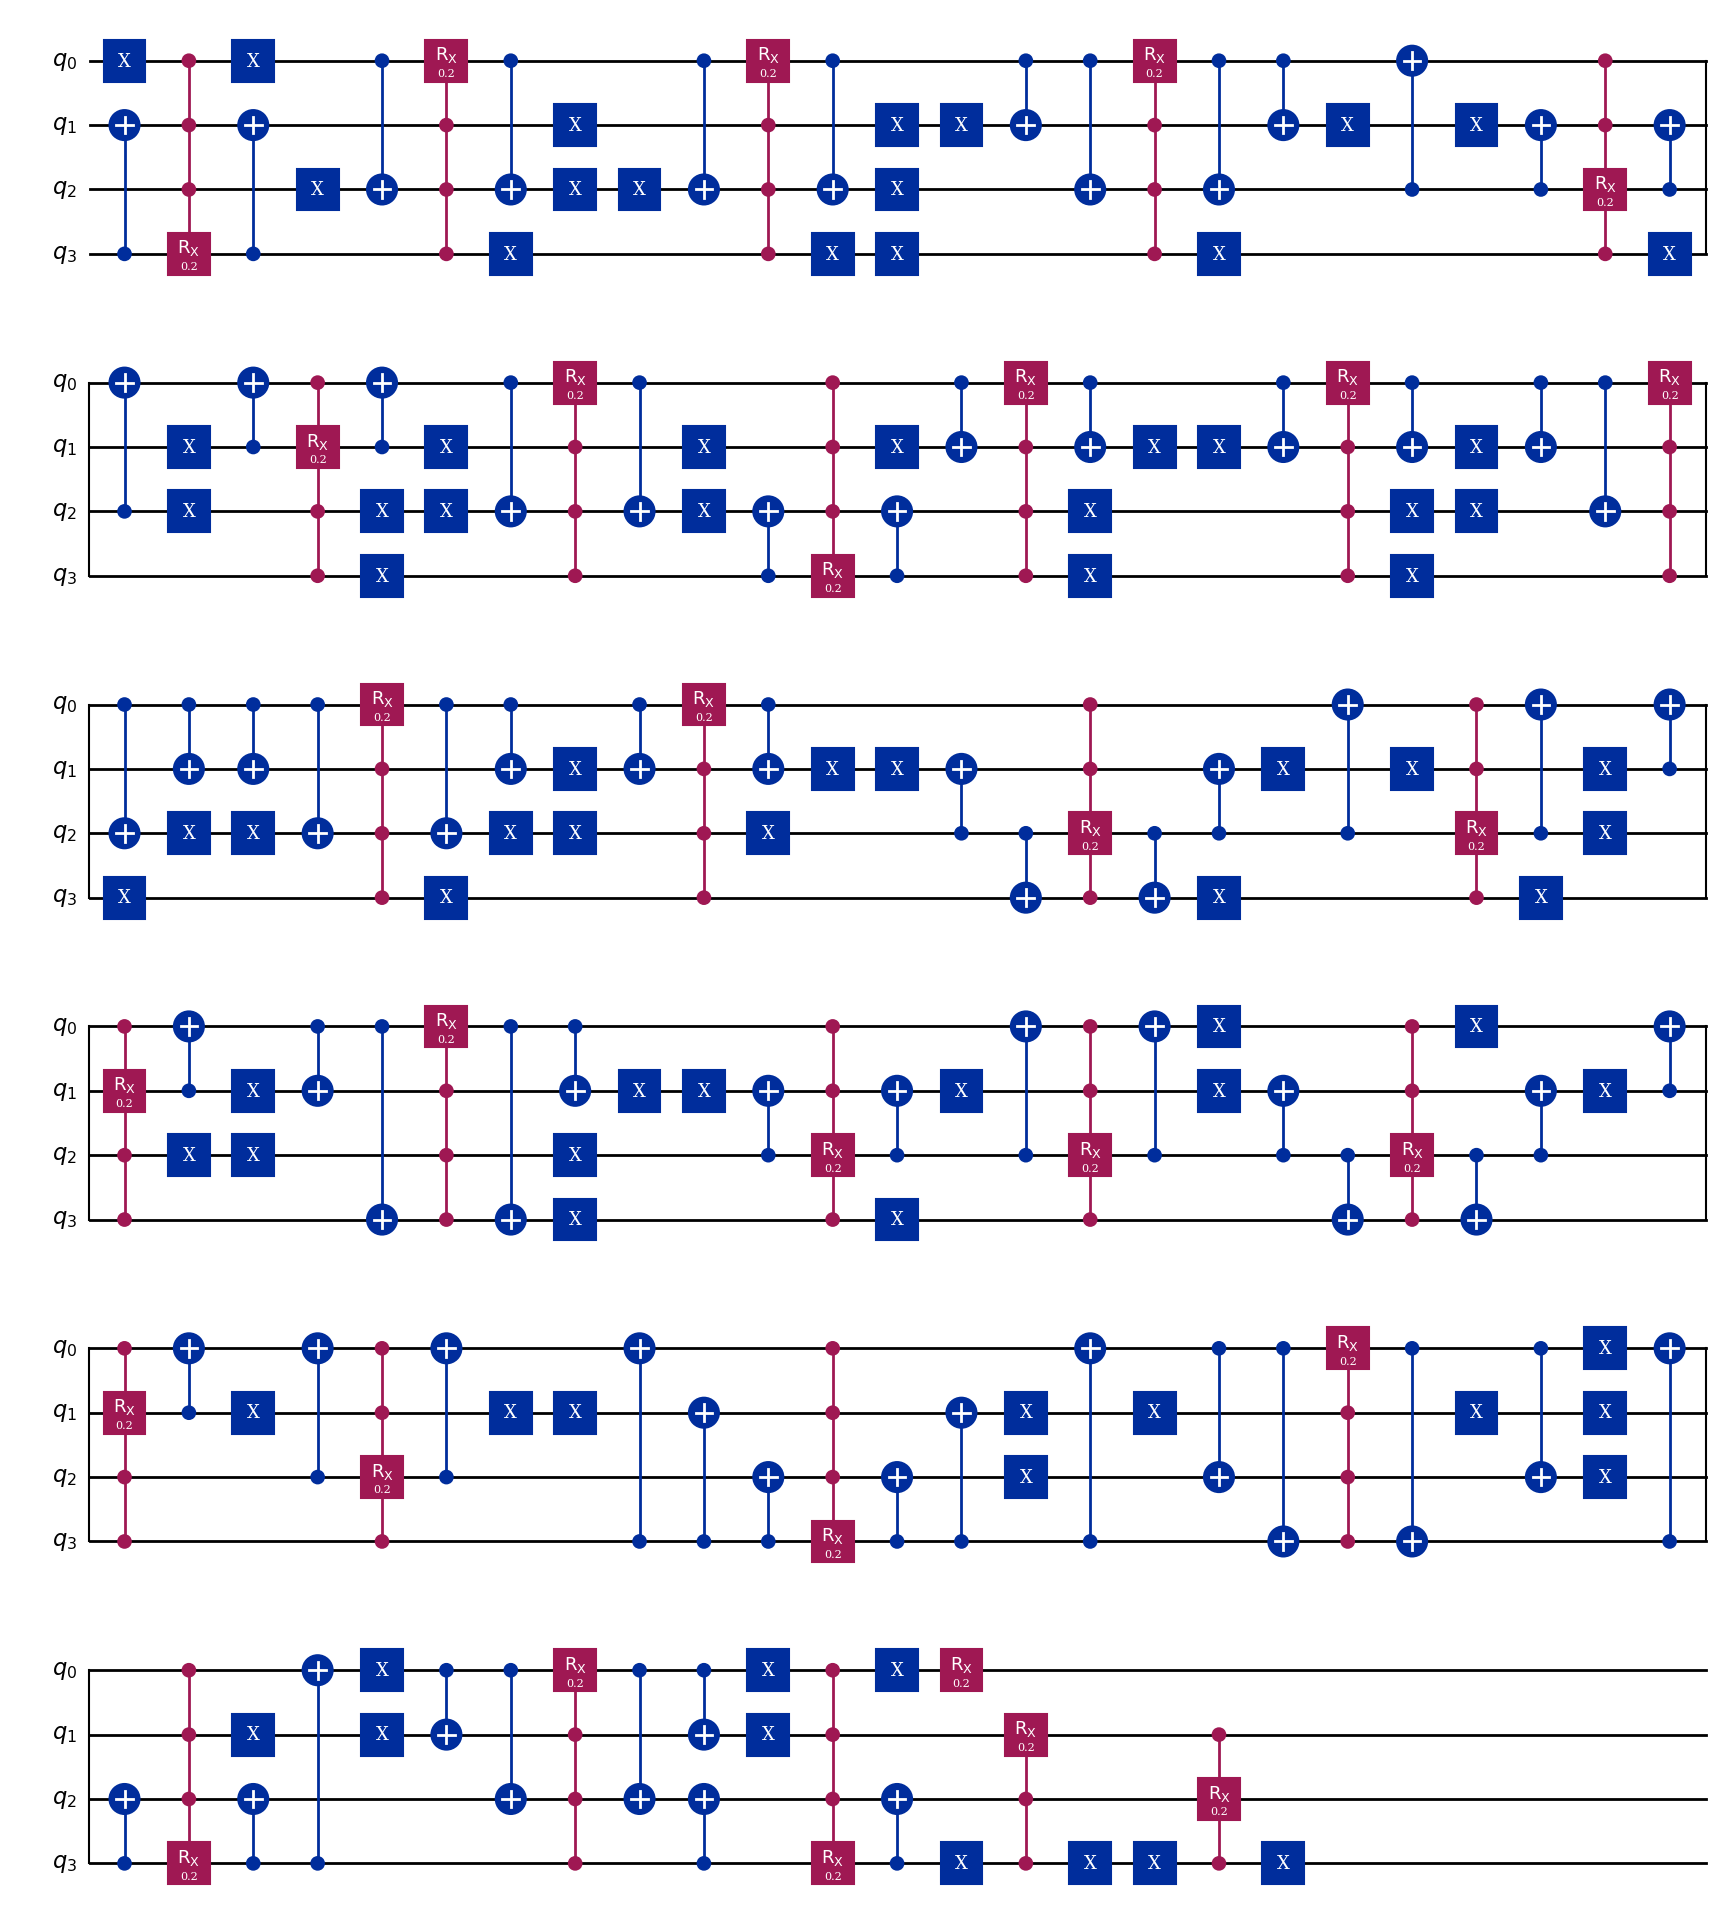


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


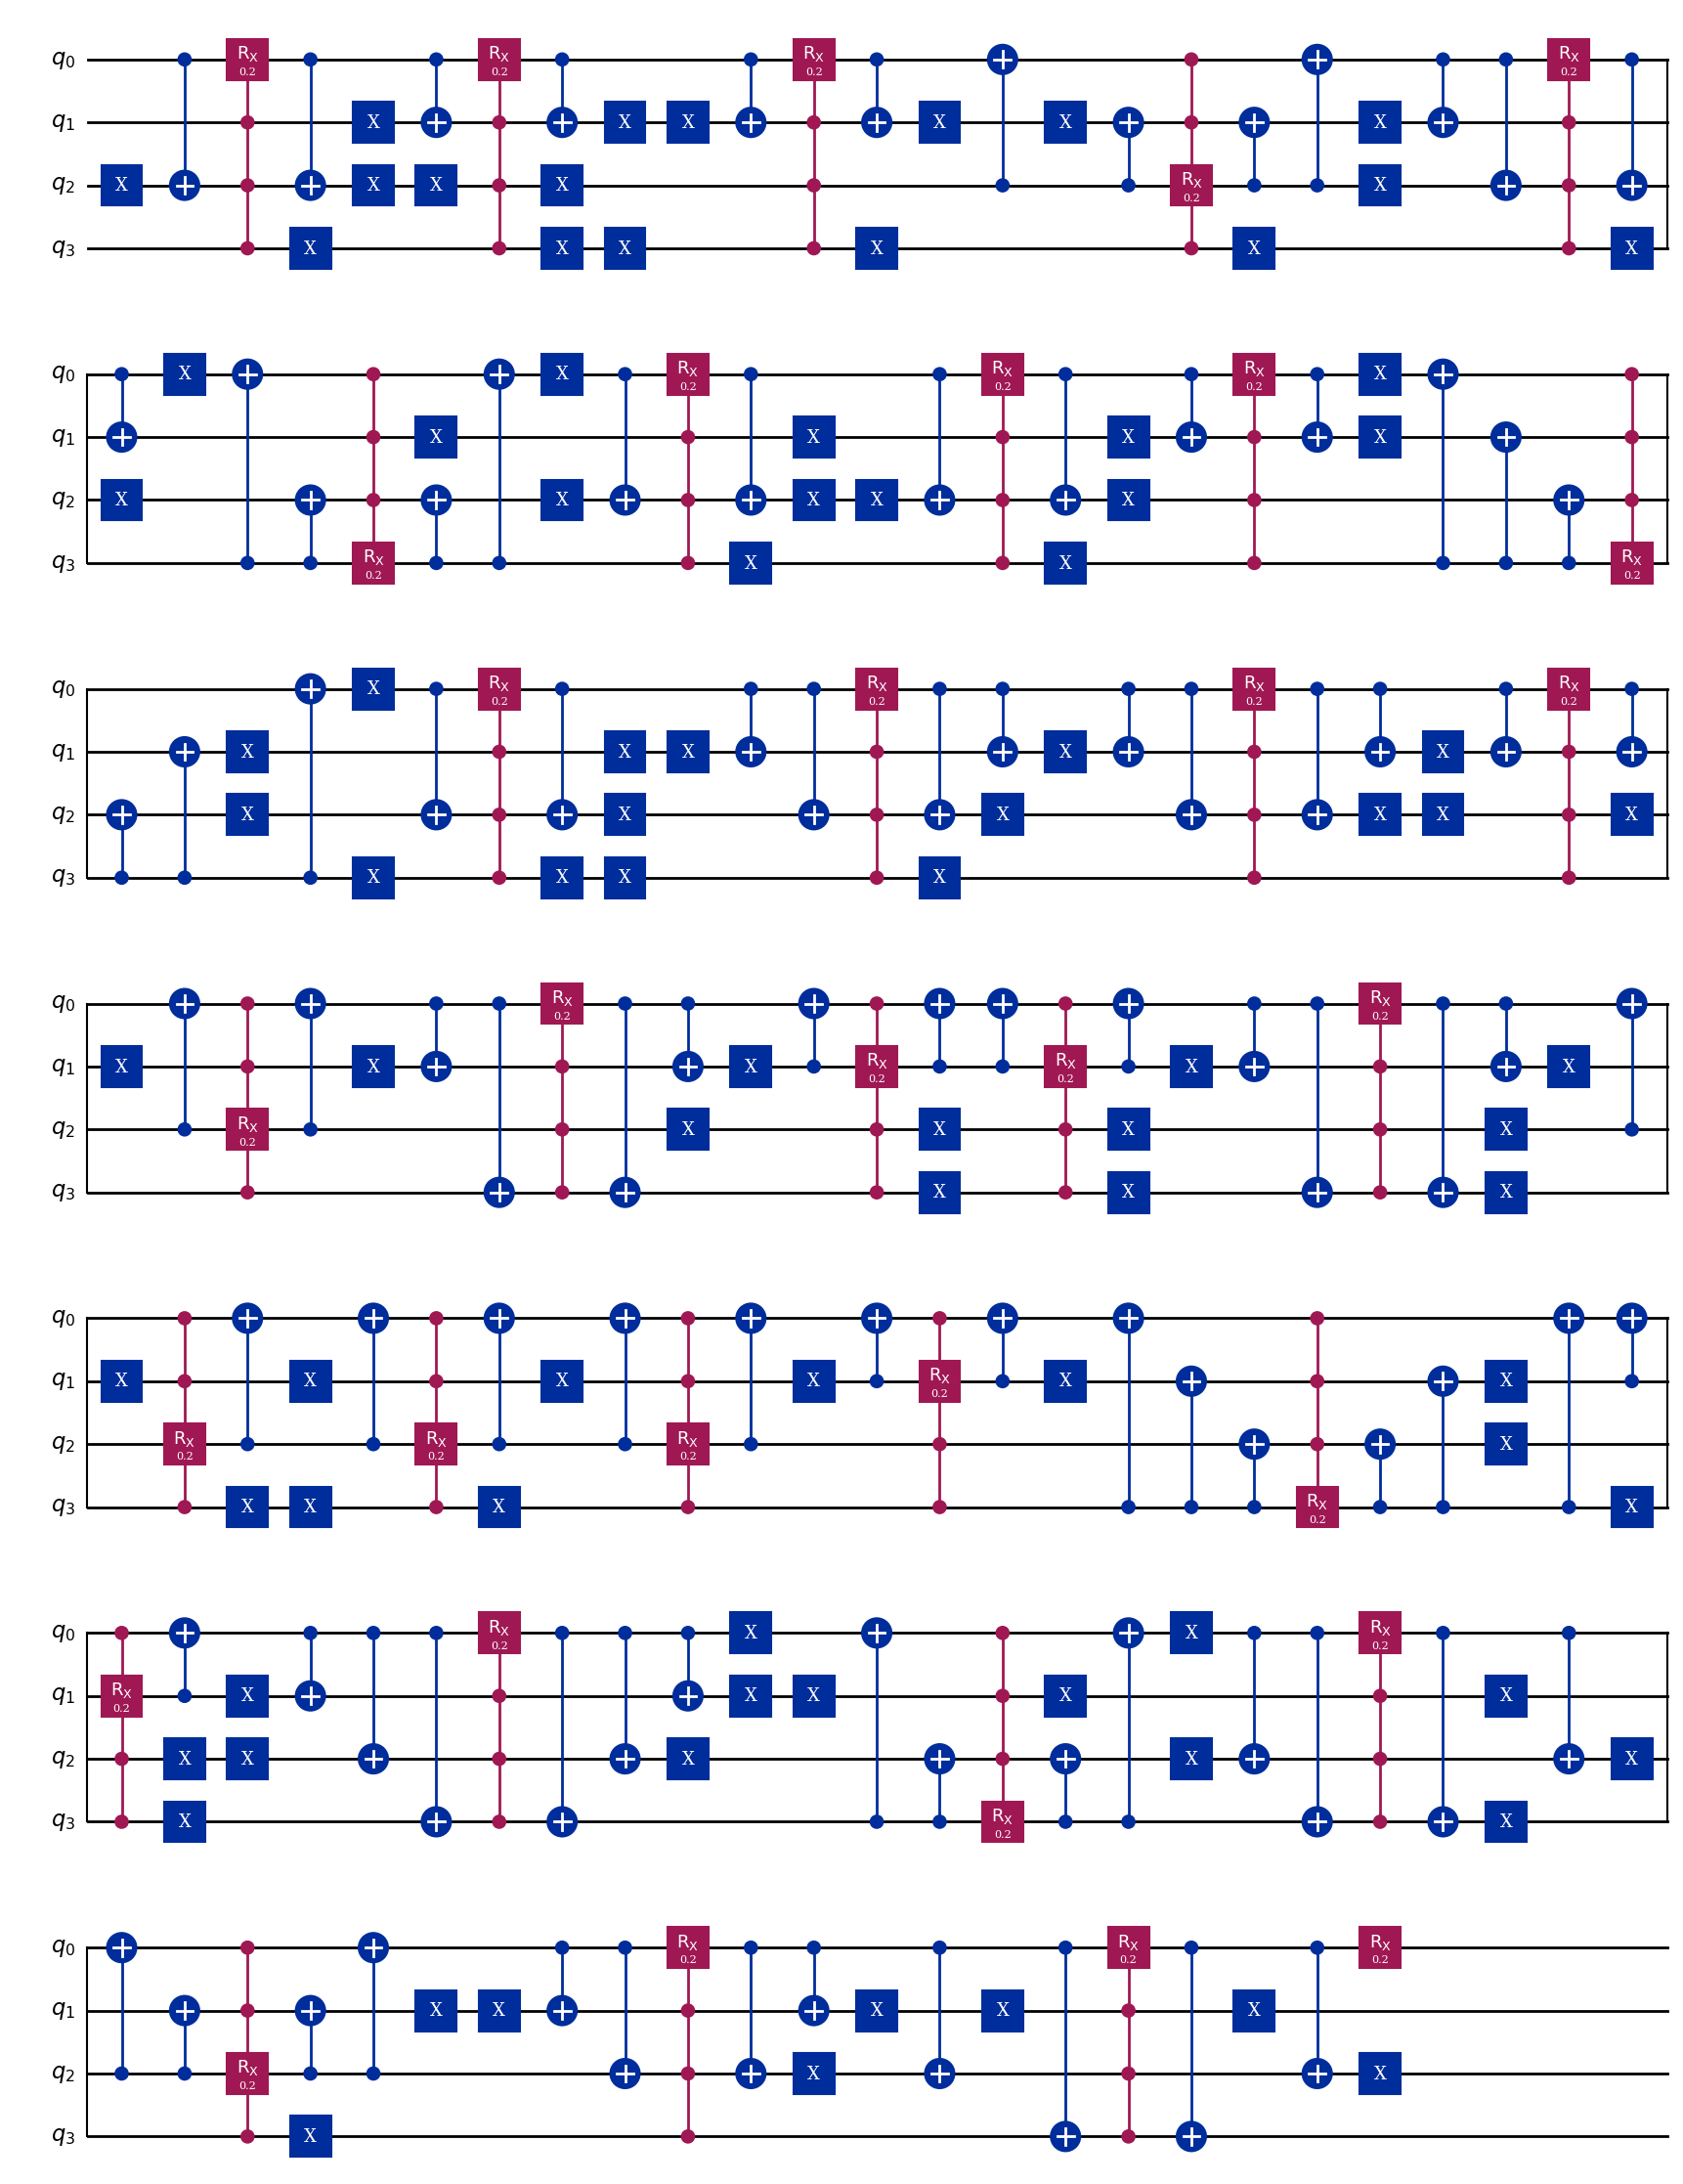


CX Gate Count Summary for Circulant Graph C16(1,3,5) (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  634/599                               |  718/679                           |   92/70  
2        | 1268/1198                              | 1436/1358                          |  184/140 
5        | 3170/2995                              | 3590/3395                          |  460/350 
10       | 6340/5990                              | 7180/6790                          |  920/700 
20       | 12680/11980                              | 14360/13580                          | 1840/1400
50       | 31700/29950                              | 35900/33950                          | 4600/3500
100      | 63400/59900                              | 71800/67900                          | 9200/7000
Error plot saved as: 

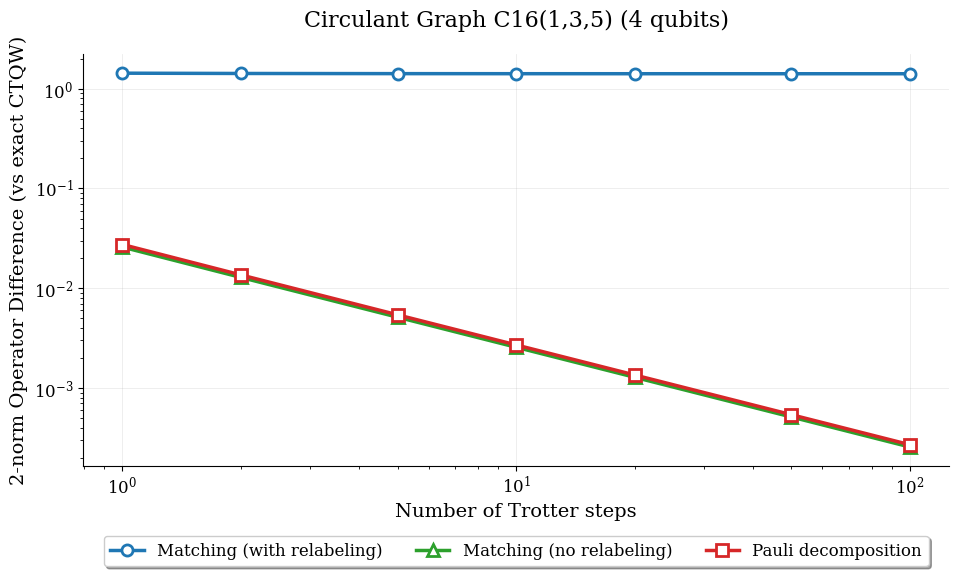

In [20]:
circulant_16 = set()
n = 16
offsets_16 = [1, 3, 5]
for i in range(n):
    v = format(i, '04b')
    for offset in offsets_16:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '04b')
        if v < neighbor:  # Avoid duplicates
            circulant_16.add((v, neighbor))
analyze_and_plot(circulant_16, "Circulant Graph C16(1,3,5) (4 qubits)")